# Fase 2 — Selección y parametrización de modelos
## Seguro Agrícola para Café — Quindío y Nariño

### Objetivo
Este notebook consolida el proceso de auditoría, selección, parametrización y validación de los modelos analíticos del artefacto, manteniendo consistencia con los requerimientos comprometidos en la Fase 1.

El trabajo se organiza en cuatro etapas:

1. Auditoría de los datos y del desarrollo existente.
2. Preparación de los conjuntos de entrenamiento y validación.
3. Comparación y parametrización de modelos candidatos.
4. Evaluación de resultados, explicabilidad y selección final.

Antes de entrenar nuevos modelos se verifican cuatro puntos críticos identificados en la reconciliación entre el desarrollo actual y el Entregable 1:

- cobertura del panel EVA a nivel municipal;
- correcta estandarización del SPI;
- consistencia del esquema de hold-out temporal;
- posible fuga de información en variables relacionadas con el área cosechada.

Las decisiones tomadas a partir de estas verificaciones se documentarán como ajustes metodológicos de la Fase 2.

In [ ]:
# ============================================================
# 0.1 CONFIGURACIÓN DEL ENTORNO
# ============================================================

import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Semilla:", SEED)

Python: 3.13.15
Pandas: 2.2.3
NumPy: 2.1.3
Semilla: 42


In [ ]:
# ============================================================
# 0.2 CONEXIÓN A GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 0.2B CLONAR REPOSITORIO DEL EQUIPO
# ============================================================

%cd /content

!git clone https://github.com/1007451013i/Equipo9_SeguroCafe.git

%cd /content/Equipo9_SeguroCafe

/content
Cloning into 'Equipo9_SeguroCafe'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 108 (delta 19), reused 107 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 10.76 MiB | 17.92 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/Equipo9_SeguroCafe


In [ ]:
# ============================================================
# 0.3 INVENTARIO DEL REPOSITORIO
# ============================================================

ROOT = Path.cwd()

print("Ruta del proyecto:")
print(ROOT)

print("\nEstructura principal:")
for item in sorted(ROOT.iterdir()):
    tipo = "DIR " if item.is_dir() else "FILE"
    print(f"{tipo:5}  {item.name}")

Ruta del proyecto:
/content/Equipo9_SeguroCafe

Estructura principal:
DIR    .git
FILE   .gitignore
FILE   README.md
DIR    data
DIR    docs_EntregablesFase2
FILE   ejecutar_pipeline_equipo9.cmd
FILE   etl_equipo9.py
DIR    notebooks
DIR    outputs
FILE   pipeline_equipo9.py
DIR    python_portable
FILE   requirements.txt
DIR    src


In [ ]:
# Buscar archivos relevantes
patterns = [
    "*.csv",
    "*.xlsx",
    "*.py",
    "*.ipynb",
    "*.md"
]

archivos = []

for pattern in patterns:
    archivos.extend(ROOT.rglob(pattern))

print(f"Total archivos relevantes encontrados: {len(archivos)}\n")

for f in sorted(archivos):
    print(f.relative_to(ROOT))

Total archivos relevantes encontrados: 40

README.md
data/processed/clima_anual_spi3_equipo9.csv
data/processed/eva_municipal_equipo9.csv
data/processed/features_modelo_equipo9.csv
data/processed/oni_anual_equipo9.csv
data/processed/precios_df_equipo9.csv
data/processed/roya_df_equipo9.csv
data/processed/tmax_anual_equipo9.csv
data/processed/tmedia_anual_equipo9.csv
data/raw/DANE-Producción Café 2012-2019 Quindio y Nariño.xlsx
data/raw/Precios-area-y-produccion-de-cafe-2026-3.xlsx
data/raw/detalle_agricola_departamental_cafe.csv
data/raw/df_anomalia_temp.xlsx
data/raw/df_hr.xlsx
data/raw/df_modis_anual.csv
data/raw/df_modis_mensual.csv
data/raw/df_rad_dia.xlsx
data/raw/df_tmax_aire.xlsx
data/raw/df_tmedia_aire.xlsx
data/raw/df_tmin_aire.xlsx
data/raw/era5_precip_quindio_narino_2018_2024.csv
data/raw/era5_precip_quindio_narino_consolidado.csv
data/raw/eva_cafe_quindio_narino_actualizado.csv
data/raw/noaa_oni_index.csv
docs_EntregablesFase2/00_REPORTE_INTERNO_EQUIPO9.md
docs_EntregablesF

In [ ]:
# ============================================================
# 0.4 INVENTARIO DE DATA/PROCESSED
# ============================================================

processed_dir = ROOT / "data" / "processed"

if not processed_dir.exists():
    print("No existe:", processed_dir)
else:
    csvs = sorted(processed_dir.glob("*.csv"))

    print(f"CSV procesados encontrados: {len(csvs)}\n")

    resumen = []

    for file in csvs:
        try:
            df = pd.read_csv(file)
            resumen.append({
                "archivo": file.name,
                "filas": df.shape[0],
                "columnas": df.shape[1],
                "primer_anio": (
                    pd.to_numeric(df["year"], errors="coerce").min()
                    if "year" in df.columns else np.nan
                ),
                "ultimo_anio": (
                    pd.to_numeric(df["year"], errors="coerce").max()
                    if "year" in df.columns else np.nan
                )
            })
        except Exception as e:
            resumen.append({
                "archivo": file.name,
                "filas": "ERROR",
                "columnas": str(e),
                "primer_anio": np.nan,
                "ultimo_anio": np.nan
            })

    resumen_df = pd.DataFrame(resumen)
    display(resumen_df)

CSV procesados encontrados: 8



,archivo,filas,columnas,primer_anio,ultimo_anio
0,clima_anual_spi3_equipo9.csv,50,20,2000.0,2024.0
1,eva_municipal_equipo9.csv,926,8,NaN,NaN
2,features_modelo_equipo9.csv,40,48,2007.0,2018.0
3,oni_anual_equipo9.csv,77,7,1950.0,2026.0
4,precios_df_equipo9.csv,37,4,1990.0,2026.0
5,roya_df_equipo9.csv,52,4,2000.0,2025.0
6,tmax_anual_equipo9.csv,108,3,1972.0,2025.0
7,tmedia_anual_equipo9.csv,108,3,1972.0,2025.0


In [ ]:
# ============================================================
# 0.5 PERFIL BÁSICO DE LOS DATASETS PROCESADOS
# ============================================================

def describir_csv(path):
    df = pd.read_csv(path)

    print("=" * 90)
    print(path.name)
    print("=" * 90)

    print("Dimensión:", df.shape)

    print("\nColumnas:")
    print(df.columns.tolist())

    print("\nPrimeras filas:")
    display(df.head())

    print("\nNulos (%):")
    nulos = (df.isna().mean() * 100).sort_values(ascending=False)
    display(nulos[nulos > 0].to_frame("pct_nulos").head(20))

    return df


datasets = {}

for file in sorted(processed_dir.glob("*.csv")):
    try:
        datasets[file.stem] = describir_csv(file)
    except Exception as e:
        print(f"ERROR leyendo {file.name}: {e}")

clima_anual_spi3_equipo9.csv
Dimensión: (50, 20)

Columnas:
['departamento', 'year', 'spi3_mean', 'spi3_median', 'spi3_min', 'spi3_max', 'spi3_std', 'n_sequia_e9', 'n_exceso_e9', 'spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'spi3_mean_lag1', 'spi3_min_lag1', 'spi3_median_lag1', 'n_sequia_e9_lag1', 'n_exceso_e9_lag1', 'spi3_floracion_lag1', 'spi3_desarrollo_lag1', 'spi3_cosecha_lag1']

Primeras filas:


,departamento,year,spi3_mean,spi3_median,spi3_min,spi3_max,spi3_std,n_sequia_e9,n_exceso_e9,spi3_floracion,spi3_desarrollo,spi3_cosecha,spi3_mean_lag1,spi3_min_lag1,spi3_median_lag1,n_sequia_e9_lag1,n_exceso_e9_lag1,spi3_floracion_lag1,spi3_desarrollo_lag1,spi3_cosecha_lag1
0,Narino,2000,-1.132106,-1.254302,-2.109317,0.061712,0.634615,8,0,-0.968949,-0.999090,-1.428280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Narino,2001,-1.154512,-1.047765,-2.270690,-0.454440,0.525126,6,0,-1.576283,-1.252443,-0.634809,-1.132106,-2.109317,-1.254302,8.0,0.0,-0.968949,-0.999090,-1.428280
2,Narino,2002,-0.525727,-0.406861,-1.765000,0.221343,0.641530,3,0,-0.102241,-1.170055,-0.304884,-1.154512,-2.270690,-1.047765,6.0,0.0,-1.576283,-1.252443,-0.634809
3,Narino,2003,-0.652485,-0.541206,-1.607173,0.186471,0.474247,3,0,-0.824285,-0.727473,-0.405698,-0.525727,-1.765000,-0.406861,3.0,0.0,-0.102241,-1.170055,-0.304884
4,Narino,2004,-0.566659,-0.543681,-1.472657,0.403797,0.552601,3,0,-0.636218,-0.547868,-0.515892,-0.652485,-1.607173,-0.541206,3.0,0.0,-0.824285,-0.727473,-0.405698



Nulos (%):


,pct_nulos
n_exceso_e9_lag1,4.0
spi3_floracion_lag1,4.0
spi3_desarrollo_lag1,4.0
spi3_cosecha_lag1,4.0
n_sequia_e9_lag1,4.0
spi3_median_lag1,4.0
spi3_min_lag1,4.0
spi3_mean_lag1,4.0


eva_municipal_equipo9.csv
Dimensión: (926, 8)

Columnas:
['departamento', 'municipio', 'anio', 'area_sembrada_ha', 'area_cosechada_ha', 'produccion_t', 'rendimiento_t_ha', 'rendimiento_kg_ha']

Primeras filas:


...

,pct_nulos


tmedia_anual_equipo9.csv
Dimensión: (108, 3)

Columnas:
['year', 'departamento', 'tmedia_mean']

Primeras filas:


,year,departamento,tmedia_mean
0,1972,Quindio,21.98
1,1973,Quindio,22.07
2,1974,Quindio,21.89
3,1975,Quindio,22.06
4,1976,Quindio,22.14



Nulos (%):


,pct_nulos


# 1. Auditoría de cobertura del panel EVA municipal

## Objetivo

Verificar si los datos EVA/MADR disponibles permiten construir un panel productivo a nivel municipio–año para Quindío y Nariño.

Esta validación es prioritaria porque, si la cobertura municipal resulta suficiente, el panel productivo puede contener un número sustancialmente mayor de observaciones que el panel departamento–año planteado inicialmente. Esto permitiría fortalecer el diseño experimental y reducir la dependencia de métricas calculadas sobre muestras extremadamente pequeñas.

Se evaluarán:

- número de municipios por departamento;
- número de años disponibles;
- observaciones municipio–año;
- cobertura temporal por municipio;
- presencia de duplicados;
- valores faltantes;
- distribución de la variable de rendimiento.

In [ ]:
# ============================================================
# 1.1 CARGA DEL PANEL EVA MUNICIPAL
# ============================================================

eva_path = ROOT / "data" / "processed" / "eva_municipal_equipo9.csv"

eva = pd.read_csv(eva_path)

print("Dimensión:", eva.shape)

print("\nColumnas:")
print(eva.columns.tolist())

print("\nPrimeras 10 filas:")
display(eva.head(10))

print("\nTipos de datos:")
display(eva.dtypes.to_frame("tipo"))

Dimensión: (926, 8)

Columnas:
['departamento', 'municipio', 'anio', 'area_sembrada_ha', 'area_cosechada_ha', 'produccion_t', 'rendimiento_t_ha', 'rendimiento_kg_ha']

Primeras 10 filas:


,departamento,municipio,anio,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_t_ha,rendimiento_kg_ha
0,Quindio,Calarca,2007,4736.0,3776.0,4744.0,1.26,1256.355932
1,Quindio,Quimbaya,2007,3610.0,2964.0,4164.0,1.40,1404.858300
2,Quindio,Pijao,2007,2626.0,2368.0,2585.0,1.09,1091.638514
3,Quindio,Filandia,2007,2289.0,1920.0,2722.0,1.42,1417.708333
4,Quindio,Circasia,2007,2237.0,1874.0,2379.0,1.27,1269.477054
5,Quindio,Armenia,2007,2103.0,1820.0,2608.0,1.43,1432.967033
6,Quindio,Cordoba,2007,1517.0,1328.0,1375.0,1.04,1035.391566
7,Quindio,Buenavista,2007,1137.0,990.0,1274.0,1.29,1286.868687
8,Quindio,Montenegro,2007,1113.0,930.0,1413.0,1.52,1519.354839
9,Quindio,Genova,2007,1043.0,931.0,886.0,0.95,951.664876



Tipos de datos:


,tipo
departamento,object
municipio,object
anio,int64
area_sembrada_ha,float64
area_cosechada_ha,float64
produccion_t,float64
rendimiento_t_ha,float64
rendimiento_kg_ha,float64


In [ ]:
# ============================================================
# 1.2 IDENTIFICACIÓN DE COLUMNAS CLAVE
# ============================================================

print("Columnas disponibles:\n")

for i, col in enumerate(eva.columns):
    print(f"{i:02d} -> {col}")

Columnas disponibles:

00 -> departamento
01 -> municipio
02 -> anio
03 -> area_sembrada_ha
04 -> area_cosechada_ha
05 -> produccion_t
06 -> rendimiento_t_ha
07 -> rendimiento_kg_ha


In [ ]:
# ============================================================
# 1.3 PERFIL GENERAL DEL PANEL
# ============================================================

print("FILAS:", len(eva))
print("COLUMNAS:", eva.shape[1])

print("\nNULOS POR COLUMNA:")
nulos = pd.DataFrame({
    "n_nulos": eva.isna().sum(),
    "pct_nulos": eva.isna().mean() * 100
}).sort_values("pct_nulos", ascending=False)

display(nulos)

print("\nNÚMERO DE VALORES ÚNICOS POR COLUMNA:")
unicos = pd.DataFrame({
    "n_unicos": eva.nunique(dropna=False)
}).sort_values("n_unicos")

display(unicos)

FILAS: 926
COLUMNAS: 8

NULOS POR COLUMNA:


,n_nulos,pct_nulos
rendimiento_t_ha,316,34.125270
rendimiento_kg_ha,316,34.125270
area_sembrada_ha,314,33.909287
produccion_t,314,33.909287
area_cosechada_ha,314,33.909287
anio,0,0.000000
departamento,0,0.000000
municipio,0,0.000000



NÚMERO DE VALORES ÚNICOS POR COLUMNA:


,n_unicos
departamento,2
anio,18
municipio,71
rendimiento_t_ha,100
rendimiento_kg_ha,487
area_cosechada_ha,488
area_sembrada_ha,490
produccion_t,493


In [ ]:
# ============================================================
# 1.4 INSPECCIÓN DEL DATASET QUE ALIMENTA LOS MODELOS
# ============================================================

features_path = ROOT / "data" / "processed" / "features_modelo_equipo9.csv"
features = pd.read_csv(features_path)

print("Dimensión features_modelo:", features.shape)

print("\nColumnas:")
print(features.columns.tolist())

print("\nPrimeras filas:")
display(features.head(10))

print("\nValores únicos por columna:")
display(
    pd.DataFrame({
        "n_unicos": features.nunique(dropna=False)
    }).sort_values("n_unicos")
)

Dimensión features_modelo: (40, 48)

Columnas:
['departamento', 'year', 'rendimiento_kg_ha', 'anom_temp_mean_e9', 'area_cosechada_ha', 'area_sembrada_ha', 'enso_spi3dev', 'evi_max', 'evi_mean', 'evi_min', 'n_exceso_e9', 'n_exceso_e9_lag1', 'n_municipios', 'n_sequia_e9', 'n_sequia_e9_lag1', 'ndvi_max', 'ndvi_mean', 'ndvi_min', 'oni_max', 'oni_mean', 'oni_mean_lag1', 'oni_min', 'pct_area_cosechada', 'precio_cop_carga', 'precio_lag1', 'precio_lag2', 'precio_spi_int', 'produccion_t', 'roya_dummy', 'roya_interact', 'roya_shock', 'spi3_cosecha', 'spi3_cosecha_lag1', 'spi3_desarrollo', 'spi3_desarrollo_lag1', 'spi3_floracion', 'spi3_floracion_lag1', 'spi3_max', 'spi3_mean', 'spi3_mean_lag1', 'spi3_median', 'spi3_median_lag1', 'spi3_min', 'spi3_min_lag1', 'spi3_std', 'temp_sq_e9', 'tmax_mean_e9', 'tmedia_mean_e9']

Primeras filas:


,departamento,year,rendimiento_kg_ha,anom_temp_mean_e9,area_cosechada_ha,area_sembrada_ha,enso_spi3dev,evi_max,evi_mean,evi_min,n_exceso_e9,n_exceso_e9_lag1,n_municipios,n_sequia_e9,n_sequia_e9_lag1,ndvi_max,ndvi_mean,ndvi_min,oni_max,oni_mean,oni_mean_lag1,oni_min,pct_area_cosechada,precio_cop_carga,precio_lag1,precio_lag2,precio_spi_int,produccion_t,roya_dummy,roya_interact,roya_shock,spi3_cosecha,spi3_cosecha_lag1,spi3_desarrollo,spi3_desarrollo_lag1,spi3_floracion,spi3_floracion_lag1,spi3_max,spi3_mean,spi3_mean_lag1,spi3_median,spi3_median_lag1,spi3_min,spi3_min_lag1,spi3_std,temp_sq_e9,tmax_mean_e9,tmedia_mean_e9
0,Narino,2007,1298.949262,-0.687907,24459.0,28332.0,-0.020513,0.398923,0.317624,0.250882,0,0.0,37,1,1.0,0.588031,0.470871,0.381346,0.66,-0.607500,0.071667,-1.60,0.863299,418925.22,592555.32,489962.82,-63414.586480,31771.0,0,-0.0,0.0,-0.107019,-0.060105,-0.360992,-0.838587,-0.196312,0.039994,0.639916,-0.221441,-0.286233,-0.254912,-0.180142,-1.025909,-1.010038,0.495945,400.0000,20.00,12.06
1,Narino,2007,1298.949262,-1.416727,24459.0,28332.0,-0.020513,0.398923,0.317624,0.250882,0,0.0,37,1,1.0,0.588031,0.470871,0.381346,0.66,-0.607500,0.071667,-1.60,0.863299,418925.22,592555.32,489962.82,-63414.586480,31771.0,0,-0.0,0.0,-0.107019,-0.060105,-0.360992,-0.838587,-0.196312,0.039994,0.639916,-0.221441,-0.286233,-0.254912,-0.180142,-1.025909,-1.010038,0.495945,400.0000,20.00,12.06
2,Narino,2008,1222.100614,-0.587397,25583.0,30220.0,0.134526,0.398923,0.317624,0.250882,0,0.0,38,0,1.0,0.588031,0.470871,0.381346,-0.23,-0.781667,-0.607500,-1.64,0.846559,992389.64,418925.22,592555.32,-125336.958259,31265.0,0,-0.0,0.0,-0.299187,-0.107019,-0.427315,-0.360992,0.098681,-0.196312,0.497349,-0.209274,-0.221441,-0.243222,-0.254912,-0.844534,-1.025909,0.396176,402.8049,20.07,12.59
3,Narino,2008,1222.100614,-1.004630,25583.0,30220.0,0.134526,0.398923,0.317624,0.250882,0,0.0,38,0,1.0,0.588031,0.470871,0.381346,-0.23,-0.781667,-0.607500,-1.64,0.846559,992389.64,418925.22,592555.32,-125336.958259,31265.0,0,-0.0,0.0,-0.299187,-0.107019,-0.427315,-0.360992,0.098681,-0.196312,0.497349,-0.209274,-0.221441,-0.243222,-0.254912,-0.844534,-1.025909,0.396176,402.8049,20.07,12.59
4,Narino,2009,1038.651906,-0.018137,26467.0,31591.0,0.163582,0.398923,0.317624,0.250882,0,0.0,39,4,0.0,0.588031,0.470871,0.381346,1.56,0.281667,-0.781667,-0.85,0.837802,619372.63,992389.64,418925.22,-973123.692164,27490.0,0,-0.0,0.0,-0.980586,-0.299187,-0.963331,-0.427315,0.148993,0.098681,0.313510,-0.598308,-0.209274,-0.728223,-0.243222,-1.601336,-0.844534,0.618441,411.2784,20.28,11.98
5,Narino,2009,1038.651906,0.696983,26467.0,31591.0,0.163582,0.398923,0.317624,0.250882,0,0.0,39,4,0.0,0.588031,0.470871,0.381346,1.56,0.281667,-0.781667,-0.85,0.837802,619372.63,992389.64,418925.22,-973123.692164,27490.0,0,-0.0,0.0,-0.980586,-0.299187,-0.963331,-0.427315,0.148993,0.098681,0.313510,-0.598308,-0.209274,-0.728223,-0.243222,-1.601336,-0.844534,0.618441,411.2784,20.28,11.98
6,Narino,2010,1046.371139,-0.610933,23506.0,31971.0,-0.168524,0.398923,0.317624,0.250882,0,0.0,41,1,4.0,0.588031,0.470871,0.381346,1.50,-0.475000,0.281667,-1.64,0.735229,813140.14,619372.63,992389.64,-59852.095932,24596.0,0,-0.0,0.0,-0.096633,-0.980586,-0.414184,-0.963331,-0.305314,0.148993,0.334316,-0.272044,-0.598308,-0.113640,-0.728223,-1.077148,-1.601336,0.488837,410.4676,20.26,12.01
7,Narino,2010,1046.371139,-1.285276,23506.0,31971.0,-0.168524,0.398923,0.317624,0.250882,0,0.0,41,1,4.0,0.588031,0.470871,0.381346,1.50,-0.475000,0.281667,-1.64,0.735229,813140.14,619372.63,992389.64,-59852.095932,24596.0,0,-0.0,0.0,-0.096633,-0.980586,-0.414184,-0.963331,-0.305314,0.148993,0.334316,-0.272044,-0.598308,-0.113640,-0.728223,-1.077148,-1.601336,0.488837,410.4676,20.26,12.01
8,Narino,2011,992.211004,-0.273836,24265.0,34422.0,0.129221,0.398923,0.317624,0.250882,0,0.0,43,1,1.0,0.588031,0.470871,0.381346,-0.37,-0.775000,-0.475000,-1.31,0.704927,999140.79,813140.14,619372.63,-47817.958536,24076.0,0,-0.0,0.0,-0.058807,-


Valores únicos por columna:


,n_unicos
departamento,2
roya_dummy,2
roya_shock,3
n_exceso_e9_lag1,4
n_municipios,6
n_sequia_e9_lag1,6
n_exceso_e9,6
n_sequia_e9,6
roya_interact,7
oni_min,11


In [ ]:
# ============================================================
# 1.5 INSPECCIÓN INICIAL DEL ARCHIVO SPI
# ============================================================

spi_path = ROOT / "data" / "processed" / "clima_anual_spi3_equipo9.csv"
spi = pd.read_csv(spi_path)

print("Dimensión SPI:", spi.shape)

print("\nColumnas:")
print(spi.columns.tolist())

print("\nPrimeras filas:")
display(spi.head(10))

print("\nEstadísticas descriptivas:")
display(spi.describe(include="all").T)

Dimensión SPI: (50, 20)

Columnas:
['departamento', 'year', 'spi3_mean', 'spi3_median', 'spi3_min', 'spi3_max', 'spi3_std', 'n_sequia_e9', 'n_exceso_e9', 'spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'spi3_mean_lag1', 'spi3_min_lag1', 'spi3_median_lag1', 'n_sequia_e9_lag1', 'n_exceso_e9_lag1', 'spi3_floracion_lag1', 'spi3_desarrollo_lag1', 'spi3_cosecha_lag1']

Primeras filas:


,departamento,year,spi3_mean,spi3_median,spi3_min,spi3_max,spi3_std,n_sequia_e9,n_exceso_e9,spi3_floracion,spi3_desarrollo,spi3_cosecha,spi3_mean_lag1,spi3_min_lag1,spi3_median_lag1,n_sequia_e9_lag1,n_exceso_e9_lag1,spi3_floracion_lag1,spi3_desarrollo_lag1,spi3_cosecha_lag1
0,Narino,2000,-1.132106,-1.254302,-2.109317,0.061712,0.634615,8,0,-0.968949,-0.999090,-1.428280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Narino,2001,-1.154512,-1.047765,-2.270690,-0.454440,0.525126,6,0,-1.576283,-1.252443,-0.634809,-1.132106,-2.109317,-1.254302,8.0,0.0,-0.968949,-0.999090,-1.428280
2,Narino,2002,-0.525727,-0.406861,-1.765000,0.221343,0.641530,3,0,-0.102241,-1.170055,-0.304884,-1.154512,-2.270690,-1.047765,6.0,0.0,-1.576283,-1.252443,-0.634809
3,Narino,2003,-0.652485,-0.541206,-1.607173,0.186471,0.474247,3,0,-0.824285,-0.727473,-0.405698,-0.525727,-1.765000,-0.406861,3.0,0.0,-0.102241,-1.170055,-0.304884
4,Narino,2004,-0.566659,-0.543681,-1.472657,0.403797,0.552601,3,0,-0.636218,-0.547868,-0.515892,-0.652485,-1.607173,-0.541206,3.0,0.0,-0.824285,-0.727473,-0.405698
5,Narino,2005,-0.541557,-0.439807,-1.620205,0.279141,0.602682,3,0,-0.399592,-1.034033,-0.191046,-0.566659,-1.472657,-0.543681,3.0,0.0,-0.636218,-0.547868,-0.515892
6,Narino,2006,-0.286233,-0.180142,-1.010038,0.371233,0.495993,1,0,0.039994,-0.838587,-0.060105,-0.541557,-1.620205,-0.439807,3.0,0.0,-0.399592,-1.034033,-0.191046
7,Narino,2007,-0.221441,-0.254912,-1.025909,0.639916,0.495945,1,0,-0.196312,-0.360992,-0.107019,-0.286233,-1.010038,-0.180142,1.0,0.0,0.039994,-0.838587,-0.060105
8,Narino,2008,-0.209274,-0.243222,-0.844534,0.497349,0.396176,0,0,0.098681,-0.427315,-0.299187,-0.221441,-1.025909,-0.254912,1.0,0.0,-0.196312,-0.360992,-0.107019
9,Narino,2009,-0.598308,-0.728223,-1.601336,0.313510,0.618441,4,0,0.148993,-0.963331,-0.980586,-0.209274,-0.844534,-0.243222,0.0,0.0,0.098681,-0.427315,-0.299187



Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
departamento,50,2,Narino,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,50.0,NaN,NaN,NaN,2012.0,7.284314,2000.0,2006.0,2012.0,2018.0,2024.0
spi3_mean,50.0,NaN,NaN,NaN,-0.000801,0.766034,-1.154512,-0.560384,-0.227603,0.708107,1.677493
spi3_median,50.0,NaN,NaN,NaN,0.072755,0.779409,-1.254302,-0.433186,-0.131718,0.787606,1.689289
spi3_min,50.0,NaN,NaN,NaN,-1.11458,0.786612,-2.553344,-1.60482,-1.26147,-0.780195,0.739589
spi3_max,50.0,NaN,NaN,NaN,0.947912,0.797028,-0.467453,0.318712,0.704904,1.637568,2.544823
spi3_std,50.0,NaN,NaN,NaN,0.634932,0.148335,0.396176,0.53954,0.610561,0.67265,1.086322
n_sequia_e9,50.0,NaN,NaN,NaN,2.08,2.068619,0.0,0.0,2.0,3.0,8.0
n_exceso_e9,50.0,NaN,NaN,NaN,2.24,3.371913,0.0,0.0,0.0,5.0,10.0
spi3_floracion,50.0,NaN,NaN,NaN,0.080969,0.888177,-1.576283,-0.504483,-0.032753,0.594861,1.837373


In [ ]:
# ============================================================
# 1.6 COBERTURA REAL DEL PANEL EVA MUNICIPAL
# ============================================================

eva_clean = eva.copy()

# Estandarización básica de texto
eva_clean["departamento"] = (
    eva_clean["departamento"]
    .astype(str)
    .str.strip()
    .str.title()
)

eva_clean["municipio"] = (
    eva_clean["municipio"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Indicador de observación productiva utilizable
eva_clean["registro_util"] = (
    eva_clean["rendimiento_kg_ha"].notna()
    & eva_clean["area_cosechada_ha"].notna()
    & eva_clean["produccion_t"].notna()
)

resumen_eva = (
    eva_clean
    .groupby("departamento")
    .agg(
        filas_totales=("municipio", "size"),
        municipios=("municipio", "nunique"),
        anio_min=("anio", "min"),
        anio_max=("anio", "max"),
        anios=("anio", "nunique"),
        registros_utiles=("registro_util", "sum")
    )
    .reset_index()
)

resumen_eva["pct_util"] = (
    resumen_eva["registros_utiles"] /
    resumen_eva["filas_totales"] * 100
).round(1)

display(resumen_eva)

,departamento,filas_totales,municipios,anio_min,anio_max,anios,registros_utiles,pct_util
0,Narino,710,56,2007,2024,18,466,65.6
1,Quindio,216,15,2007,2024,18,144,66.7


In [ ]:
# ============================================================
# 1.7 COBERTURA MUNICIPAL POR AÑO
# ============================================================

cobertura_anual = (
    eva_clean[eva_clean["registro_util"]]
    .groupby(["departamento", "anio"])
    .agg(
        municipios_con_dato=("municipio", "nunique"),
        observaciones=("municipio", "size")
    )
    .reset_index()
)

tabla_cobertura = cobertura_anual.pivot(
    index="anio",
    columns="departamento",
    values="municipios_con_dato"
)

display(tabla_cobertura)

departamento,Narino,Quindio
anio,,
2007,37,12
2008,38,12
2009,39,12
2010,41,12
2011,43,12
2012,41,12
2013,37,12
2014,38,12
2015,38,12


In [ ]:
# ============================================================
# 1.8 LONGITUD DE SERIE POR MUNICIPIO
# ============================================================

serie_municipio = (
    eva_clean[eva_clean["registro_util"]]
    .groupby(["departamento", "municipio"])
    .agg(
        n_anios=("anio", "nunique"),
        anio_min=("anio", "min"),
        anio_max=("anio", "max"),
        n_obs=("anio", "size")
    )
    .reset_index()
)

display(
    serie_municipio
    .sort_values(["departamento", "n_anios"],
                 ascending=[True, False])
)

print("\nMunicipios con al menos 10 años de datos:")

display(
    serie_municipio
    .assign(
        al_menos_10=lambda x: x["n_anios"] >= 10
    )
    .groupby("departamento")
    .agg(
        municipios_totales=("municipio", "count"),
        municipios_10_anios=("al_menos_10", "sum")
    )
)

,departamento,municipio,n_anios,anio_min,anio_max,n_obs
0,Narino,Alban,12,2007,2018,12
1,Narino,Ancuya,12,2007,2018,12
4,Narino,Buesaco,12,2007,2018,12
5,Narino,Chachagui,12,2007,2018,12
6,Narino,Colon,12,2007,2018,12
7,Narino,Consaca,12,2007,2018,12
9,Narino,Cumbitara,12,2007,2018,12
12,Narino,El Rosario,12,2007,2018,12
13,Narino,El Tablon,12,2007,2018,12
14,Narino,El Tambo,12,2007,2018,12



Municipios con al menos 10 años de datos:


,municipios_totales,municipios_10_anios
departamento,,
Narino,45,35
Quindio,12,12


# 2. Auditoría del dataset actual de modelado

El archivo `features_modelo_equipo9.csv` presenta más filas que combinaciones únicas departamento–año. Antes de utilizar sus resultados para comparar modelos, se verifica si existen duplicados en la unidad de análisis y qué variables los originan.

In [ ]:
# ============================================================
# 2.1 DUPLICADOS DEPARTAMENTO-AÑO
# ============================================================

conteo_dept_year = (
    features
    .groupby(["departamento", "year"])
    .size()
    .reset_index(name="n_filas")
)

print("Distribución del número de filas por departamento-año:")
display(conteo_dept_year["n_filas"].value_counts().sort_index())

duplicados = conteo_dept_year[
    conteo_dept_year["n_filas"] > 1
].copy()

print("\nCombinaciones departamento-año repetidas:")
display(duplicados)

print("\nResumen:")
print("Filas totales:", len(features))
print(
    "Combinaciones departamento-año únicas:",
    features[["departamento", "year"]].drop_duplicates().shape[0]
)
print(
    "Filas excedentes:",
    len(features)
    - features[["departamento", "year"]].drop_duplicates().shape[0]
)

Distribución del número de filas por departamento-año:


,count
n_filas,
1,8
2,16



Combinaciones departamento-año repetidas:


,departamento,year,n_filas
0,Narino,2007,2
1,Narino,2008,2
2,Narino,2009,2
3,Narino,2010,2
4,Narino,2011,2
6,Narino,2013,2
7,Narino,2014,2
11,Narino,2018,2
12,Quindio,2007,2
13,Quindio,2008,2



Resumen:
Filas totales: 40
Combinaciones departamento-año únicas: 24
Filas excedentes: 16


In [ ]:
# ============================================================
# 2.2 VARIABLES QUE CAMBIAN DENTRO DEL MISMO DEPARTAMENTO-AÑO
# ============================================================

variaciones = []

for (dep, year), g in features.groupby(["departamento", "year"]):
    if len(g) > 1:
        cols_diferentes = [
            col for col in features.columns
            if col not in ["departamento", "year"]
            and g[col].nunique(dropna=False) > 1
        ]

        variaciones.append({
            "departamento": dep,
            "year": year,
            "n_filas": len(g),
            "columnas_que_cambian": ", ".join(cols_diferentes)
        })

variaciones_df = pd.DataFrame(variaciones)

display(variaciones_df)

,departamento,year,n_filas,columnas_que_cambian
0,Narino,2007,2,anom_temp_mean_e9
1,Narino,2008,2,anom_temp_mean_e9
2,Narino,2009,2,anom_temp_mean_e9
3,Narino,2010,2,anom_temp_mean_e9
4,Narino,2011,2,anom_temp_mean_e9
5,Narino,2013,2,anom_temp_mean_e9
6,Narino,2014,2,anom_temp_mean_e9
7,Narino,2018,2,anom_temp_mean_e9
8,Quindio,2007,2,anom_temp_mean_e9
9,Quindio,2008,2,anom_temp_mean_e9


In [ ]:
# ============================================================
# 2.3 CONSISTENCIA DE LA VARIABLE OBJETIVO
# ============================================================

target_check = (
    features
    .groupby(["departamento", "year"])["rendimiento_kg_ha"]
    .nunique()
    .reset_index(name="n_rendimientos_distintos")
)

problemas_target = target_check[
    target_check["n_rendimientos_distintos"] > 1
]

if problemas_target.empty:
    print(
        "OK: cada combinación departamento-año "
        "tiene un único valor de rendimiento."
    )
else:
    print(
        "ALERTA: existen departamento-año "
        "con más de un valor de rendimiento."
    )
    display(problemas_target)

OK: cada combinación departamento-año tiene un único valor de rendimiento.


## Hallazgos de la auditoría inicial de datos

La revisión del panel EVA/MADR identificó 926 registros municipio–año para Quindío y Nariño entre 2007 y 2024. De estos, 610 cuentan con información productiva utilizable (rendimiento, producción y área cosechada): 466 en Nariño y 144 en Quindío.

La cobertura efectiva se concentra entre 2007 y 2018. Nariño presenta 35 municipios con al menos 10 años de información y Quindío 12, para un total de 47 municipios con series relativamente extensas.

Este resultado muestra que existe potencial para fortalecer el panel productivo respecto de la agregación departamento–año utilizada inicialmente. Sin embargo, la adopción de municipio–año como unidad de análisis dependerá de que las variables explicativas climáticas puedan construirse a una granularidad espacial compatible. Repetir una misma variable climática departamental para múltiples municipios no aumentaría realmente la información climática disponible y podría generar pseudorreplicación.

Adicionalmente, se detectó una inconsistencia en `features_modelo_equipo9.csv`. El archivo contiene 40 filas, pero únicamente 24 combinaciones únicas departamento–año. Dieciséis combinaciones aparecen duplicadas y, en todos los casos, la única variable que cambia entre las filas repetidas es `anom_temp_mean_e9`. La variable objetivo `rendimiento_kg_ha` permanece constante dentro de cada combinación.

Por esta razón, antes de utilizar las métricas actuales de los modelos como evidencia definitiva, se debe identificar el origen de la duplicación y reconstruir el dataset de modelamiento con una unidad de análisis inequívoca.

In [ ]:
# ============================================================
# 2.4 RASTREO DE anom_temp_mean_e9 EN EL CÓDIGO
# ============================================================

from pathlib import Path

for archivo in [
    ROOT / "etl_equipo9.py",
    ROOT / "pipeline_equipo9.py"
]:
    print("\n" + "=" * 100)
    print(archivo.name)
    print("=" * 100)

    texto = archivo.read_text(encoding="utf-8", errors="ignore")
    lineas = texto.splitlines()

    for i, linea in enumerate(lineas):
        if "anom_temp" in linea.lower():
            inicio = max(0, i - 8)
            fin = min(len(lineas), i + 9)

            print(f"\n--- contexto alrededor de línea {i+1} ---")
            for j in range(inicio, fin):
                print(f"{j+1:04d}: {lineas[j]}")


etl_equipo9.py

--- contexto alrededor de línea 431 ---
0423:         if len(sdf) > 5:
0424:             cols = sdf.columns.tolist()
0425:             # Buscar patron anyo, valor
0426:             first_col_numeric = pd.to_numeric(sdf[cols[0]], errors="coerce")
0427:             if first_col_numeric.notna().mean() > 0.5:
0428:                 years = first_col_numeric.astype("Int64")
0429:                 values = pd.to_numeric(sdf[cols[-1]], errors="coerce")
0430:                 anom_tmp = pd.DataFrame({"year": years.astype(float),
0431:                                           "anom_temp_mean_e9": values})
0432:                 panel = panel.merge(anom_tmp.dropna(), on="year", how="left")
0433:             break
0434: except Exception:
0435:     pass
0436: if "anom_temp_mean_e9" not in panel.columns:
0437:     panel["anom_temp_mean_e9"] = 0.0
0438: 
0439: # MODIS NDVI anual

--- contexto alrededor de línea 436 ---
0428:                 years = first_col_numeric.astype("Int64")
042

In [ ]:
# ============================================================
# 2.5 INSPECCIÓN DE LA FUENTE DE ANOMALÍA DE TEMPERATURA
# ============================================================

anom_path = ROOT / "data" / "raw" / "df_anomalia_temp.xlsx"

xls = pd.ExcelFile(anom_path)

print("Hojas disponibles:")
print(xls.sheet_names)

for hoja in xls.sheet_names:
    tmp = pd.read_excel(anom_path, sheet_name=hoja)

    print("\n" + "=" * 90)
    print("HOJA:", hoja)
    print("Dimensión:", tmp.shape)
    print("Columnas:")
    print(tmp.columns.tolist())

    display(tmp.head(10))

Hojas disponibles:
['Anomalia_temperatura']

HOJA: Anomalia_temperatura
Dimensión: (50, 15)
Columnas:
['Año', 'Departamento', 'Municipio', 'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']


,Año,Departamento,Municipio,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
0,2000,Nariño,Pasto,-0.851974,(-),-0.538391,-0.510666,-0.353836,-0.228127,-0.395017,-0.325613,-0.667918,-0.310037,-0.238231,-0.165772
1,2001,Nariño,Pasto,-0.610845,-0.529345,-0.290811,-0.268166,0.012723,-0.343127,0.161434,-0.33771,-0.153751,0.735124,0.265102,0.701164
2,2002,Nariño,Pasto,0.188349,0.242976,0.398974,-0.263999,0.018745,-0.421923,0.420305,0.046269,0.182916,-0.009097,-0.230731,(-)
3,2003,Nariño,Pasto,0.853672,0.645655,(-),0.018558,0.235997,(-),0.12966,0.357936,0.476712,0.297737,0.47165,(-)
4,2004,Nariño,Pasto,-0.206309,0.311454,0.403298,0.086399,0.114204,-0.51896,0.045613,-0.049657,(-),(-),(-),0.106002
5,2005,Nariño,Pasto,0.224167,0.622143,(-),(-),(-),(-),0.236327,0.348769,0.136666,0.086737,-0.015731,-0.130637
6,2006,Nariño,Pasto,-0.06553,0.821547,0.107853,-0.283166,0.13439,(-),0.094008,0.060793,-0.069584,-0.082311,(-),0.351196
7,2007,Nariño,Pasto,0.796168,-0.695774,-0.221389,0.252251,0.029197,0.197858,0.82091,0.141012,-0.638334,-0.21237,-0.100282,-0.687907
8,2008,Nariño,Pasto,-0.624109,-1.000024,-1.167961,-0.559028,-0.692575,-0.273246,-0.580501,-0.815129,-0.437853,-0.436597,-0.084898,-0.587397
9,2009,Nariño,Pasto,0.327615,-0.149415,0.034912,-0.142781,-0.118352,-0.068127,0.13466,0.532591,0.172082,0.440308,0.567781,-0.018137


In [ ]:
# ============================================================
# 2.6 VALORES DUPLICADOS DE anom_temp_mean_e9
# ============================================================

dup_temp = (
    features[
        features.duplicated(
            subset=["departamento", "year"],
            keep=False
        )
    ][
        ["departamento", "year",
         "anom_temp_mean_e9",
         "tmax_mean_e9",
         "tmedia_mean_e9",
         "rendimiento_kg_ha"]
    ]
    .sort_values(["departamento", "year"])
)

display(dup_temp)

,departamento,year,anom_temp_mean_e9,tmax_mean_e9,tmedia_mean_e9,rendimiento_kg_ha
0,Narino,2007,-0.687907,20.00,12.06,1298.949262
1,Narino,2007,-1.416727,20.00,12.06,1298.949262
2,Narino,2008,-0.587397,20.07,12.59,1222.100614
3,Narino,2008,-1.004630,20.07,12.59,1222.100614
4,Narino,2009,-0.018137,20.28,11.98,1038.651906
5,Narino,2009,0.696983,20.28,11.98,1038.651906
6,Narino,2010,-0.610933,20.26,12.01,1046.371139
7,Narino,2010,-1.285276,20.26,12.01,1046.371139
8,Narino,2011,-0.273836,19.61,12.24,992.211004
9,Narino,2011,-0.793340,19.61,12.24,992.211004


In [ ]:
# ============================================================
# 3.1 GRANULARIDAD DE LOS DATASETS CLIMÁTICOS RAW
# ============================================================

archivos_clima = [
    ROOT / "data" / "raw" / "era5_precip_quindio_narino_consolidado.csv",
    ROOT / "data" / "raw" / "df_modis_mensual.csv",
    ROOT / "data" / "raw" / "df_modis_anual.csv",
]

for path in archivos_clima:

    print("\n" + "=" * 100)
    print(path.name)
    print("=" * 100)

    df_tmp = pd.read_csv(path)

    print("Dimensión:", df_tmp.shape)
    print("Columnas:", df_tmp.columns.tolist())

    display(df_tmp.head(5))

    print("\nValores únicos por columna:")
    display(
        pd.DataFrame({
            "n_unicos": df_tmp.nunique(dropna=False)
        }).sort_values("n_unicos").head(30)
    )


era5_precip_quindio_narino_consolidado.csv
Dimensión: (3672, 9)
Columnas: ['time', 'lat', 'lon', 'precip_mm_day', 'year', 'month', 'days_in_month', 'precip_mm_month', 'departamento']


,time,lat,lon,precip_mm_day,year,month,days_in_month,precip_mm_month,departamento
0,2000-01-01,4.5,-75.5,0.595881,2000,1,31,18.472313,Quindío
1,2000-02-01,4.5,-75.5,2.101931,2000,2,29,60.955988,Quindío
2,2000-03-01,4.5,-75.5,1.642750,2000,3,31,50.925257,Quindío
3,2000-04-01,4.5,-75.5,2.996529,2000,4,30,89.895871,Quindío
4,2000-05-01,4.5,-75.5,3.910004,2000,5,31,121.210121,Quindío



Valores únicos por columna:


,n_unicos
departamento,2
days_in_month,4
lon,5
lat,5
month,12
year,18
time,216
precip_mm_day,3672
precip_mm_month,3672



df_modis_mensual.csv
Dimensión: (192, 11)
Columnas: ['departamento', 'year', 'month', 'ndvi_mean', 'ndvi_min', 'ndvi_max', 'ndvi_std', 'evi_mean', 'evi_min', 'evi_max', 'evi_std']


...

,n_unicos
departamento,2
year,8
month,12
ndvi_std,177
evi_std,177
ndvi_mean,192
ndvi_max,192
ndvi_min,192
evi_mean,192
evi_min,192



df_modis_anual.csv
Dimensión: (16, 8)
Columnas: ['departamento', 'year', 'ndvi_mean', 'ndvi_min', 'ndvi_max', 'evi_mean', 'evi_min', 'evi_max']


,departamento,year,ndvi_mean,ndvi_min,ndvi_max,evi_mean,evi_min,evi_max
0,Narino,2012,0.470871,0.381346,0.588031,0.317624,0.250882,0.398923
1,Narino,2013,0.426934,0.365695,0.614330,0.292339,0.232386,0.408850
2,Narino,2014,0.468278,0.336115,0.548037,0.322602,0.247661,0.373862
3,Narino,2015,0.502860,0.388362,0.593668,0.341148,0.281995,0.383826
4,Narino,2016,0.440768,0.322141,0.637424,0.303053,0.222072,0.405136



Valores únicos por columna:


,n_unicos
departamento,2
year,8
ndvi_mean,16
ndvi_min,16
ndvi_max,16
evi_mean,16
evi_min,16
evi_max,16


In [ ]:
# ============================================================
# 3.2 COBERTURA EVA 2019-2024
# ============================================================

eva_reciente = eva_clean[
    eva_clean["anio"] >= 2019
].copy()

resumen_reciente = (
    eva_reciente
    .groupby(["departamento", "anio"])
    .agg(
        filas=("municipio", "size"),
        municipios=("municipio", "nunique"),
        rendimiento_disponible=("rendimiento_kg_ha", lambda x: x.notna().sum()),
        produccion_disponible=("produccion_t", lambda x: x.notna().sum()),
        area_disponible=("area_cosechada_ha", lambda x: x.notna().sum())
    )
    .reset_index()
)

display(resumen_reciente)

,departamento,anio,filas,municipios,rendimiento_disponible,produccion_disponible,area_disponible
0,Narino,2019,40,40,0,0,0
1,Narino,2020,40,40,0,0,0
2,Narino,2021,40,40,0,0,0
3,Narino,2022,40,40,0,0,0
4,Narino,2023,41,41,0,0,0
5,Narino,2024,41,41,0,0,0
6,Quindio,2019,12,12,0,0,0
7,Quindio,2020,12,12,0,0,0
8,Quindio,2021,12,12,0,0,0
9,Quindio,2022,12,12,0,0,0


## 2.7 Diagnóstico del panel de modelamiento existente

La auditoría identificó una inconsistencia en la construcción del archivo `features_modelo_equipo9.csv`.

Aunque el archivo contiene 40 filas, únicamente existen 24 combinaciones únicas departamento–año. Dieciséis combinaciones aparecen dos veces y, dentro de cada par duplicado, la única variable que cambia es `anom_temp_mean_e9`; la variable objetivo y las demás variables permanecen constantes.

La revisión del ETL permitió identificar la causa. La fuente original de anomalía térmica contiene las dimensiones `Año`, `Departamento` y `Municipio`, pero durante la transformación se conserva únicamente el año y el valor de anomalía. Posteriormente, la información se integra al panel mediante un `merge` exclusivamente sobre `year`. Como resultado, cuando existen múltiples registros para un mismo año en la fuente original, cada fila del panel productivo se replica.

En consecuencia, las 40 filas del dataset actual no constituyen 40 observaciones independientes. Las métricas obtenidas hasta el momento a partir de este archivo deben considerarse preliminares y serán recalculadas después de corregir la integración geográfica de la anomalía de temperatura.

La corrección consiste en construir primero una anomalía anual identificada por departamento y año, y posteriormente integrar la fuente utilizando la llave `departamento + year`.

## 3.3 Viabilidad del panel productivo municipal

La revisión de EVA/MADR confirmó la existencia de información productiva a nivel municipio–año.

Se identificaron 926 registros entre 2007 y 2024, de los cuales 610 cuentan con rendimiento, producción y área cosechada utilizables: 466 en Nariño y 144 en Quindío. La información productiva efectiva se concentra en 2007–2018; las observaciones de 2019–2024 no contienen valores de rendimiento, producción ni área.

La cobertura histórica es suficientemente amplia para explorar una versión municipal del panel productivo: 35 municipios de Nariño y los 12 municipios cafeteros observados de Quindío cuentan con al menos diez años de información.

No obstante, el incremento en número de observaciones solo constituye una mejora metodológica si las variables climáticas pueden construirse a una granularidad compatible. Repetir valores climáticos departamentales en múltiples municipios produciría pseudorreplicación y no aumentaría la información climática efectiva.

La fuente ERA5 conserva coordenadas de grilla (`lat`, `lon`) y permite avanzar hacia una construcción espacial. En contraste, los archivos MODIS existentes se encuentran agregados a nivel departamental y no conservan píxel, coordenada ni geometría. Por esta razón, la implementación completa del panel espacial requiere una nueva extracción de MODIS a nivel de celda o píxel.

In [ ]:
# ============================================================
# 4.1 ESTRUCTURA GEOGRÁFICA DE LA FUENTE DE ANOMALÍA
# ============================================================

anom_raw = pd.read_excel(
    ROOT / "data" / "raw" / "df_anomalia_temp.xlsx",
    sheet_name="Anomalia_temperatura"
)

print("Departamentos:")
display(
    anom_raw[["Departamento", "Municipio"]]
    .drop_duplicates()
    .sort_values(["Departamento", "Municipio"])
)

print("\nNúmero de registros por departamento:")
display(
    anom_raw.groupby("Departamento")
    .size()
    .to_frame("n_filas")
)

print("\nAños por departamento:")
display(
    anom_raw.groupby("Departamento")["Año"]
    .agg(["min", "max", "nunique"])
)

Departamentos:


,Departamento,Municipio
25,Nariño,Chachagui
0,Nariño,Pasto



Número de registros por departamento:


,n_filas
Departamento,
Nariño,50



Años por departamento:


,min,max,nunique
Departamento,,,
Nariño,2000,2024,25


In [ ]:
# ============================================================
# 4.2 ANOMALÍA MEDIA ANUAL CORRECTA
# ============================================================

meses = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

anom = anom_raw.copy()

# Reemplazar códigos no numéricos
for col in meses:
    anom[col] = pd.to_numeric(
        anom[col].replace({
            "(-)": np.nan,
            "ND": np.nan,
            "-": np.nan
        }),
        errors="coerce"
    )

# Media anual usando los meses disponibles
anom["anom_temp_mean_e9"] = anom[meses].mean(axis=1)

# Estandarizar nombres
anom["departamento"] = (
    anom["Departamento"]
    .astype(str)
    .str.strip()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.title()
)

anom["year"] = pd.to_numeric(
    anom["Año"],
    errors="coerce"
).astype("Int64")

anom_anual = (
    anom.groupby(["departamento", "year"], as_index=False)
    .agg(
        anom_temp_mean_e9=("anom_temp_mean_e9", "mean"),
        n_estaciones=("Municipio", "nunique"),
        meses_validos=("anom_temp_mean_e9", "count")
    )
)

print("Dimensión anomalía anual:", anom_anual.shape)

display(anom_anual.head(20))

Dimensión anomalía anual: (25, 5)


,departamento,year,anom_temp_mean_e9,n_estaciones,meses_validos
0,Narino,2000,-0.508519,2,2
1,Narino,2001,0.129394,2,2
2,Narino,2002,0.301305,2,2
3,Narino,2003,0.365520,2,2
4,Narino,2004,0.079878,2,2
5,Narino,2005,0.139899,2,2
6,Narino,2006,0.040506,2,2
7,Narino,2007,-0.337691,2,2
8,Narino,2008,-0.941505,2,2
9,Narino,2009,0.000011,2,2


In [ ]:
# ============================================================
# 4.3 VALIDACIÓN DE LA LLAVE
# ============================================================

duplicados_anom = (
    anom_anual
    .duplicated(
        subset=["departamento", "year"],
        keep=False
    )
)

print(
    "Duplicados departamento-año:",
    duplicados_anom.sum()
)

assert duplicados_anom.sum() == 0, \
    "La anomalía anual todavía presenta duplicados."

print("OK: departamento + year es llave única.")

Duplicados departamento-año: 0
OK: departamento + year es llave única.


In [ ]:
# ============================================================
# 4.4 IMPACTO DE USAR DICIEMBRE EN VEZ DE MEDIA ANUAL
# ============================================================

comparacion_temp = anom.copy()

comparacion_temp["anom_diciembre"] = comparacion_temp["Dic"]

comparacion_temp = comparacion_temp[
    ["departamento", "year",
     "anom_diciembre",
     "anom_temp_mean_e9"]
].dropna()

comparacion_temp["diferencia"] = (
    comparacion_temp["anom_diciembre"]
    - comparacion_temp["anom_temp_mean_e9"]
)

display(comparacion_temp.head(20))

print("\nResumen de la diferencia:")
display(
    comparacion_temp["diferencia"]
    .describe()
    .to_frame()
)

,departamento,year,anom_diciembre,anom_temp_mean_e9,diferencia
0,Narino,2000,-0.165772,-0.416871,0.251099
1,Narino,2001,0.701164,-0.054851,0.756014
4,Narino,2004,0.106002,0.032449,0.073553
5,Narino,2005,-0.130637,0.188555,-0.319192
6,Narino,2006,0.351196,0.106920,0.244276
7,Narino,2007,-0.687907,-0.026555,-0.661352
8,Narino,2008,-0.587397,-0.604943,0.017547
9,Narino,2009,-0.018137,0.142761,-0.160899
10,Narino,2010,-0.610933,0.187529,-0.798462
11,Narino,2011,-0.273836,-0.184364,-0.089472



Resumen de la diferencia:


,diferencia
count,44.000000
mean,-0.011330
std,0.554706
min,-1.139582
25%,-0.293428
50%,-0.006734
75%,0.255427
max,1.849018


## 4.5 Decisión sobre la anomalía de temperatura

La auditoría de `anom_temp_mean_e9` identificó dos problemas en la implementación original.

Primero, la fuente `df_anomalia_temp.xlsx` contiene únicamente registros del departamento de Nariño, correspondientes a las estaciones/municipios de Pasto y Chachagüí. No existe información equivalente para Quindío en el archivo disponible.

Segundo, el ETL original descartaba las dimensiones geográficas de la fuente y conservaba únicamente el año junto con la última columna del archivo, correspondiente al mes de diciembre. Posteriormente realizaba la integración con el panel utilizando solamente `year` como llave. Esto provocaba que las dos observaciones anuales de Nariño se replicaran tanto en Nariño como en Quindío y generaran filas duplicadas en el dataset de modelamiento.

La reconstrucción de la variable utilizando el promedio de los meses disponibles muestra diferencias relevantes respecto al valor de diciembre utilizado originalmente. La diferencia diciembre–media anual presenta una desviación estándar cercana a 0,55 unidades y alcanza valores superiores a una unidad en algunos años.

Dado que no existe una fuente equivalente para Quindío y que la temperatura ya está representada mediante `tmax_mean_e9` y `tmedia_mean_e9`, se decide excluir `anom_temp_mean_e9` del conjunto común de variables candidatas para la comparación de modelos de la Fase 2.

Esta decisión elimina la duplicación artificial de observaciones y garantiza comparabilidad entre departamentos.

# 5. Auditoría del índice SPI-3

## Objetivo

Verificar que el índice SPI-3 utilizado en el artefacto haya sido construido y estandarizado correctamente antes de utilizarlo como predictor, criterio de clasificación y variable para la calibración de umbrales.

La revisión se realiza sobre la implementación mensual original y no únicamente sobre sus agregados anuales, debido a que el SPI se define sobre una distribución estandarizada y las propiedades de dicha distribución pueden perderse al resumir los valores por año.

In [ ]:
# ============================================================
# 5.1 RASTREO DE LA IMPLEMENTACIÓN DEL SPI
# ============================================================

for archivo in [
    ROOT / "etl_equipo9.py",
    ROOT / "pipeline_equipo9.py"
]:
    print("\n" + "=" * 100)
    print(archivo.name)
    print("=" * 100)

    texto = archivo.read_text(encoding="utf-8", errors="ignore")
    lineas = texto.splitlines()

    palabras = ["spi3", "gamma", "norm.ppf", "precip"]

    hits = []

    for i, linea in enumerate(lineas):
        if any(p.lower() in linea.lower() for p in palabras):
            hits.append(i)

    # Agrupar líneas cercanas para no repetir bloques
    bloques = []
    for i in hits:
        if not bloques or i > bloques[-1][-1] + 12:
            bloques.append([i])
        else:
            bloques[-1].append(i)

    for bloque in bloques:
        inicio = max(0, bloque[0] - 8)
        fin = min(len(lineas), bloque[-1] + 12)

        print(f"\n--- líneas {inicio+1} a {fin} ---")
        for j in range(inicio, fin):
            print(f"{j+1:04d}: {lineas[j]}")


etl_equipo9.py

--- líneas 230 a 265 ---
0230: t_med = _procesar_temperatura("df_tmedia_aire.xlsx", "tmedia_mean")
0231: t_max = _procesar_temperatura("df_tmax_aire.xlsx", "tmax_mean")
0232: 
0233: t_med.to_csv(os.path.join(PROC, "tmedia_anual_equipo9.csv"), index=False)
0234: t_max.to_csv(os.path.join(PROC, "tmax_anual_equipo9.csv"), index=False)
0235: print(f"      tmedia: {len(t_med)} filas | tmax: {len(t_max)} filas")
0236: 
0237: # ============================================================
0238: # 6. ERA5 PRECIPITACIONES + CALCULO SPI-3 (McKee)
0239: # ------------------------------------------------------------
0240: # Datos de precipitacion diaria reanalisis ERA5-Land del
0241: # Servicio de Cambio Climatico Copernicus (C3S), grilla
0242: # 0.25 grados. Se concatenan dos cohortes (2000-2017 y
0243: # 2018-2024). Para Nariño, la precipitacion se pondera por
0244: # area cafetera: el 95.5% corresponde al pixel sobre la
0245: # cordillera occidental (-77.5 longitud O) donde se u

In [ ]:
# ============================================================
# 5.2 BÚSQUEDA DE DATASETS CON SPI MENSUAL
# ============================================================

candidatos_spi = []

for file in ROOT.rglob("*.csv"):
    try:
        tmp = pd.read_csv(file, nrows=5)

        cols_spi = [
            c for c in tmp.columns
            if "spi" in c.lower()
        ]

        if cols_spi:
            candidatos_spi.append({
                "archivo": str(file.relative_to(ROOT)),
                "columnas_spi": cols_spi,
                "columnas_totales": list(tmp.columns)
            })

    except Exception:
        pass

for item in candidatos_spi:
    print("\nARCHIVO:", item["archivo"])
    print("SPI:", item["columnas_spi"])
    print("TODAS:", item["columnas_totales"])


ARCHIVO: data/processed/clima_anual_spi3_equipo9.csv
SPI: ['spi3_mean', 'spi3_median', 'spi3_min', 'spi3_max', 'spi3_std', 'spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'spi3_mean_lag1', 'spi3_min_lag1', 'spi3_median_lag1', 'spi3_floracion_lag1', 'spi3_desarrollo_lag1', 'spi3_cosecha_lag1']
TODAS: ['departamento', 'year', 'spi3_mean', 'spi3_median', 'spi3_min', 'spi3_max', 'spi3_std', 'n_sequia_e9', 'n_exceso_e9', 'spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'spi3_mean_lag1', 'spi3_min_lag1', 'spi3_median_lag1', 'n_sequia_e9_lag1', 'n_exceso_e9_lag1', 'spi3_floracion_lag1', 'spi3_desarrollo_lag1', 'spi3_cosecha_lag1']

ARCHIVO: data/processed/features_modelo_equipo9.csv
SPI: ['enso_spi3dev', 'precio_spi_int', 'spi3_cosecha', 'spi3_cosecha_lag1', 'spi3_desarrollo', 'spi3_desarrollo_lag1', 'spi3_floracion', 'spi3_floracion_lag1', 'spi3_max', 'spi3_mean', 'spi3_mean_lag1', 'spi3_median', 'spi3_median_lag1', 'spi3_min', 'spi3_min_lag1', 'spi3_std']
TODAS: ['departamento', '

In [ ]:
# ============================================================
# 5.3 ESTRUCTURA ESPACIAL DE ERA5
# ============================================================

era5 = pd.read_csv(
    ROOT / "data" / "raw" /
    "era5_precip_quindio_narino_consolidado.csv"
)

grilla = (
    era5[
        ["departamento", "lat", "lon"]
    ]
    .drop_duplicates()
    .sort_values(
        ["departamento", "lat", "lon"]
    )
)

print("Celdas ERA5 por departamento:")

display(
    grilla.groupby("departamento")
    .size()
    .to_frame("n_celdas")
)

print("\nCoordenadas:")
display(grilla)

Celdas ERA5 por departamento:


,n_celdas
departamento,
Nariño,16
Quindío,1



Coordenadas:


,departamento,lat,lon
216,Nariño,-1.5,-79.5
217,Nariño,-1.5,-78.5
218,Nariño,-1.5,-77.5
219,Nariño,-1.5,-76.5
220,Nariño,-0.5,-79.5
221,Nariño,-0.5,-78.5
222,Nariño,-0.5,-77.5
223,Nariño,-0.5,-76.5
224,Nariño,0.5,-79.5
225,Nariño,0.5,-78.5


## 5.4 Hallazgos sobre la implementación existente de SPI-3

La revisión del código permitió identificar varios aspectos de la implementación del SPI-3 que requieren ajuste antes de utilizar sus resultados como evidencia definitiva.

La implementación existente sigue conceptualmente el procedimiento de ajuste Gamma y transformación a una normal estándar. Sin embargo, se identificaron cuatro aspectos metodológicos a revisar:

1. La precipitación de tres meses se calcula mediante `np.convolve(..., np.ones(3)/3, mode="same")`. Esta operación produce un promedio móvil y genera observaciones de borde con menos de tres meses efectivos. Para la implementación revisada se construirá explícitamente la precipitación acumulada de tres meses, dejando sin cálculo los primeros dos meses de cada serie.

2. El ajuste Gamma se realiza sobre todos los meses de la serie de un departamento en una única distribución. Dado que la precipitación presenta estacionalidad, se evaluará el SPI-3 calibrando la distribución por mes calendario, de forma que cada observación se compare contra la climatología correspondiente al mismo mes.

3. La implementación desplaza artificialmente la precipitación acumulada antes del ajuste Gamma mediante un término positivo. Al tratarse de una variable naturalmente no negativa, se revisará esta transformación y se implementará explícitamente el manejo de valores de precipitación cero.

4. La ponderación espacial utilizada para Nariño asigna 95,5% al píxel cafetero y 4,5% a cada uno de los restantes. Cuando existen múltiples píxeles fuera del área principal, esta implementación no conserva la participación total 95,5% / 4,5% declarada. Se corregirá la distribución de pesos o se utilizará una agregación espacial sustentada en la cobertura efectiva.

Adicionalmente, la inspección de las coordenadas ERA5 mostró 16 celdas para Nariño y una para Quindío. Antes de utilizar esta malla como soporte del panel espacial se verificará su resolución y cobertura real, dado que las coordenadas observadas presentan una separación mayor a la esperada según la descripción metodológica del proyecto.

Por estas razones, los umbrales y validaciones del Track A generados por la implementación actual se consideran preliminares hasta completar la reconstrucción y validación del SPI-3.

In [ ]:
# ============================================================
# 6.1 COBERTURA Y POSIBLES SOLAPAMIENTOS DE ERA5
# ============================================================

era5_1 = pd.read_csv(
    ROOT / "data" / "raw" /
    "era5_precip_quindio_narino_consolidado.csv"
)

era5_2 = pd.read_csv(
    ROOT / "data" / "raw" /
    "era5_precip_quindio_narino_2018_2024.csv"
)

def resumen_era5(df, nombre):
    print("\n" + "=" * 90)
    print(nombre)
    print("=" * 90)

    print("Dimensión:", df.shape)
    print("Años:", df["year"].min(), "-", df["year"].max())
    print("N años:", df["year"].nunique())

    print("\nFilas por departamento:")
    display(
        df.groupby("departamento")
        .size()
        .to_frame("filas")
    )

    print("\nCeldas únicas por departamento:")
    display(
        df.groupby("departamento")
        .apply(
            lambda x: x[["lat", "lon"]]
            .drop_duplicates()
            .shape[0]
        )
        .to_frame("celdas")
    )


resumen_era5(era5_1, "COHORTE 1")
resumen_era5(era5_2, "COHORTE 2")

print("\nAños comunes entre cohortes:")
print(
    sorted(
        set(era5_1["year"].unique()) &
        set(era5_2["year"].unique())
    )
)


COHORTE 1
Dimensión: (3672, 9)
Años: 2000 - 2017
N años: 18

Filas por departamento:


,filas
departamento,
Nariño,3456
Quindío,216



Celdas únicas por departamento:


,celdas
departamento,
Nariño,16
Quindío,1



COHORTE 2
Dimensión: (1428, 9)
Años: 2018 - 2024
N años: 7

Filas por departamento:


,filas
departamento,
Nariño,1344
Quindío,84



Celdas únicas por departamento:


,celdas
departamento,
Nariño,16
Quindío,1



Años comunes entre cohortes:
[]


In [ ]:
# ============================================================
# 6.2 DUPLICADOS ERA5 ENTRE COHORTES
# ============================================================

era5_total = pd.concat(
    [era5_1, era5_2],
    ignore_index=True
)

llave_era5 = [
    "departamento",
    "year",
    "month",
    "lat",
    "lon"
]

duplicados_era5 = era5_total[
    era5_total.duplicated(
        subset=llave_era5,
        keep=False
    )
].sort_values(llave_era5)

print(
    "Número de filas duplicadas según "
    "departamento-año-mes-lat-lon:",
    len(duplicados_era5)
)

if len(duplicados_era5) > 0:
    display(duplicados_era5.head(30))

Número de filas duplicadas según departamento-año-mes-lat-lon: 0


In [ ]:
# ============================================================
# 6.3 RESOLUCIÓN OBSERVADA DE LA GRILLA
# ============================================================

for depto, g in era5_total.groupby("departamento"):

    coords = (
        g[["lat", "lon"]]
        .drop_duplicates()
        .sort_values(["lat", "lon"])
    )

    lats = np.sort(coords["lat"].unique())
    lons = np.sort(coords["lon"].unique())

    dlat = np.diff(lats)
    dlon = np.diff(lons)

    print("\n", depto)
    print("-" * 60)

    print("Latitudes:", lats)
    print("Longitudes:", lons)

    print(
        "Saltos lat:",
        np.unique(np.round(dlat, 4))
    )

    print(
        "Saltos lon:",
        np.unique(np.round(dlon, 4))
    )


 Nariño
------------------------------------------------------------
Latitudes: [-1.5 -0.5  0.5  1.5]
Longitudes: [-79.5 -78.5 -77.5 -76.5]
Saltos lat: [1.]
Saltos lon: [1.]

 Quindío
------------------------------------------------------------
Latitudes: [4.5]
Longitudes: [-75.5]
Saltos lat: []
Saltos lon: []


In [ ]:
# ============================================================
# 6.4 AUDITORÍA DE PESOS DE NARIÑO
# ============================================================

nar_test = era5_total[
    era5_total["departamento"]
    .astype(str)
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.lower()
    .eq("narino")
].copy()

# Tomar un único mes con todas las celdas
ejemplo = (
    nar_test
    .sort_values(["year", "month"])
    .groupby(["year", "month"])
    .filter(lambda x: len(x) > 1)
)

if len(ejemplo) > 0:

    y0 = ejemplo.iloc[0]["year"]
    m0 = ejemplo.iloc[0]["month"]

    g = ejemplo[
        (ejemplo["year"] == y0) &
        (ejemplo["month"] == m0)
    ].copy()

    mask = np.isclose(
        g["lon"],
        -77.5,
        atol=0.6
    )

    g["peso_codigo_actual"] = np.where(
        mask,
        0.955,
        0.045
    )

    g["peso_efectivo_normalizado"] = (
        g["peso_codigo_actual"] /
        g["peso_codigo_actual"].sum()
    )

    display(
        g[
            [
                "lat",
                "lon",
                "precip_mm_month",
                "peso_codigo_actual",
                "peso_efectivo_normalizado"
            ]
        ]
    )

    print(
        "\nPeso efectivo total de las celdas objetivo:",
        round(
            g.loc[
                mask,
                "peso_efectivo_normalizado"
            ].sum(),
            4
        )
    )

    print(
        "Peso efectivo total del resto:",
        round(
            g.loc[
                ~mask,
                "peso_efectivo_normalizado"
            ].sum(),
            4
        )
    )

,lat,lon,precip_mm_month,peso_codigo_actual,peso_efectivo_normalizado
216,-1.5,-79.5,34.194102,0.045,0.010321
217,-1.5,-78.5,19.812214,0.045,0.010321
218,-1.5,-77.5,87.127411,0.955,0.219037
219,-1.5,-76.5,128.534898,0.045,0.010321
220,-0.5,-79.5,22.313265,0.045,0.010321
221,-0.5,-78.5,10.705840,0.045,0.010321
222,-0.5,-77.5,95.283954,0.955,0.219037
223,-0.5,-76.5,175.324866,0.045,0.010321
224,0.5,-79.5,29.827392,0.045,0.010321
225,0.5,-78.5,43.466608,0.045,0.010321



Peso efectivo total de las celdas objetivo: 0.8761
Peso efectivo total del resto: 0.1239


## 6.5 Hallazgos sobre la fuente ERA5 y su agregación espacial

La auditoría de la fuente ERA5 utilizada por el pipeline confirmó que las dos cohortes temporales son complementarias: la primera cubre 2000–2017 y la segunda 2018–2024, sin años superpuestos ni registros duplicados en la llave departamento–año–mes–latitud–longitud.

Sin embargo, la resolución espacial observada en los archivos no coincide con la descripción de 0,25° incluida en el código. Para Nariño se identificaron 16 celdas organizadas en una malla 4×4, con saltos de 1° tanto en latitud como en longitud. Para Quindío se dispone únicamente de una celda.

También se verificó la ponderación implementada para Nariño. El código asigna un peso de 0,955 a cada celda cuya longitud es aproximadamente -77,5 y 0,045 a cada una de las demás. Como existen cuatro celdas en la longitud objetivo y doce fuera de ella, después de la normalización utilizada por `np.average` el peso efectivo agregado es 87,61% para las celdas objetivo y 12,39% para las restantes, en lugar del 95,5% / 4,5% documentado.

Por tanto, antes de recalcular SPI-3 se compararán explícitamente dos alternativas de agregación espacial para Nariño:

1. promedio simple de las celdas disponibles;
2. ponderación corregida, distribuyendo 95,5% del peso total entre las celdas objetivo y 4,5% entre las restantes.

La comparación permitirá determinar si la decisión de ponderación modifica materialmente los valores de SPI y la clasificación de exposición. La resolución espacial observada y sus limitaciones se documentarán como parte de la evaluación de completitud del prototipo.

In [ ]:
# ============================================================
# 7.1 PREPARACIÓN DE ERA5 COMPLETO
# ============================================================

era5 = pd.concat(
    [era5_1, era5_2],
    ignore_index=True
).copy()

# Normalizar departamentos
def norm_depto(x):
    x = (
        str(x)
        .strip()
        .lower()
        .replace("í", "i")
        .replace("ñ", "n")
    )
    if "nar" in x:
        return "Narino"
    if "quin" in x:
        return "Quindio"
    return str(x)

era5["departamento"] = era5["departamento"].apply(norm_depto)

for c in ["year", "month", "lat", "lon", "precip_mm_month"]:
    era5[c] = pd.to_numeric(
        era5[c],
        errors="coerce"
    )

era5 = era5.dropna(
    subset=[
        "departamento",
        "year",
        "month",
        "precip_mm_month"
    ]
)

era5["year"] = era5["year"].astype(int)
era5["month"] = era5["month"].astype(int)

print("Dimensión ERA5 consolidado:", era5.shape)

display(
    era5.groupby("departamento")
    .agg(
        anio_min=("year", "min"),
        anio_max=("year", "max"),
        meses=("month", "count")
    )
)

Dimensión ERA5 consolidado: (5100, 9)


,anio_min,anio_max,meses
departamento,,,
Narino,2000,2024,4800
Quindio,2000,2024,300


In [ ]:
# ============================================================
# 7.2 AGREGACIÓN ESPACIAL A: PROMEDIO SIMPLE
# ============================================================

precip_simple = (
    era5
    .groupby(
        ["departamento", "year", "month"],
        as_index=False
    )
    .agg(
        precip_mm_month=("precip_mm_month", "mean"),
        n_celdas=("precip_mm_month", "size")
    )
)

precip_simple["metodo"] = "promedio_simple"

display(precip_simple.head(12))

,departamento,year,month,precip_mm_month,n_celdas,metodo
0,Narino,2000,1,78.478116,16,promedio_simple
1,Narino,2000,2,131.198937,16,promedio_simple
2,Narino,2000,3,156.791958,16,promedio_simple
3,Narino,2000,4,183.126937,16,promedio_simple
4,Narino,2000,5,214.040433,16,promedio_simple
5,Narino,2000,6,115.416465,16,promedio_simple
6,Narino,2000,7,47.620429,16,promedio_simple
7,Narino,2000,8,75.177174,16,promedio_simple
8,Narino,2000,9,129.463325,16,promedio_simple
9,Narino,2000,10,52.005031,16,promedio_simple


In [ ]:
# ============================================================
# 7.3 AGREGACIÓN ESPACIAL B: PONDERACIÓN CORREGIDA
# ============================================================

def agregacion_ponderada_corregida(g):

    depto = g["departamento"].iloc[0]

    # Quindío tiene una única celda
    if depto == "Quindio":
        return pd.Series({
            "precip_mm_month": g["precip_mm_month"].mean(),
            "n_celdas": len(g),
            "peso_objetivo": 1.0
        })

    # Nariño: grupo objetivo = longitud -77.5
    target = np.isclose(
        g["lon"].values,
        -77.5,
        atol=0.1
    )

    n_target = target.sum()
    n_other = (~target).sum()

    weights = np.zeros(len(g), dtype=float)

    if n_target > 0:
        weights[target] = 0.955 / n_target

    if n_other > 0:
        weights[~target] = 0.045 / n_other

    # seguridad
    weights = weights / weights.sum()

    valor = np.average(
        g["precip_mm_month"].values,
        weights=weights
    )

    return pd.Series({
        "precip_mm_month": valor,
        "n_celdas": len(g),
        "peso_objetivo": weights[target].sum()
    })


precip_ponderada = (
    era5
    .groupby(
        ["departamento", "year", "month"]
    )
    .apply(
        agregacion_ponderada_corregida
    )
    .reset_index()
)

precip_ponderada["metodo"] = "ponderacion_corregida"

display(precip_ponderada.head(12))

,departamento,year,month,precip_mm_month,n_celdas,peso_objetivo,metodo
0,Narino,2000,1,91.319734,16.0,0.955,ponderacion_corregida
1,Narino,2000,2,104.797551,16.0,0.955,ponderacion_corregida
2,Narino,2000,3,155.033252,16.0,0.955,ponderacion_corregida
3,Narino,2000,4,205.855878,16.0,0.955,ponderacion_corregida
4,Narino,2000,5,279.312832,16.0,0.955,ponderacion_corregida
5,Narino,2000,6,103.652345,16.0,0.955,ponderacion_corregida
6,Narino,2000,7,61.950554,16.0,0.955,ponderacion_corregida
7,Narino,2000,8,88.830536,16.0,0.955,ponderacion_corregida
8,Narino,2000,9,186.489876,16.0,0.955,ponderacion_corregida
9,Narino,2000,10,63.517185,16.0,0.955,ponderacion_corregida


In [ ]:
print(
    precip_ponderada
    .groupby("departamento")["peso_objetivo"]
    .describe()
)

              count   mean           std    min    25%    50%    75%    max
departamento                                                               
Narino        300.0  0.955  3.225026e-15  0.955  0.955  0.955  0.955  0.955
Quindio       300.0  1.000  0.000000e+00  1.000  1.000  1.000  1.000  1.000


In [ ]:
# ============================================================
# 7.5 IMPLEMENTACIÓN REVISADA DEL SPI-3
# ============================================================

from scipy.stats import gamma, norm


def calcular_spi3_revision(df):

    d = df.copy()

    d = d.sort_values(
        ["departamento", "year", "month"]
    ).reset_index(drop=True)

    resultados = []

    for depto, g in d.groupby("departamento"):

        g = g.copy().sort_values(
            ["year", "month"]
        )

        # Fecha mensual
        g["fecha"] = pd.to_datetime(
            dict(
                year=g["year"],
                month=g["month"],
                day=1
            )
        )

        # Acumulado real 3 meses
        g["precip_3m"] = (
            g["precip_mm_month"]
            .rolling(
                window=3,
                min_periods=3
            )
            .sum()
        )

        g["spi3_revisado"] = np.nan

        # Ajustar una distribución por mes calendario
        for mes in range(1, 13):

            mask_mes = (
                (g["month"] == mes) &
                g["precip_3m"].notna()
            )

            valores = g.loc[
                mask_mes,
                "precip_3m"
            ].values

            if len(valores) < 10:
                continue

            # Probabilidad de ceros
            q = np.mean(valores <= 0)

            positivos = valores[
                valores > 0
            ]

            if len(positivos) < 5:
                continue

            try:
                a, loc, scale = gamma.fit(
                    positivos,
                    floc=0
                )

                x = g.loc[
                    mask_mes,
                    "precip_3m"
                ].values

                G = np.zeros(len(x))

                positivos_x = x > 0

                G[positivos_x] = gamma.cdf(
                    x[positivos_x],
                    a=a,
                    loc=0,
                    scale=scale
                )

                # Distribución mixta considerando ceros
                H = q + (1 - q) * G

                H = np.clip(
                    H,
                    1e-6,
                    1 - 1e-6
                )

                spi = norm.ppf(H)

                g.loc[
                    mask_mes,
                    "spi3_revisado"
                ] = spi

            except Exception as e:
                print(
                    f"Error {depto} mes {mes}:",
                    e
                )

        resultados.append(g)

    return pd.concat(
        resultados,
        ignore_index=True
    )

In [ ]:
spi_simple = calcular_spi3_revision(
    precip_simple
)

spi_ponderado = calcular_spi3_revision(
    precip_ponderada
)

print("SPI simple:", spi_simple.shape)
print("SPI ponderado:", spi_ponderado.shape)

display(
    spi_simple[
        [
            "departamento",
            "year",
            "month",
            "precip_mm_month",
            "precip_3m",
            "spi3_revisado"
        ]
    ].head(15)
)

SPI simple: (600, 9)
SPI ponderado: (600, 10)


,departamento,year,month,precip_mm_month,precip_3m,spi3_revisado
0,Narino,2000,1,78.478116,NaN,NaN
1,Narino,2000,2,131.198937,NaN,NaN
2,Narino,2000,3,156.791958,366.469011,-1.319777
3,Narino,2000,4,183.126937,471.117832,-1.384102
4,Narino,2000,5,214.040433,553.959328,-1.143144
5,Narino,2000,6,115.416465,512.583835,-0.951590
6,Narino,2000,7,47.620429,377.077327,-0.967466
7,Narino,2000,8,75.177174,238.214068,-1.294605
8,Narino,2000,9,129.463325,252.260928,-1.014538
9,Narino,2000,10,52.005031,256.645530,-1.425223


In [ ]:
# ============================================================
# 7.7 DIAGNÓSTICO DEL SPI REVISADO
# ============================================================

def diagnostico_spi(df, nombre):

    print("\n" + "=" * 80)
    print(nombre)
    print("=" * 80)

    resumen = (
        df.groupby("departamento")["spi3_revisado"]
        .agg(
            n="count",
            media="mean",
            std="std",
            minimo="min",
            p10=lambda x: x.quantile(0.10),
            mediana="median",
            p90=lambda x: x.quantile(0.90),
            maximo="max"
        )
        .round(4)
    )

    display(resumen)


diagnostico_spi(
    spi_simple,
    "SPI-3 REVISADO — PROMEDIO SIMPLE"
)

diagnostico_spi(
    spi_ponderado,
    "SPI-3 REVISADO — PONDERACIÓN CORREGIDA"
)


SPI-3 REVISADO — PROMEDIO SIMPLE


,n,media,std,minimo,p10,mediana,p90,maximo
departamento,,,,,,,,
Narino,298,-0.0022,1.0014,-2.2871,-1.1088,-0.2449,1.6334,2.0932
Quindio,298,-0.0015,1.0014,-2.2352,-1.2068,-0.1480,1.3929,2.6691



SPI-3 REVISADO — PONDERACIÓN CORREGIDA


,n,media,std,minimo,p10,mediana,p90,maximo
departamento,,,,,,,,
Narino,298,-0.0019,1.0014,-2.4452,-1.0878,-0.2122,1.5221,2.5554
Quindio,298,-0.0015,1.0014,-2.2352,-1.2068,-0.1480,1.3929,2.6691


In [ ]:
# ============================================================
# 7.8 SENSIBILIDAD A LA AGREGACIÓN ESPACIAL
# ============================================================

comparacion_spi = (
    spi_simple[
        [
            "departamento",
            "year",
            "month",
            "spi3_revisado"
        ]
    ]
    .rename(
        columns={
            "spi3_revisado":
            "spi3_simple"
        }
    )
    .merge(
        spi_ponderado[
            [
                "departamento",
                "year",
                "month",
                "spi3_revisado"
            ]
        ].rename(
            columns={
                "spi3_revisado":
                "spi3_ponderado"
            }
        ),
        on=[
            "departamento",
            "year",
            "month"
        ],
        how="inner"
    )
)

comparacion_spi["diferencia"] = (
    comparacion_spi["spi3_ponderado"]
    - comparacion_spi["spi3_simple"]
)

display(
    comparacion_spi
    .groupby("departamento")["diferencia"]
    .describe()
    .round(4)
)

,count,mean,std,min,25%,50%,75%,max
departamento,,,,,,,,
Narino,298.0,0.0003,0.2576,-0.6681,-0.1604,0.0065,0.157,0.7157
Quindio,298.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000


In [ ]:
for depto, g in comparacion_spi.groupby("departamento"):

    valid = g[
        ["spi3_simple", "spi3_ponderado"]
    ].dropna()

    corr = valid.corr().iloc[0,1]

    print(
        depto,
        "| correlación entre alternativas:",
        round(corr, 4)
    )

Narino | correlación entre alternativas: 0.9669
Quindio | correlación entre alternativas: 1.0


## 7.9 Selección de la estrategia de agregación para SPI-3

Se implementaron y compararon dos estrategias para agregar espacialmente la precipitación de ERA5 antes del cálculo del SPI-3:

1. promedio simple de todas las celdas disponibles;
2. ponderación corregida para Nariño, asignando 95,5% del peso total a las celdas asociadas al corredor cafetero definido en el desarrollo previo y 4,5% al resto de la malla.

La implementación corregida verificó que el peso efectivo asignado en Nariño fuera exactamente 0,955, mientras que Quindío conserva peso 1,0 al disponer de una única celda.

Ambas alternativas producen series SPI-3 adecuadamente estandarizadas. La media mensual se aproxima a cero y la desviación estándar a uno en los dos departamentos.

En Nariño, la correlación entre las dos alternativas fue 0,9669. Aunque la asociación es alta, la diferencia entre ambas presenta una desviación estándar de 0,2576 unidades SPI y alcanza diferencias absolutas cercanas a 0,7 en algunos meses. Por tanto, la estrategia de agregación puede modificar la clasificación de observaciones próximas a los umbrales.

En Quindío ambas alternativas coinciden exactamente, dado que la fuente contiene una sola celda.

Para la siguiente etapa se selecciona la ponderación corregida como especificación principal del SPI-3, porque reproduce de manera consistente el supuesto espacial documentado por el equipo. El promedio simple se mantiene como análisis de sensibilidad para evaluar la estabilidad de la clasificación frente a la elección de agregación espacial.

In [ ]:
# ============================================================
# 8.1 RASTREAR VARIABLES PRODUCTIVAS EN EL ETL
# ============================================================

texto = (ROOT / "etl_equipo9.py").read_text(
    encoding="utf-8",
    errors="ignore"
)

lineas = texto.splitlines()

terminos = [
    "pct_area_cosechada",
    "rendimiento_kg_ha",
    "produccion_t",
    "area_cosechada"
]

for termino in terminos:

    print("\n" + "=" * 100)
    print("BUSCANDO:", termino)
    print("=" * 100)

    for i, linea in enumerate(lineas):

        if termino.lower() in linea.lower():

            inicio = max(0, i - 8)
            fin = min(len(lineas), i + 9)

            print(
                f"\n--- contexto alrededor "
                f"de línea {i+1} ---"
            )

            for j in range(inicio, fin):
                print(
                    f"{j+1:04d}: {lineas[j]}"
                )


BUSCANDO: pct_area_cosechada

--- contexto alrededor de línea 377 ---
0369:                 .assign(anio=lambda x: x["anio"].astype(int))
0370:                 .groupby(["departamento", "anio"], as_index=False)
0371:                 .agg(area_cosechada_ha=("area_cosechada_ha", "sum"),
0372:                      area_sembrada_ha=("area_sembrada_ha", "sum"),
0373:                      produccion_t=("produccion_t", "sum"),
0374:                      n_municipios=("municipio", "nunique")))
0375: eva_dep["rendimiento_kg_ha"] = (eva_dep["produccion_t"] * 1000 /
0376:                                  eva_dep["area_cosechada_ha"].replace(0, np.nan))
0377: eva_dep["pct_area_cosechada"] = (eva_dep["area_cosechada_ha"] /
0378:                                   eva_dep["area_sembrada_ha"].replace(0, np.nan))
0379: eva_dep = eva_dep.rename(columns={"anio": "year"})
0380: print(f"      -> EVA dep {len(eva_dep)} filas")
0381: 
0382: # ============================================================
0383

In [ ]:
# ============================================================
# 8.2 CORRELACIÓN DE VARIABLES PRODUCTIVAS CON EL TARGET
# ============================================================

cols_productivas = [
    "rendimiento_kg_ha",
    "produccion_t",
    "area_cosechada_ha",
    "area_sembrada_ha",
    "pct_area_cosechada",
    "n_municipios"
]

corr_prod = (
    features[cols_productivas]
    .corr(numeric_only=True)
    ["rendimiento_kg_ha"]
    .sort_values(ascending=False)
)

display(
    corr_prod.to_frame(
        "corr_con_rendimiento"
    )
)

,corr_con_rendimiento
rendimiento_kg_ha,1.000000
pct_area_cosechada,0.430672
produccion_t,0.120320
n_municipios,-0.204458
area_cosechada_ha,-0.344419
area_sembrada_ha,-0.562506


In [ ]:
for depto, g in features.groupby("departamento"):

    print("\n", depto)

    display(
        g[cols_productivas]
        .corr(numeric_only=True)
        ["rendimiento_kg_ha"]
        .sort_values(ascending=False)
        .to_frame("corr")
    )


 Narino


,corr
rendimiento_kg_ha,1.000000
pct_area_cosechada,0.324009
produccion_t,0.320888
n_municipios,-0.280398
area_cosechada_ha,-0.410705
area_sembrada_ha,-0.717702



 Quindio


,corr
rendimiento_kg_ha,1.000000
pct_area_cosechada,0.792276
produccion_t,0.720538
area_cosechada_ha,-0.266195
area_sembrada_ha,-0.684525
n_municipios,NaN


In [ ]:
# ============================================================
# 8.3 RECONSTRUCCIÓN DEL TARGET
# ============================================================

check_target = features[
    [
        "departamento",
        "year",
        "rendimiento_kg_ha",
        "produccion_t",
        "area_cosechada_ha"
    ]
].drop_duplicates(
    ["departamento", "year"]
).copy()

check_target[
    "rendimiento_recalculado"
] = (
    check_target["produccion_t"] * 1000 /
    check_target["area_cosechada_ha"]
)

check_target[
    "diferencia"
] = (
    check_target["rendimiento_kg_ha"]
    - check_target["rendimiento_recalculado"]
)

display(check_target.head(20))

print("\nError absoluto máximo:")
print(
    check_target["diferencia"]
    .abs()
    .max()
)

,departamento,year,rendimiento_kg_ha,produccion_t,area_cosechada_ha,rendimiento_recalculado,diferencia
0,Narino,2007,1298.949262,31771.0,24459.0,1298.949262,0.000000e+00
2,Narino,2008,1222.100614,31265.0,25583.0,1222.100614,0.000000e+00
4,Narino,2009,1038.651906,27490.0,26467.0,1038.651906,-2.273737e-13
6,Narino,2010,1046.371139,24596.0,23506.0,1046.371139,0.000000e+00
8,Narino,2011,992.211004,24076.0,24265.0,992.211004,1.136868e-13
10,Narino,2012,1009.781710,28079.0,27807.0,1009.781710,0.000000e+00
11,Narino,2013,890.244282,28608.0,32135.0,890.244282,0.000000e+00
13,Narino,2014,961.619708,32321.0,33611.0,961.619708,-1.136868e-13
15,Narino,2015,1093.227425,36610.0,33488.0,1093.227425,0.000000e+00
16,Narino,2016,1130.442748,37022.0,32750.0,1130.442748,0.000000e+00



Error absoluto máximo:
2.2737367544323206e-13


In [ ]:
# ============================================================
# 9.1 LOCALIZAR IMPLEMENTACIÓN DEL HOLD-OUT
# ============================================================

texto_pipe = (
    ROOT / "pipeline_equipo9.py"
    ).read_text(
        encoding="utf-8",
        errors="ignore"
    )

lineas_pipe = texto_pipe.splitlines()

for i, linea in enumerate(lineas_pipe):

    if (
        "hold" in linea.lower()
        or "2017" in linea
        or "2018" in linea
    ):

        inicio = max(0, i - 12)
        fin = min(
            len(lineas_pipe),
            i + 15
        )

        print(
            f"\n--- contexto línea {i+1} ---"
        )

        for j in range(inicio, fin):

            print(
                f"{j+1:04d}: "
                f"{lineas_pipe[j]}"
            )


--- contexto línea 16 ---
0004: Lee los 8 CSVs procesados del ETL y ejecuta de forma reproducible
0005: todo el flujo de analitica del seguro indexado cafetero. El flujo se divide
0006: en 6 etapas secuenciales:
0007: 
0008:   1. TRACK A (Indice climatico SPI-3)
0009:      Calibracion de umbrales P10/P90 por departamento sobre el SPI-3
0010:      minimo anual. Validacion historica de eventos extremos conocidos
0011:      (Roya 2012 y El Nino 2015). Prueba Kolmogorov-Smirnov sobre
0012:      ajuste Gamma al SPI. R² in-sample OLS bivariado Rend ~ SPI-3.
0013: 
0014:   2. TRACK B (Modelo predictivo de rendimiento)
0015:      RidgeCV, LassoCV, RandomForest y ExtraTrees entrenados y seleccionados
0016:      por Leave-One-Year-Out. Validacion temporal con los anios 2017-2018
0017:      (ultimas 6 filas del panel 2007-2018). Top-8 variables por
0018:      Permutation Importance para interpretabilidad.
0019: 
0020:   3. PRUEBAS DE SUPUESTOS S1-S5
0021:      Linealidad, multicolinealidad VIF, 

In [ ]:
# ============================================================
# 9.2 QUÉ OBSERVACIONES DEBERÍAN SER HOLD-OUT
# ============================================================

features_unique = (
    features
    .sort_values(
        ["departamento", "year"]
    )
    .drop_duplicates(
        ["departamento", "year"]
    )
)

holdout_temporal = features_unique[
    features_unique["year"].isin(
        [2017, 2018]
    )
]

print(
    "Observaciones únicas esperadas "
    "en hold-out 2017-2018:",
    len(holdout_temporal)
)

display(
    holdout_temporal[
        [
            "departamento",
            "year",
            "rendimiento_kg_ha"
        ]
    ]
)

Observaciones únicas esperadas en hold-out 2017-2018: 4


,departamento,year,rendimiento_kg_ha
17,Narino,2017,1040.608835
18,Narino,2018,1066.065079
37,Quindio,2017,1061.581921
38,Quindio,2018,1083.236641


## 8.4 Auditoría de fuga de información en variables productivas

La variable objetivo `rendimiento_kg_ha` se construye exactamente como:

**producción (t) × 1.000 / área cosechada (ha).**

La reconstrucción directa del rendimiento a partir de `produccion_t` y `area_cosechada_ha` reprodujo el target con un error numérico máximo del orden de 10⁻¹³, confirmando que ambas variables participan directamente en su definición matemática.

Por esta razón, `produccion_t` y `area_cosechada_ha` se excluyen del conjunto de predictores del modelo de rendimiento. Su inclusión generaría fuga de información, ya que el modelo recibiría componentes utilizados para construir la misma variable que intenta estimar.

También se excluye del modelo principal `pct_area_cosechada`, calculada como área cosechada / área sembrada. Aunque esta variable puede ser interpretada como indicador productivo o sanitario, incorpora directamente el área cosechada del mismo periodo y presenta una correlación elevada con el rendimiento, especialmente en Quindío (r ≈ 0,79). Su utilización contemporánea podría introducir información disponible únicamente después de materializarse el resultado productivo.

Las variables productivas se conservan para análisis descriptivo y construcción de la variable objetivo, pero no participan en el conjunto de variables explicativas utilizado para comparar modelos.

## 9.3 Auditoría del esquema de validación temporal

El desarrollo original definía los años 2017–2018 como conjunto hold-out y los describía como las últimas seis observaciones del panel.

La auditoría de la unidad de análisis mostró que el panel contiene únicamente cuatro combinaciones reales departamento–año durante ese periodo: Nariño 2017, Nariño 2018, Quindío 2017 y Quindío 2018.

La diferencia se explica por la duplicación artificial detectada previamente en `features_modelo_equipo9.csv`, que generaba una fila adicional para 2018 en cada departamento debido a la integración incorrecta de la anomalía de temperatura.

Una vez corregido el panel, el hold-out 2017–2018 contiene únicamente dos observaciones por departamento. En este contexto, el RMSE y MAE pueden reportarse como diagnóstico temporal, pero el R² de hold-out no constituye una medida estable de generalización debido al tamaño extremadamente reducido del conjunto de prueba.

Por esta razón, la estrategia principal de validación se basará en exclusión temporal por año, complementada con el hold-out 2017–2018 como diagnóstico adicional y reportando explícitamente el número de observaciones utilizado en cada prueba.

In [ ]:
# ============================================================
# 10.1 INSPECCIÓN DE LA FUNCIÓN LOYO
# ============================================================

lineas_pipe = (
    ROOT / "pipeline_equipo9.py"
).read_text(
    encoding="utf-8",
    errors="ignore"
).splitlines()

for i, linea in enumerate(lineas_pipe):

    if "def loyo" in linea.lower():

        inicio = max(0, i - 10)
        fin = min(
            len(lineas_pipe),
            i + 80
        )

        for j in range(inicio, fin):
            print(
                f"{j+1:04d}: "
                f"{lineas_pipe[j]}"
            )

0341:         NUM_COLS.append(c)
0342: 
0343:         df_feat[c] = s
0344: 
0345: TARGET = "rendimiento_kg_ha"
0346: 
0347: print(f"  Features numericas disponibles: {len(NUM_COLS)}")
0348: 
0349: 
0350: 
0351: def loyo(df, feats, modelo, target=TARGET):
0352: 
0353:     anos = sorted(df["year"].dropna().unique().astype(int))
0354: 
0355:     reals, preds, folds = [], [], []
0356: 
0357:     for at in anos:
0358: 
0359:         tr = df[df["year"] != at].copy(); te = df[df["year"] == at].copy()
0360: 
0361:         Xtr = tr[feats].fillna(0).values
0362: 
0363:         ytr = tr[target].values
0364: 
0365:         Xte = te[feats].fillna(0).values
0366: 
0367:         yte = te[target].values
0368: 
0369:         if len(yte) == 0 or len(ytr) < 5: continue
0370: 
0371:         try:
0372: 
0373:             pipe = Pipeline([("sc", StandardScaler()), ("m", modelo)]).fit(Xtr, ytr)
0374: 
0375:             yh = pipe.predict(Xte)
0376: 
0377:         except Exception:
0378: 
0379:             mod

In [ ]:
# ============================================================
# 10.2 CONJUNTO ACTUAL DE VARIABLES CANDIDATAS
# ============================================================

for j in range(322, 390):
    print(
        f"{j+1:04d}: "
        f"{lineas_pipe[j]}"
    )

0323: COLS_DISPON = [c for c in df_feat.columns
0324: 
0325:                if c not in ["departamento", "year", "rendimiento_kg_ha",
0326: 
0327:                             "anio", "produccion_t", "n_municipios",
0328: 
0329:                             "rendimiento_t_ha", "area_sembrada_ha",
0330: 
0331:                             "municipio", "anio"]]
0332: 
0333: NUM_COLS = []
0334: 
0335: for c in COLS_DISPON:
0336: 
0337:     s = pd.to_numeric(df_feat[c], errors="coerce")
0338: 
0339:     if s.notna().sum() > len(df_feat) * 0.5:
0340: 
0341:         NUM_COLS.append(c)
0342: 
0343:         df_feat[c] = s
0344: 
0345: TARGET = "rendimiento_kg_ha"
0346: 
0347: print(f"  Features numericas disponibles: {len(NUM_COLS)}")
0348: 
0349: 
0350: 
0351: def loyo(df, feats, modelo, target=TARGET):
0352: 
0353:     anos = sorted(df["year"].dropna().unique().astype(int))
0354: 
0355:     reals, preds, folds = [], [], []
0356: 
0357:     for at in anos:
0358: 
0359:         tr = df[df["year"]

In [ ]:
# ============================================================
# 10.3 RASTREAR LA SELECCIÓN DE VARIABLES
# ============================================================

terminos = [
    "COLS_DISPON",
    "SelectKBest",
    "mutual",
    "corr",
    "sel =",
    "top",
    "feature"
]

for i, linea in enumerate(lineas_pipe):

    if any(
        t.lower() in linea.lower()
        for t in terminos
    ):

        if 320 <= i <= 500:

            inicio = max(0, i - 5)
            fin = min(
                len(lineas_pipe),
                i + 10
            )

            print(
                f"\n--- línea {i+1} ---"
            )

            for j in range(inicio, fin):
                print(
                    f"{j+1:04d}: "
                    f"{lineas_pipe[j]}"
                )


--- línea 323 ---
0318: # ============================================================
0319: print("\n[TRACK B] Seleccion variables + modelado")
0320: 
0321: 
0322: 
0323: COLS_DISPON = [c for c in df_feat.columns
0324: 
0325:                if c not in ["departamento", "year", "rendimiento_kg_ha",
0326: 
0327:                             "anio", "produccion_t", "n_municipios",
0328: 
0329:                             "rendimiento_t_ha", "area_sembrada_ha",
0330: 
0331:                             "municipio", "anio"]]
0332: 

--- línea 335 ---
0330: 
0331:                             "municipio", "anio"]]
0332: 
0333: NUM_COLS = []
0334: 
0335: for c in COLS_DISPON:
0336: 
0337:     s = pd.to_numeric(df_feat[c], errors="coerce")
0338: 
0339:     if s.notna().sum() > len(df_feat) * 0.5:
0340: 
0341:         NUM_COLS.append(c)
0342: 
0343:         df_feat[c] = s
0344: 

--- línea 347 ---
0342: 
0343:         df_feat[c] = s
0344: 
0345: TARGET = "rendimiento_kg_ha"
0346: 
0347: print(f"

In [ ]:
# ============================================================
# 11.1 PANEL DEPARTAMENTAL LIMPIO — BASE
# ============================================================

panel_limpio = (
    features
    .sort_values(
        ["departamento", "year"]
    )
    .drop_duplicates(
        subset=[
            "departamento",
            "year"
        ],
        keep="first"
    )
    .copy()
)

# Variables que no deben entrar al modelo
variables_excluir = [
    "anom_temp_mean_e9",
    "produccion_t",
    "area_cosechada_ha",
    "pct_area_cosechada",
    "area_sembrada_ha"
]

panel_limpio = panel_limpio.drop(
    columns=[
        c for c in variables_excluir
        if c in panel_limpio.columns
    ]
)

print(
    "Dimensión panel limpio:",
    panel_limpio.shape
)

print(
    "Combinaciones únicas:",
    panel_limpio[
        ["departamento", "year"]
    ].drop_duplicates().shape[0]
)

print(
    "Duplicados:",
    panel_limpio.duplicated(
        ["departamento", "year"]
    ).sum()
)

display(
    panel_limpio[
        [
            "departamento",
            "year",
            "rendimiento_kg_ha"
        ]
    ]
)

Dimensión panel limpio: (24, 43)
Combinaciones únicas: 24
Duplicados: 0


,departamento,year,rendimiento_kg_ha
0,Narino,2007,1298.949262
2,Narino,2008,1222.100614
4,Narino,2009,1038.651906
6,Narino,2010,1046.371139
8,Narino,2011,992.211004
10,Narino,2012,1009.781710
11,Narino,2013,890.244282
13,Narino,2014,961.619708
15,Narino,2015,1093.227425
16,Narino,2016,1130.442748


In [ ]:
# ============================================================
# 11.2 FALTANTES DEL PANEL LIMPIO
# ============================================================

nulos_panel = (
    panel_limpio
    .isna()
    .sum()
    .to_frame("n_nulos")
)

nulos_panel["pct"] = (
    nulos_panel["n_nulos"] /
    len(panel_limpio) * 100
)

display(
    nulos_panel[
        nulos_panel["n_nulos"] > 0
    ]
    .sort_values(
        "pct",
        ascending=False
    )
)

,n_nulos,pct


## 10.4 Hallazgos sobre validación y selección de variables

La revisión del pipeline confirmó que la función de validación leave-one-year-out (LOYO) excluye correctamente todas las observaciones correspondientes al año utilizado como prueba. Este principio se conserva para la comparación revisada de modelos.

Sin embargo, se identificaron dos fuentes adicionales de fuga de información.

Primero, la selección de las ocho variables principales se realizaba mediante Permutation Importance calculada sobre la totalidad de los datos de cada departamento antes de ejecutar LOYO. De esta forma, las observaciones posteriormente utilizadas como prueba participaban indirectamente en la selección de las variables del modelo.

Segundo, el conjunto de variables candidatas excluía producción y área sembrada, pero conservaba `area_cosechada_ha`, `pct_area_cosechada` y `anom_temp_mean_e9`. Las dos primeras presentan relación directa con la construcción contemporánea del rendimiento y la tercera fue identificada como una variable geográficamente inconsistente.

En la implementación revisada se adoptan los siguientes ajustes:

- se excluyen las variables productivas contemporáneas asociadas directamente al cálculo del rendimiento;
- se retira `anom_temp_mean_e9`;
- la selección de variables deja de realizarse sobre la muestra completa antes de la validación;
- se utiliza una especificación de variables definida a partir de los requerimientos, disponibilidad temporal y justificación agronómica;
- cualquier selección adicional basada en datos se ejecutará exclusivamente dentro del conjunto de entrenamiento de cada iteración.

Después de estos ajustes se obtuvo un panel departamental balanceado de 24 observaciones, correspondiente a 12 años (2007–2018) y dos departamentos, sin duplicados ni valores faltantes.

In [ ]:
# ============================================================
# 11.3 AGREGACIÓN ANUAL DEL SPI-3 REVISADO
# ============================================================

spi_base = spi_ponderado.copy()

# Ventanas fenológicas mantenidas según el diseño existente
VENTANAS = {
    "spi3_floracion": [1, 2, 3, 4],
    "spi3_desarrollo": [5, 6, 7, 8],
    "spi3_cosecha": [9, 10, 11, 12]
}

rows = []

for (depto, year), g in spi_base.groupby(
    ["departamento", "year"]
):

    base = {
        "departamento": depto,
        "year": int(year),
        "spi3_mean": g["spi3_revisado"].mean(),
        "spi3_median": g["spi3_revisado"].median(),
        "spi3_min": g["spi3_revisado"].min(),
        "spi3_max": g["spi3_revisado"].max(),
        "spi3_std": g["spi3_revisado"].std(ddof=0),
        "n_sequia_e9": int(
            (g["spi3_revisado"] <= -1).sum()
        ),
        "n_exceso_e9": int(
            (g["spi3_revisado"] >= 1).sum()
        )
    }

    for nombre, meses in VENTANAS.items():
        base[nombre] = (
            g.loc[
                g["month"].isin(meses),
                "spi3_revisado"
            ].mean()
        )

    rows.append(base)

spi_anual_revision = (
    pd.DataFrame(rows)
    .sort_values(["departamento", "year"])
    .reset_index(drop=True)
)

# Rezagos
cols_lag = [
    "spi3_mean",
    "spi3_median",
    "spi3_min",
    "n_sequia_e9",
    "n_exceso_e9",
    "spi3_floracion",
    "spi3_desarrollo",
    "spi3_cosecha"
]

for col in cols_lag:
    spi_anual_revision[
        col + "_lag1"
    ] = (
        spi_anual_revision
        .groupby("departamento")[col]
        .shift(1)
    )

display(
    spi_anual_revision[
        spi_anual_revision["year"].between(
            2006, 2018
        )
    ]
)

,departamento,year,spi3_mean,spi3_median,spi3_min,spi3_max,spi3_std,n_sequia_e9,n_exceso_e9,spi3_floracion,spi3_desarrollo,spi3_cosecha,spi3_mean_lag1,spi3_median_lag1,spi3_min_lag1,n_sequia_e9_lag1,n_exceso_e9_lag1,spi3_floracion_lag1,spi3_desarrollo_lag1,spi3_cosecha_lag1
6,Narino,2006,-0.293010,-0.199513,-0.962122,0.205877,0.359619,0,0,-0.133484,-0.728750,-0.016796,-0.627977,-0.646312,-1.103138,3.0,0.0,-0.825185,-0.715890,-0.342855
7,Narino,2007,-0.161374,-0.069307,-0.780032,0.351026,0.307224,0,0,-0.452985,-0.086824,0.055686,-0.293010,-0.199513,-0.962122,0.0,0.0,-0.133484,-0.728750,-0.016796
8,Narino,2008,-0.251775,-0.259861,-0.565891,0.026084,0.152270,0,0,-0.225040,-0.258741,-0.271545,-0.161374,-0.069307,-0.780032,0.0,0.0,-0.452985,-0.086824,0.055686
9,Narino,2009,-0.631132,-0.736747,-1.467637,0.281116,0.543650,4,0,0.046132,-0.733454,-1.206075,-0.251775,-0.259861,-0.565891,0.0,0.0,-0.225040,-0.258741,-0.271545
10,Narino,2010,-0.372954,-0.270863,-1.203978,0.160471,0.382094,1,0,-0.797588,-0.287530,-0.033742,-0.631132,-0.736747,-1.467637,4.0,0.0,0.046132,-0.733454,-1.206075
11,Narino,2011,-0.105760,-0.032603,-0.678127,0.379565,0.302653,0,0,0.018931,-0.321545,-0.014665,-0.372954,-0.270863,-1.203978,1.0,0.0,-0.797588,-0.287530,-0.033742
12,Narino,2012,-0.370689,-0.473298,-0.914669,0.288349,0.436463,0,0,0.191563,-0.582650,-0.720979,-0.105760,-0.032603,-0.678127,0.0,0.0,0.018931,-0.321545,-0.014665
13,Narino,2013,-0.327668,-0.367234,-0.669768,0.265997,0.297132,0,0,-0.086994,-0.448163,-0.447848,-0.370689,-0.473298,-0.914669,0.0,0.0,0.191563,-0.582650,-0.720979
14,Narino,2014,-0.266084,-0.172785,-0.758031,0.235840,0.272643,0,0,-0.421116,-0.142898,-0.234236,-0.327668,-0.367234,-0.669768,0.0,0.0,-0.086994,-0.448163,-0.447848
15,Narino,2015,-0.712166,-0.646750,-1.860679,-0.055267,0.501549,3,0,-0.202286,-0.678412,-1.255801,-0.266084,-0.172785,-0.758031,0.0,0.0,-0.421116,-0.142898,-0.234236


In [ ]:
# ============================================================
# 11.4 REEMPLAZO DEL SPI ORIGINAL
# ============================================================

panel_revision = panel_limpio.copy()

# Eliminar SPI existente
cols_spi_old = [
    c for c in panel_revision.columns
    if c.startswith("spi3_")
]

panel_revision = panel_revision.drop(
    columns=cols_spi_old
)

# También eliminamos interacciones construidas
# con el SPI anterior; luego las recalculamos.
cols_interacciones_old = [
    "roya_interact",
    "precio_spi_int",
    "enso_spi3dev"
]

panel_revision = panel_revision.drop(
    columns=[
        c for c in cols_interacciones_old
        if c in panel_revision.columns
    ]
)

# Integrar SPI revisado
panel_revision = panel_revision.merge(
    spi_anual_revision,
    on=["departamento", "year"],
    how="left"
)

print("Dimensión:", panel_revision.shape)

print(
    "Duplicados:",
    panel_revision.duplicated(
        ["departamento", "year"]
    ).sum()
)

print(
    "Nulos totales:",
    panel_revision.isna().sum().sum()
)

Dimensión: (24, 44)
Duplicados: 0
Nulos totales: 0


In [ ]:
# ============================================================
# 11.5 INTERACCIONES REVISADAS
# ============================================================

# Roya × humedad durante cosecha
if {
    "roya_dummy",
    "spi3_cosecha"
}.issubset(panel_revision.columns):

    panel_revision["roya_interact"] = (
        panel_revision["roya_dummy"] *
        panel_revision["spi3_cosecha"]
    )

# Temperatura máxima cuadrática
if "tmax_mean_e9" in panel_revision.columns:

    panel_revision["temp_sq_e9"] = (
        panel_revision["tmax_mean_e9"] ** 2
    )

print("Dimensión final:", panel_revision.shape)

Dimensión final: (24, 45)


# 12. Definición de variables candidatas

Dado el tamaño reducido del panel departamental, la selección de variables se realiza inicialmente a partir de criterios conceptuales y de disponibilidad temporal, evitando utilizar el conjunto completo de resultados para escoger predictores antes de la validación.

Las variables se organizan en familias:

- **Humedad y precipitación:** SPI-3 y sus ventanas fenológicas.
- **Temperatura:** temperatura máxima y media.
- **Vegetación:** NDVI/EVI.
- **Variabilidad climática de gran escala:** ONI.
- **Choque fitosanitario:** indicador de roya.
- **Contexto económico:** precios rezagados, cuando la información hubiera estado disponible antes del periodo a estimar.

Las variables contemporáneas utilizadas para construir el rendimiento —producción, área cosechada y proporción cosechada— quedan excluidas.

In [ ]:
# ============================================================
# 12.1 FEATURES CORE
# ============================================================

features_core = [
    # SPI / humedad
    "spi3_mean",
    "spi3_min",
    "spi3_floracion",
    "spi3_desarrollo",
    "spi3_cosecha",

    # Temperatura
    "tmax_mean_e9",
    "tmedia_mean_e9",

    # Vegetación
    "ndvi_mean",

    # ENSO
    "oni_mean",

    # Choque fitosanitario
    "roya_dummy"
]

features_core = [
    c for c in features_core
    if c in panel_revision.columns
]

print("Features CORE:")
for c in features_core:
    print("-", c)

print("\nNúmero:", len(features_core))

Features CORE:
- spi3_mean
- spi3_min
- spi3_floracion
- spi3_desarrollo
- spi3_cosecha
- tmax_mean_e9
- tmedia_mean_e9
- ndvi_mean
- oni_mean
- roya_dummy

Número: 10


In [ ]:
# ============================================================
# 12.2 FEATURES MÍNIMAS — REQUERIMIENTO D1
# ============================================================

features_d1 = [
    "spi3_mean",
    "tmax_mean_e9",
    "ndvi_mean"
]

features_d1 = [
    c for c in features_d1
    if c in panel_revision.columns
]

print(features_d1)

['spi3_mean', 'tmax_mean_e9', 'ndvi_mean']


In [ ]:
# ============================================================
# 12.3 AUDITORÍA DE NDVI/EVI
# ============================================================

cols_veg = [
    c for c in panel_revision.columns
    if c.startswith("ndvi_")
    or c.startswith("evi_")
]

display(
    panel_revision[
        ["departamento", "year"] + cols_veg
    ]
)

,departamento,year,evi_max,evi_mean,evi_min,ndvi_max,ndvi_mean,ndvi_min
0,Narino,2007,0.398923,0.317624,0.250882,0.588031,0.470871,0.381346
1,Narino,2008,0.398923,0.317624,0.250882,0.588031,0.470871,0.381346
2,Narino,2009,0.398923,0.317624,0.250882,0.588031,0.470871,0.381346
3,Narino,2010,0.398923,0.317624,0.250882,0.588031,0.470871,0.381346
4,Narino,2011,0.398923,0.317624,0.250882,0.588031,0.470871,0.381346
5,Narino,2012,0.398923,0.317624,0.250882,0.588031,0.470871,0.381346
6,Narino,2013,0.408850,0.292339,0.232386,0.614330,0.426934,0.365695
7,Narino,2014,0.373862,0.322602,0.247661,0.548037,0.468278,0.336115
8,Narino,2015,0.383826,0.341148,0.281995,0.593668,0.502860,0.388362
9,Narino,2016,0.405136,0.303053,0.222072,0.637424,0.440768,0.322141


In [ ]:
for col in cols_veg:

    print(
        col,
        "| valores únicos:",
        panel_revision[col].nunique()
    )

evi_max | valores únicos: 14
evi_mean | valores únicos: 14
evi_min | valores únicos: 14
ndvi_max | valores únicos: 14
ndvi_mean | valores únicos: 14
ndvi_min | valores únicos: 14


## 12.4 Disponibilidad temporal de NDVI/EVI

La auditoría de las variables de vegetación identificó que la fuente MODIS disponible comienza en 2012.

En el pipeline anterior, los valores faltantes anteriores al inicio de la serie fueron completados utilizando interpolación con `limit_direction="both"`. Como consecuencia, los valores observados en 2012 fueron propagados hacia atrás hasta 2007.

Esto genera cinco años de valores de NDVI/EVI que no corresponden a observaciones satelitales reales y que, por tanto, no deben utilizarse como predictores en el experimento principal.

Se adopta la siguiente estrategia:

- el panel principal 2007–2018 se modelará únicamente con variables disponibles de forma consistente durante todo el periodo;
- NDVI/EVI se excluirán de la comparación principal;
- se construirá una especificación complementaria para 2012–2018 utilizando únicamente observaciones reales de MODIS;
- esta segunda especificación se utilizará para evaluar el aporte incremental de información satelital y para explorar las curvas de respuesta requeridas en el componente GAM.

De esta manera se evita imputar artificialmente información satelital inexistente y se documenta explícitamente el efecto de la disponibilidad temporal de las fuentes sobre la selección de variables.

In [ ]:
# ============================================================
# 13.1 COBERTURA REAL DE MODIS
# ============================================================

modis_anual = pd.read_csv(
    ROOT / "data" / "raw" / "df_modis_anual.csv"
)

modis_anual["departamento"] = (
    modis_anual["departamento"]
    .astype(str)
    .str.strip()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.title()
)

print("Cobertura MODIS real:")

display(
    modis_anual.groupby("departamento")
    .agg(
        anio_min=("year", "min"),
        anio_max=("year", "max"),
        n_anios=("year", "nunique")
    )
)

display(
    modis_anual[
        ["departamento", "year", "ndvi_mean", "evi_mean"]
    ].sort_values(["departamento", "year"])
)

Cobertura MODIS real:


,anio_min,anio_max,n_anios
departamento,,,
Narino,2012,2019,8
Quindio,2012,2019,8


,departamento,year,ndvi_mean,evi_mean
0,Narino,2012,0.470871,0.317624
1,Narino,2013,0.426934,0.292339
2,Narino,2014,0.468278,0.322602
3,Narino,2015,0.502860,0.341148
4,Narino,2016,0.440768,0.303053
5,Narino,2017,0.497335,0.341696
6,Narino,2018,0.449309,0.309855
7,Narino,2019,0.445566,0.307140
8,Quindio,2012,0.556838,0.396176
9,Quindio,2013,0.530212,0.376831


In [ ]:
# ============================================================
# 13.2 PANEL PRINCIPAL 2007-2018 SIN VEGETACIÓN IMPUTADA
# ============================================================

cols_vegetacion = [
    c for c in panel_revision.columns
    if c.startswith("ndvi_")
    or c.startswith("evi_")
]

panel_principal = panel_revision.drop(
    columns=cols_vegetacion
).copy()

print("Panel principal:", panel_principal.shape)

display(
    panel_principal.groupby("departamento")
    .agg(
        n=("year", "size"),
        inicio=("year", "min"),
        fin=("year", "max")
    )
)

print(
    "Nulos:",
    panel_principal.isna().sum().sum()
)

Panel principal: (24, 39)


,n,inicio,fin
departamento,,,
Narino,12,2007,2018
Quindio,12,2007,2018


Nulos: 0


In [ ]:
# ============================================================
# 13.3 PANEL SATELITAL CON MODIS REAL
# ============================================================

panel_satelital = (
    panel_revision
    .drop(columns=cols_vegetacion)
    .merge(
        modis_anual[
            [
                "departamento",
                "year",
                "ndvi_mean",
                "ndvi_min",
                "ndvi_max",
                "evi_mean",
                "evi_min",
                "evi_max"
            ]
        ],
        on=["departamento", "year"],
        how="inner"
    )
)

# Solo periodo con target disponible
panel_satelital = panel_satelital[
    panel_satelital["year"].between(2012, 2018)
].copy()

print("Panel satelital:", panel_satelital.shape)

display(
    panel_satelital[
        [
            "departamento",
            "year",
            "rendimiento_kg_ha",
            "ndvi_mean",
            "evi_mean"
        ]
    ]
)

print("\nObservaciones por departamento:")

display(
    panel_satelital.groupby("departamento")
    .size()
    .to_frame("n")
)

Panel satelital: (14, 45)


,departamento,year,rendimiento_kg_ha,ndvi_mean,evi_mean
0,Narino,2012,1009.781710,0.470871,0.317624
1,Narino,2013,890.244282,0.426934,0.292339
2,Narino,2014,961.619708,0.468278,0.322602
3,Narino,2015,1093.227425,0.502860,0.341148
4,Narino,2016,1130.442748,0.440768,0.303053
5,Narino,2017,1040.608835,0.497335,0.341696
6,Narino,2018,1066.065079,0.449309,0.309855
7,Quindio,2012,854.050213,0.556838,0.396176
8,Quindio,2013,971.559287,0.530212,0.376831
9,Quindio,2014,1049.203243,0.577510,0.412293



Observaciones por departamento:


,n
departamento,
Narino,7
Quindio,7


In [ ]:
# ============================================================
# 14.1 ESPECIFICACIÓN MÍNIMA CLIMÁTICA
# ============================================================

features_minimas = [
    "spi3_mean",
    "tmax_mean_e9",
    "oni_mean"
]

features_minimas = [
    c for c in features_minimas
    if c in panel_principal.columns
]

print(features_minimas)

['spi3_mean', 'tmax_mean_e9', 'oni_mean']


In [ ]:
# ============================================================
# 14.2 ESPECIFICACIÓN FENOLÓGICA
# ============================================================

features_fenologicas = [
    "spi3_floracion",
    "spi3_desarrollo",
    "spi3_cosecha",
    "tmax_mean_e9",
    "oni_mean",
    "roya_dummy"
]

features_fenologicas = [
    c for c in features_fenologicas
    if c in panel_principal.columns
]

print(features_fenologicas)

['spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'tmax_mean_e9', 'oni_mean', 'roya_dummy']


In [ ]:
# ============================================================
# 14.3 ESPECIFICACIÓN AMPLIADA
# ============================================================

features_ampliadas = [
    "spi3_mean",
    "spi3_min",
    "spi3_floracion",
    "spi3_desarrollo",
    "spi3_cosecha",
    "tmax_mean_e9",
    "tmedia_mean_e9",
    "oni_mean",
    "oni_mean_lag1",
    "roya_dummy"
]

features_ampliadas = [
    c for c in features_ampliadas
    if c in panel_principal.columns
]

print(features_ampliadas)

['spi3_mean', 'spi3_min', 'spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'tmax_mean_e9', 'tmedia_mean_e9', 'oni_mean', 'oni_mean_lag1', 'roya_dummy']


In [ ]:
# ============================================================
# 14.4 ESPECIFICACIÓN SATELITAL / GAM
# ============================================================

features_gam = [
    "spi3_mean",
    "tmax_mean_e9",
    "ndvi_mean"
]

features_gam = [
    c for c in features_gam
    if c in panel_satelital.columns
]

print(features_gam)

['spi3_mean', 'tmax_mean_e9', 'ndvi_mean']


In [ ]:
# ============================================================
# 15.1 FUNCIÓN LOYO REVISADA
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


def evaluar_loyo(df, features, modelo):

    resultados = []

    años = sorted(df["year"].unique())

    for año_test in años:

        train = df[
            df["year"] != año_test
        ].copy()

        test = df[
            df["year"] == año_test
        ].copy()

        if len(train) < 5 or len(test) == 0:
            continue

        X_train = train[features]
        y_train = train["rendimiento_kg_ha"]

        X_test = test[features]
        y_test = test["rendimiento_kg_ha"]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", modelo)
        ])

        pipe.fit(X_train, y_train)

        pred = pipe.predict(X_test)

        for real, estimado in zip(
            y_test,
            pred
        ):
            resultados.append({
                "year": año_test,
                "real": real,
                "pred": estimado
            })

    res = pd.DataFrame(resultados)

    rmse = np.sqrt(
        mean_squared_error(
            res["real"],
            res["pred"]
        )
    )

    mae = mean_absolute_error(
        res["real"],
        res["pred"]
    )

    r2 = r2_score(
        res["real"],
        res["pred"]
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "predicciones": res
    }

In [ ]:
# ============================================================
# 15.2 COMPARACIÓN INICIAL DE ESPECIFICACIONES
# ============================================================

especificaciones = {
    "Minima": features_minimas,
    "Fenologica": features_fenologicas,
    "Ampliada": features_ampliadas
}

resultados_specs = []

for depto, g in panel_principal.groupby(
    "departamento"
):

    for nombre, feats in especificaciones.items():

        out = evaluar_loyo(
            g,
            feats,
            Ridge(alpha=1.0)
        )

        resultados_specs.append({
            "departamento": depto,
            "especificacion": nombre,
            "n_features": len(feats),
            "RMSE_LOYO": out["rmse"],
            "MAE_LOYO": out["mae"],
            "R2_LOYO": out["r2"]
        })

resultados_specs = pd.DataFrame(
    resultados_specs
)

display(
    resultados_specs.sort_values(
        ["departamento", "RMSE_LOYO"]
    ).round(3)
)

,departamento,especificacion,n_features,RMSE_LOYO,MAE_LOYO,R2_LOYO
1,Narino,Fenologica,6,131.196,116.388,-0.522
0,Narino,Minima,3,149.873,127.380,-0.986
2,Narino,Ampliada,10,150.849,138.807,-1.012
5,Quindio,Ampliada,10,107.056,95.165,0.056
4,Quindio,Fenologica,6,108.246,97.347,0.035
3,Quindio,Minima,3,146.910,124.802,-0.777


In [ ]:
# ============================================================
# 15.3 BASELINE LOYO: MEDIA DEL TRAIN
# ============================================================

baseline_rows = []

for depto, g in panel_principal.groupby(
    "departamento"
):

    reales = []
    preds = []

    for year_test in sorted(g["year"].unique()):

        train = g[
            g["year"] != year_test
        ]

        test = g[
            g["year"] == year_test
        ]

        pred = train[
            "rendimiento_kg_ha"
        ].mean()

        reales.extend(
            test["rendimiento_kg_ha"].tolist()
        )

        preds.extend(
            [pred] * len(test)
        )

    rmse = np.sqrt(
        mean_squared_error(
            reales,
            preds
        )
    )

    mae = mean_absolute_error(
        reales,
        preds
    )

    baseline_rows.append({
        "departamento": depto,
        "modelo": "Media_train",
        "RMSE_LOYO": rmse,
        "MAE_LOYO": mae,
        "R2_LOYO": r2_score(
            reales,
            preds
        )
    })

baseline_df = pd.DataFrame(
    baseline_rows
)

display(
    baseline_df.round(3)
)

,departamento,modelo,RMSE_LOYO,MAE_LOYO,R2_LOYO
0,Narino,Media_train,116.006,87.546,-0.19
1,Quindio,Media_train,120.209,98.533,-0.19


## 15.4 Selección preliminar de la especificación de variables

Se compararon tres conjuntos de variables utilizando Ridge con parámetro fijo (`alpha = 1`) y validación leave-one-year-out (LOYO), con el propósito de separar inicialmente la decisión sobre variables de la selección posterior del algoritmo.

Las especificaciones evaluadas fueron:

- **Mínima:** SPI-3 medio, temperatura máxima y ONI.
- **Fenológica:** SPI-3 en floración, desarrollo y cosecha, temperatura máxima, ONI e indicador de roya.
- **Ampliada:** diez variables climáticas y fitosanitarias.

Los resultados muestran diferencias importantes entre departamentos.

En Nariño, la especificación fenológica obtuvo el menor RMSE LOYO (131,2 kg/ha), frente a 149,9 de la mínima y 150,8 de la ampliada. Sin embargo, ninguna de las tres supera el baseline basado en la media histórica del conjunto de entrenamiento (RMSE 116,0 kg/ha). Por tanto, en este departamento no existe todavía evidencia de capacidad predictiva fuera de muestra superior a una referencia simple.

En Quindío, las especificaciones ampliada y fenológica sí superaron el baseline. La ampliada alcanzó un RMSE de 107,1 kg/ha y la fenológica 108,2 kg/ha, frente a 120,2 kg/ha del baseline. La diferencia entre las dos mejores especificaciones es cercana a 1 kg/ha, pese a que la ampliada utiliza cuatro variables adicionales.

Considerando conjuntamente desempeño, parsimonia, estabilidad entre departamentos e interpretabilidad agronómica, se selecciona la **especificación fenológica** como conjunto principal de variables para la comparación de modelos.

Esta decisión es provisional y será reevaluada al comparar diferentes familias de algoritmos. Los resultados negativos de R² observados, especialmente en Nariño, se conservan como evidencia de la dificultad de generalización asociada al tamaño reducido del panel productivo.

In [ ]:
# ============================================================
# 16.1 DEPENDENCIAS PARA MODELOS
# ============================================================

!pip -q install xgboost pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.7 MB/s eta 0:00:00


In [ ]:
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

In [ ]:
# ============================================================
# 16.2 MODELOS CANDIDATOS — PRIMERA RONDA
# ============================================================

modelos_iniciales = {

    "Ridge": Ridge(
        alpha=1.0
    ),

    "Lasso": Lasso(
        alpha=1.0,
        max_iter=10000
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=150,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )
}

In [ ]:
# ============================================================
# 16.3 FUNCIÓN LOYO PARA COMPARACIÓN DE MODELOS
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


MODELOS_ESCALAR = {
    "Ridge",
    "Lasso"
}


def evaluar_modelo_loyo(
    df,
    features,
    nombre_modelo,
    modelo
):

    registros = []

    for year_test in sorted(
        df["year"].unique()
    ):

        train = df[
            df["year"] != year_test
        ].copy()

        test = df[
            df["year"] == year_test
        ].copy()

        X_train = train[features]
        y_train = train["rendimiento_kg_ha"]

        X_test = test[features]
        y_test = test["rendimiento_kg_ha"]

        estimator = clone(modelo)

        if nombre_modelo in MODELOS_ESCALAR:

            estimator = Pipeline([
                ("scaler", StandardScaler()),
                ("model", estimator)
            ])

        estimator.fit(
            X_train,
            y_train
        )

        pred = estimator.predict(
            X_test
        )

        for real, estimado in zip(
            y_test,
            pred
        ):

            registros.append({
                "year": int(year_test),
                "real": real,
                "pred": estimado
            })

    pred_df = pd.DataFrame(
        registros
    )

    rmse = np.sqrt(
        mean_squared_error(
            pred_df["real"],
            pred_df["pred"]
        )
    )

    mae = mean_absolute_error(
        pred_df["real"],
        pred_df["pred"]
    )

    r2 = r2_score(
        pred_df["real"],
        pred_df["pred"]
    )

    return {
        "RMSE_LOYO": rmse,
        "MAE_LOYO": mae,
        "R2_LOYO": r2,
        "predicciones": pred_df
    }

In [ ]:
# ============================================================
# 16.4 COMPARACIÓN DE FAMILIAS DE MODELOS
# ============================================================

resultados_modelos = []

predicciones_modelos = {}

for depto, g in panel_principal.groupby(
    "departamento"
):

    for nombre, modelo in modelos_iniciales.items():

        out = evaluar_modelo_loyo(
            g,
            features_fenologicas,
            nombre,
            modelo
        )

        resultados_modelos.append({
            "departamento": depto,
            "modelo": nombre,
            "n_features": len(
                features_fenologicas
            ),
            "RMSE_LOYO": out[
                "RMSE_LOYO"
            ],
            "MAE_LOYO": out[
                "MAE_LOYO"
            ],
            "R2_LOYO": out[
                "R2_LOYO"
            ]
        })

        predicciones_modelos[
            (depto, nombre)
        ] = out["predicciones"]


resultados_modelos = pd.DataFrame(
    resultados_modelos
)

display(
    resultados_modelos
    .sort_values(
        ["departamento", "RMSE_LOYO"]
    )
    .round(3)
)

,departamento,modelo,n_features,RMSE_LOYO,MAE_LOYO,R2_LOYO
3,Narino,ExtraTrees,6,101.758,80.201,0.084
2,Narino,RandomForest,6,116.522,94.367,-0.201
4,Narino,XGBoost,6,122.298,98.490,-0.323
0,Narino,Ridge,6,131.196,116.388,-0.522
1,Narino,Lasso,6,150.351,137.480,-0.999
8,Quindio,ExtraTrees,6,87.728,66.912,0.366
7,Quindio,RandomForest,6,98.863,72.470,0.195
9,Quindio,XGBoost,6,102.133,81.131,0.141
5,Quindio,Ridge,6,108.246,97.347,0.035
6,Quindio,Lasso,6,130.138,113.319,-0.395


In [ ]:
# ============================================================
# 16.5 MODELOS VS BASELINE
# ============================================================

comparacion_final_inicial = pd.concat(
    [
        resultados_modelos,
        baseline_df[
            [
                "departamento",
                "modelo",
                "RMSE_LOYO",
                "MAE_LOYO",
                "R2_LOYO"
            ]
        ].assign(
            n_features=0
        )
    ],
    ignore_index=True
)

comparacion_final_inicial[
    "mejora_vs_baseline_pct"
] = np.nan

for depto in (
    comparacion_final_inicial[
        "departamento"
    ].unique()
):

    rmse_base = (
        comparacion_final_inicial[
            (
                comparacion_final_inicial[
                    "departamento"
                ] == depto
            )
            &
            (
                comparacion_final_inicial[
                    "modelo"
                ] == "Media_train"
            )
        ]["RMSE_LOYO"]
        .iloc[0]
    )

    mask = (
        comparacion_final_inicial[
            "departamento"
        ] == depto
    )

    comparacion_final_inicial.loc[
        mask,
        "mejora_vs_baseline_pct"
    ] = (
        (
            rmse_base
            -
            comparacion_final_inicial.loc[
                mask,
                "RMSE_LOYO"
            ]
        )
        /
        rmse_base
        * 100
    )


display(
    comparacion_final_inicial
    .sort_values(
        [
            "departamento",
            "RMSE_LOYO"
        ]
    )
    .round(2)
)

,departamento,modelo,n_features,RMSE_LOYO,MAE_LOYO,R2_LOYO,mejora_vs_baseline_pct
3,Narino,ExtraTrees,6,101.76,80.20,0.08,12.28
10,Narino,Media_train,0,116.01,87.55,-0.19,0.00
2,Narino,RandomForest,6,116.52,94.37,-0.20,-0.44
4,Narino,XGBoost,6,122.30,98.49,-0.32,-5.42
0,Narino,Ridge,6,131.20,116.39,-0.52,-13.09
1,Narino,Lasso,6,150.35,137.48,-1.00,-29.61
8,Quindio,ExtraTrees,6,87.73,66.91,0.37,27.02
7,Quindio,RandomForest,6,98.86,72.47,0.20,17.76
9,Quindio,XGBoost,6,102.13,81.13,0.14,15.04
5,Quindio,Ridge,6,108.25,97.35,0.04,9.95


In [ ]:
# ============================================================
# 16.6 ERROR POR AÑO
# ============================================================

errores_por_anio = []

for (
    depto,
    modelo
), df_pred in predicciones_modelos.items():

    tmp = df_pred.copy()

    tmp["departamento"] = depto
    tmp["modelo"] = modelo

    tmp["error"] = (
        tmp["pred"]
        - tmp["real"]
    )

    tmp["error_abs"] = (
        tmp["error"].abs()
    )

    errores_por_anio.append(
        tmp
    )


errores_por_anio = pd.concat(
    errores_por_anio,
    ignore_index=True
)

display(
    errores_por_anio
    .groupby(
        [
            "departamento",
            "modelo"
        ]
    )["error_abs"]
    .agg(
        mediana="median",
        maximo="max",
        desviacion="std"
    )
    .round(2)
    .sort_values(
        [
            "departamento",
            "mediana"
        ]
    )
)

mediana  maximo  desviacion
departamento modelo                                   
Narino       XGBoost         60.65  223.33       75.73
             ExtraTrees      67.55  191.89       65.42
             RandomForest    78.05  203.05       71.39
             Ridge          104.39  214.06       63.24
             Lasso          143.03  259.61       63.57
Quindio      RandomForest    40.10  198.04       70.24
             ExtraTrees      40.74  156.33       59.26
             XGBoost         76.61  205.75       64.80
             Ridge          106.53  167.25       49.44
             Lasso          120.55  209.50       66.84

## 16.7 Comparación inicial de familias de modelos

Se evaluaron cinco familias de modelos sobre la especificación fenológica previamente seleccionada, utilizando el mismo esquema leave-one-year-out (LOYO), las mismas seis variables y las mismas observaciones para garantizar comparabilidad.

Los resultados muestran una ventaja consistente de los modelos basados en árboles frente a los modelos lineales regularizados.

En **Nariño**, ExtraTrees presentó el mejor desempeño con un RMSE LOYO de 101,8 kg/ha y MAE de 80,2 kg/ha, reduciendo el RMSE en 12,3% respecto al baseline basado en la media histórica. Fue además el único modelo evaluado que obtuvo un R² LOYO positivo (0,084). Random Forest presentó un desempeño prácticamente equivalente al baseline, mientras que XGBoost, Ridge y Lasso no lograron superarlo bajo su parametrización inicial.

En **Quindío**, ExtraTrees también obtuvo el menor error, con RMSE de 87,7 kg/ha, MAE de 66,9 kg/ha y R² LOYO de 0,366. Esto representa una reducción de aproximadamente 27,0% en RMSE respecto al baseline. Random Forest y XGBoost también superaron la referencia, con mejoras de 17,8% y 15,0%, respectivamente.

El análisis de estabilidad confirma la ventaja inicial de ExtraTrees. Su error máximo fue inferior al de Random Forest y XGBoost en ambos departamentos. XGBoost presentó errores medianos competitivos, particularmente en Nariño, pero una mayor dispersión debido a algunos años con errores elevados.

A partir de esta primera ronda se adoptan las siguientes decisiones:

- **ExtraTrees:** continúa a la fase de parametrización como principal candidato por desempeño y estabilidad.
- **Random Forest:** continúa como alternativa de ensamble para comparación.
- **XGBoost:** continúa a parametrización por su potencial predictivo y por corresponder al modelo de boosting comprometido en la Fase 1.
- **Ridge:** se conserva como referencia regularizada, pero no se prioriza para ajuste exhaustivo.
- **Lasso:** se documenta como alternativa evaluada y se descarta de la fase de parametrización por presentar desempeño inferior al baseline en ambos departamentos.

La selección definitiva no se realiza todavía. Los tres modelos basados en árboles serán sometidos a un proceso de parametrización anidado dentro de la validación temporal para evitar utilizar información de los años de prueba durante la selección de hiperparámetros.

In [ ]:
# ============================================================
# 17.1 HERRAMIENTAS DE PARAMETRIZACIÓN
# ============================================================

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.base import clone

In [ ]:
# ============================================================
# 17.2 GRILLAS DE HIPERPARÁMETROS
# ============================================================

modelos_tuning = {

    "ExtraTrees": {
        "modelo": ExtraTreesRegressor(
            random_state=SEED,
            n_jobs=-1
        ),
        "param_grid": {
            "n_estimators": [200, 400],
            "max_depth": [2, 3, None],
            "min_samples_leaf": [1, 2, 3],
            "max_features": [0.6, 1.0]
        }
    },

    "RandomForest": {
        "modelo": RandomForestRegressor(
            random_state=SEED,
            n_jobs=-1
        ),
        "param_grid": {
            "n_estimators": [200, 400],
            "max_depth": [2, 3, None],
            "min_samples_leaf": [1, 2, 3],
            "max_features": [0.6, 1.0]
        }
    },

    "XGBoost": {
        "modelo": XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [1, 2, 3],
            "learning_rate": [0.03, 0.08],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "reg_lambda": [1.0, 5.0]
        }
    }
}

In [ ]:
# ============================================================
# 17.3 LOYO EXTERNO + TUNING TEMPORAL INTERNO
# ============================================================

def evaluar_tuning_anidado(
    df,
    features,
    nombre_modelo,
    modelo,
    param_grid
):

    df = df.sort_values("year").reset_index(drop=True)

    predicciones = []
    parametros_folds = []

    años = sorted(df["year"].unique())

    for year_test in años:

        train = df[
            df["year"] != year_test
        ].copy().sort_values("year")

        test = df[
            df["year"] == year_test
        ].copy()

        X_train = train[features]
        y_train = train["rendimiento_kg_ha"]

        X_test = test[features]
        y_test = test["rendimiento_kg_ha"]

        # Validación temporal interna
        n_splits = min(
            3,
            max(2, len(train) // 3)
        )

        tscv = TimeSeriesSplit(
            n_splits=n_splits
        )

        search = GridSearchCV(
            estimator=clone(modelo),
            param_grid=param_grid,
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True
        )

        search.fit(
            X_train,
            y_train
        )

        pred = search.predict(
            X_test
        )

        for real, estimado in zip(
            y_test,
            pred
        ):
            predicciones.append({
                "year": int(year_test),
                "real": float(real),
                "pred": float(estimado)
            })

        parametros_folds.append({
            "year_test": int(year_test),
            "best_score_inner_rmse":
                -search.best_score_,
            **search.best_params_
        })

    pred_df = pd.DataFrame(
        predicciones
    )

    param_df = pd.DataFrame(
        parametros_folds
    )

    return {
        "RMSE_LOYO": np.sqrt(
            mean_squared_error(
                pred_df["real"],
                pred_df["pred"]
            )
        ),
        "MAE_LOYO": mean_absolute_error(
            pred_df["real"],
            pred_df["pred"]
        ),
        "R2_LOYO": r2_score(
            pred_df["real"],
            pred_df["pred"]
        ),
        "predicciones": pred_df,
        "parametros_folds": param_df
    }

In [ ]:
# ============================================================
# 17.4 PARAMETRIZACIÓN DE LOS TRES CANDIDATOS
# ============================================================

resultados_tuning = []
predicciones_tuning = {}
parametros_tuning = {}

for depto, g in panel_principal.groupby(
    "departamento"
):

    print("\n" + "=" * 70)
    print("DEPARTAMENTO:", depto)
    print("=" * 70)

    for nombre, config in modelos_tuning.items():

        print("Ajustando:", nombre)

        out = evaluar_tuning_anidado(
            g,
            features_fenologicas,
            nombre,
            config["modelo"],
            config["param_grid"]
        )

        resultados_tuning.append({
            "departamento": depto,
            "modelo": nombre,
            "RMSE_LOYO": out["RMSE_LOYO"],
            "MAE_LOYO": out["MAE_LOYO"],
            "R2_LOYO": out["R2_LOYO"]
        })

        predicciones_tuning[
            (depto, nombre)
        ] = out["predicciones"]

        parametros_tuning[
            (depto, nombre)
        ] = out["parametros_folds"]


resultados_tuning = pd.DataFrame(
    resultados_tuning
)

display(
    resultados_tuning
    .sort_values(
        ["departamento", "RMSE_LOYO"]
    )
    .round(3)
)


DEPARTAMENTO: Narino
Ajustando: ExtraTrees
Ajustando: RandomForest
Ajustando: XGBoost

DEPARTAMENTO: Quindio
Ajustando: ExtraTrees
Ajustando: RandomForest
Ajustando: XGBoost


,departamento,modelo,RMSE_LOYO,MAE_LOYO,R2_LOYO
0,Narino,ExtraTrees,100.122,86.123,0.114
1,Narino,RandomForest,120.641,98.519,-0.287
2,Narino,XGBoost,135.201,112.036,-0.617
4,Quindio,RandomForest,90.473,70.358,0.326
3,Quindio,ExtraTrees,96.522,79.123,0.233
5,Quindio,XGBoost,103.014,82.110,0.126


In [ ]:
# ============================================================
# 17.5 IMPACTO DE LA PARAMETRIZACIÓN
# ============================================================

inicial_arboles = resultados_modelos[
    resultados_modelos["modelo"].isin(
        ["ExtraTrees", "RandomForest", "XGBoost"]
    )
][
    [
        "departamento",
        "modelo",
        "RMSE_LOYO",
        "MAE_LOYO",
        "R2_LOYO"
    ]
].rename(
    columns={
        "RMSE_LOYO": "RMSE_inicial",
        "MAE_LOYO": "MAE_inicial",
        "R2_LOYO": "R2_inicial"
    }
)

comparacion_tuning = (
    resultados_tuning
    .merge(
        inicial_arboles,
        on=["departamento", "modelo"],
        how="left"
    )
)

comparacion_tuning[
    "mejora_RMSE_pct"
] = (
    (
        comparacion_tuning["RMSE_inicial"]
        -
        comparacion_tuning["RMSE_LOYO"]
    )
    /
    comparacion_tuning["RMSE_inicial"]
    * 100
)

display(
    comparacion_tuning[
        [
            "departamento",
            "modelo",
            "RMSE_inicial",
            "RMSE_LOYO",
            "mejora_RMSE_pct",
            "R2_inicial",
            "R2_LOYO"
        ]
    ]
    .sort_values(
        ["departamento", "RMSE_LOYO"]
    )
    .round(3)
)

,departamento,modelo,RMSE_inicial,RMSE_LOYO,mejora_RMSE_pct,R2_inicial,R2_LOYO
0,Narino,ExtraTrees,101.758,100.122,1.608,0.084,0.114
1,Narino,RandomForest,116.522,120.641,-3.535,-0.201,-0.287
2,Narino,XGBoost,122.298,135.201,-10.551,-0.323,-0.617
4,Quindio,RandomForest,98.863,90.473,8.486,0.195,0.326
3,Quindio,ExtraTrees,87.728,96.522,-10.024,0.366,0.233
5,Quindio,XGBoost,102.133,103.014,-0.862,0.141,0.126


In [ ]:
# ============================================================
# 17.6 HIPERPARÁMETROS SELECCIONADOS POR FOLD
# ============================================================

for clave, df_params in parametros_tuning.items():

    depto, modelo = clave

    print("\n" + "=" * 80)
    print(depto, "-", modelo)
    print("=" * 80)

    display(df_params)


Narino - ExtraTrees


,year_test,best_score_inner_rmse,max_depth,max_features,min_samples_leaf,n_estimators
0,2007,66.558757,3.0,1.0,2,200
1,2008,64.484104,3.0,1.0,2,200
2,2009,87.223043,NaN,1.0,2,200
3,2010,87.705124,NaN,0.6,2,400
4,2011,94.335743,2.0,0.6,1,200
5,2012,79.481045,NaN,1.0,2,400
6,2013,67.136797,3.0,1.0,2,200
7,2014,78.567721,NaN,0.6,2,400
8,2015,86.712507,3.0,0.6,2,400
9,2016,85.360077,2.0,0.6,2,400



Narino - RandomForest


,year_test,best_score_inner_rmse,max_depth,max_features,min_samples_leaf,n_estimators
0,2007,83.451054,2.0,1.0,2,400
1,2008,87.352727,NaN,0.6,3,400
2,2009,92.297223,2.0,0.6,3,400
3,2010,89.023468,NaN,0.6,1,200
4,2011,93.028059,NaN,0.6,1,400
5,2012,92.548280,3.0,0.6,3,400
6,2013,69.194423,2.0,0.6,3,200
7,2014,75.784673,2.0,1.0,2,200
8,2015,97.086200,3.0,0.6,1,200
9,2016,94.461266,NaN,0.6,1,400



Narino - XGBoost


...

,year_test,best_score_inner_rmse,max_depth,max_features,min_samples_leaf,n_estimators
0,2007,48.308301,2.0,0.6,1,200
1,2008,25.340236,NaN,0.6,1,400
2,2009,48.332744,3.0,0.6,1,200
3,2010,35.984992,NaN,0.6,1,200
4,2011,41.947775,NaN,0.6,1,400
5,2012,80.902898,NaN,0.6,1,200
6,2013,83.309821,NaN,0.6,1,400
7,2014,96.157638,NaN,0.6,1,400
8,2015,118.325616,2.0,0.6,1,200
9,2016,114.822912,2.0,0.6,1,200



Quindio - RandomForest


,year_test,best_score_inner_rmse,max_depth,max_features,min_samples_leaf,n_estimators
0,2007,50.983599,2,1.0,1,400
1,2008,47.882829,3,1.0,1,200
2,2009,74.571288,2,1.0,3,400
3,2010,52.082607,2,0.6,1,200
4,2011,40.780088,2,1.0,1,200
5,2012,77.225880,3,1.0,1,400
6,2013,96.156282,2,0.6,1,400
7,2014,104.969285,2,0.6,1,400
8,2015,106.535729,3,1.0,1,400
9,2016,107.815395,2,0.6,1,400



Quindio - XGBoost


,year_test,best_score_inner_rmse,colsample_bytree,learning_rate,max_depth,n_estimators,reg_lambda,subsample
0,2007,29.786755,1.0,0.03,2,200,1.0,0.8
1,2008,23.562047,0.8,0.08,2,200,1.0,0.8
2,2009,60.321133,1.0,0.08,1,200,1.0,0.8
3,2010,29.481234,0.8,0.08,3,200,5.0,0.8
4,2011,37.248720,0.8,0.08,2,200,1.0,0.8
5,2012,59.918464,1.0,0.03,3,100,1.0,1.0
6,2013,89.947477,0.8,0.03,1,100,5.0,0.8
7,2014,110.337245,0.8,0.03,2,200,1.0,0.8
8,2015,104.592500,1.0,0.03,3,100,5.0,0.8
9,2016,102.951095,1.0,0.03,3,100,5.0,0.8


In [ ]:
# ============================================================
# 17.7 MODA DE HIPERPARÁMETROS POR DEPARTAMENTO/MODELO
# ============================================================

resumen_parametros = []

for (
    depto,
    modelo
), dfp in parametros_tuning.items():

    cols_params = [
        c for c in dfp.columns
        if c not in [
            "year_test",
            "best_score_inner_rmse"
        ]
    ]

    fila = {
        "departamento": depto,
        "modelo": modelo
    }

    for col in cols_params:

        moda = dfp[col].mode()

        if len(moda) > 0:
            fila[col] = moda.iloc[0]

    resumen_parametros.append(
        fila
    )


resumen_parametros = pd.DataFrame(
    resumen_parametros
)

display(resumen_parametros)

,departamento,modelo,max_depth,max_features,min_samples_leaf,n_estimators,colsample_bytree,learning_rate,reg_lambda,subsample
0,Narino,ExtraTrees,3.0,0.6,2.0,400,NaN,NaN,NaN,NaN
1,Narino,RandomForest,2.0,0.6,1.0,400,NaN,NaN,NaN,NaN
2,Narino,XGBoost,1.0,NaN,NaN,100,1.0,0.03,5.0,1.0
3,Quindio,ExtraTrees,2.0,0.6,1.0,200,NaN,NaN,NaN,NaN
4,Quindio,RandomForest,2.0,1.0,1.0,400,NaN,NaN,NaN,NaN
5,Quindio,XGBoost,2.0,NaN,NaN,100,1.0,0.03,1.0,0.8


## 17.8 Resultados de parametrización y selección provisional

Se realizó una búsqueda de hiperparámetros mediante validación anidada, utilizando leave-one-year-out (LOYO) como esquema externo y TimeSeriesSplit dentro de cada conjunto de entrenamiento para seleccionar los parámetros sin utilizar información del año de prueba.

La parametrización no produjo mejoras homogéneas entre departamentos.

En **Nariño**, ExtraTrees mantuvo el mejor desempeño y mejoró ligeramente frente a su especificación inicial, reduciendo el RMSE de 101,8 a 100,1 kg/ha y aumentando el R² LOYO de 0,084 a 0,114. Random Forest y XGBoost empeoraron después del proceso de ajuste.

En **Quindío**, Random Forest presentó la mayor mejora, reduciendo el RMSE de 98,9 a 90,5 kg/ha y aumentando el R² de 0,195 a 0,326. ExtraTrees, aunque había sido el mejor modelo en la configuración inicial, deterioró su desempeño después de la parametrización y alcanzó un RMSE de 96,5 kg/ha. XGBoost permaneció prácticamente sin mejora.

Estos resultados indican que no existe una configuración única dominante para ambos departamentos. La respuesta de los modelos cambia según el contexto departamental y el tamaño reducido de la muestra incrementa la sensibilidad a la selección de hiperparámetros.

De manera provisional se selecciona:

- **ExtraTrees para Nariño**, por presentar el menor RMSE LOYO y el mejor desempeño después de parametrización.
- **Random Forest para Quindío**, por alcanzar el menor RMSE LOYO después del ajuste.
- **XGBoost** se conserva como alternativa evaluada y como modelo de referencia frente al compromiso metodológico de la Fase 1, pero no se selecciona como predictor principal debido a su menor capacidad de generalización bajo la validación utilizada.

La selección definitiva se complementará con análisis de interpretabilidad y estabilidad antes de integrar los modelos al prototipo.

In [ ]:
from pygam import LinearGAM, s

In [ ]:
# ============================================================
# 18.1 PREPARACIÓN DE DATOS PARA GAM
# ============================================================

gam_features = [
    "spi3_mean",
    "tmax_mean_e9",
    "ndvi_mean"
]

gam_df = panel_satelital[
    [
        "departamento",
        "year",
        "rendimiento_kg_ha"
    ] + gam_features
].dropna().copy()

X_gam = gam_df[gam_features].values
y_gam = gam_df["rendimiento_kg_ha"].values

print("Observaciones GAM:", len(gam_df))
display(gam_df)

Observaciones GAM: 14


,departamento,year,rendimiento_kg_ha,spi3_mean,tmax_mean_e9,ndvi_mean
0,Narino,2012,1009.781710,-0.370689,20.39,0.470871
1,Narino,2013,890.244282,-0.327668,20.10,0.426934
2,Narino,2014,961.619708,-0.266084,20.46,0.468278
3,Narino,2015,1093.227425,-0.712166,20.21,0.502860
4,Narino,2016,1130.442748,-0.871594,19.75,0.440768
5,Narino,2017,1040.608835,-0.187255,19.73,0.497335
6,Narino,2018,1066.065079,1.537015,20.29,0.449309
7,Quindio,2012,854.050213,-0.379042,30.75,0.556838
8,Quindio,2013,971.559287,-0.347913,30.24,0.530212
9,Quindio,2014,1049.203243,-0.348460,30.95,0.577510


In [ ]:
# ============================================================
# 18.2 GAM POOLED
# ============================================================

gam = LinearGAM(
    s(0, n_splines=4) +
    s(1, n_splines=4) +
    s(2, n_splines=4)
)

gam.gridsearch(
    X_gam,
    y_gam,
    lam=[0.1, 1, 10, 100],
    progress=False
)

print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.1995
Link Function:                     IdentityLink Log Likelihood:                                   -81.6599
Number of Samples:                           14 AIC:                                              173.7189
                                                AICc:                                             181.9836
                                                GCV:                                            19157.6165
                                                Scale:                                             95.9567
                                                Pseudo R-Squared:                                   0.2246
Feature Function                  Lam

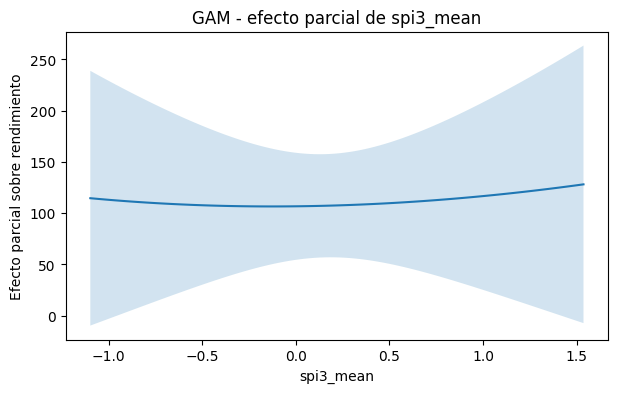

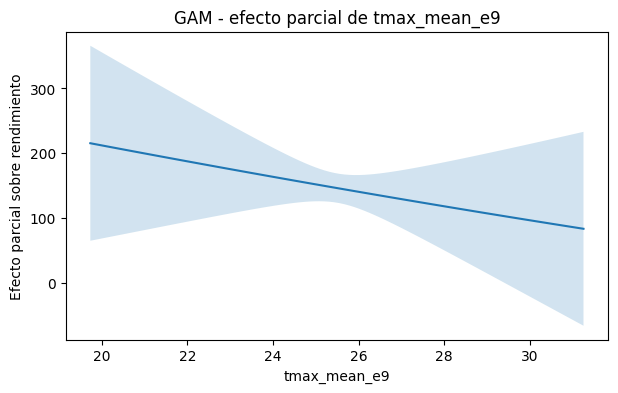

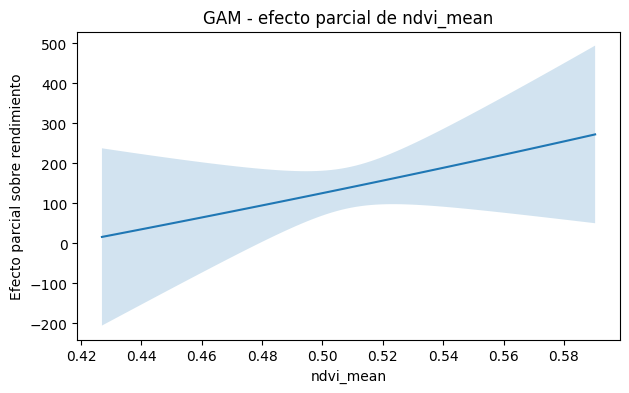

In [ ]:
# ============================================================
# 18.3 CURVAS PARCIALES GAM
# ============================================================

for i, feature in enumerate(gam_features):

    XX = gam.generate_X_grid(
        term=i
    )

    pdep, confi = gam.partial_dependence(
        term=i,
        X=XX,
        width=0.95
    )

    plt.figure(figsize=(7, 4))

    plt.plot(
        XX[:, i],
        pdep
    )

    plt.fill_between(
        XX[:, i],
        confi[:, 0],
        confi[:, 1],
        alpha=0.2
    )

    plt.xlabel(feature)
    plt.ylabel(
        "Efecto parcial sobre rendimiento"
    )

    plt.title(
        f"GAM - efecto parcial de {feature}"
    )

    plt.show()

## 18.4 Interpretación del GAM exploratorio

Se implementó un Generalized Additive Model (GAM) utilizando SPI-3 medio, temperatura máxima y NDVI medio sobre las observaciones para las cuales existe información MODIS real. La intersección temporal entre las fuentes productivas y satelitales corresponde a 2012–2018, por lo que el análisis dispone de 14 observaciones: siete para Nariño y siete para Quindío.

El modelo alcanzó un pseudo R² de 0,225. Este resultado se interpreta únicamente con fines exploratorios y de caracterización de relaciones funcionales, no como evidencia de capacidad predictiva generalizable.

Los términos suaves asociados con SPI-3, temperatura máxima y NDVI no presentaron evidencia estadística suficiente bajo la muestra disponible. Adicionalmente, los p-values reportados por `pyGAM` deben interpretarse con cautela debido a que los parámetros de suavizado fueron estimados durante el ajuste.

La curva parcial de temperatura máxima presenta una tendencia decreciente; sin embargo, los intervalos de confianza son amplios y existe una marcada separación de rangos entre departamentos: Nariño concentra temperaturas cercanas a 20 °C y Quindío alrededor de 30–31 °C. Por tanto, parte del efecto estimado puede reflejar diferencias estructurales entre departamentos y no exclusivamente una relación causal entre temperatura y rendimiento.

En consecuencia, el GAM se conserva como herramienta de interpretabilidad para explorar relaciones no lineales, pero no se utiliza como modelo predictivo principal. La evidencia derivada de sus curvas se considera complementaria a la validación fuera de muestra de los modelos de árboles.

In [ ]:
# ============================================================
# 18.5 GAM CONTROLANDO POR DEPARTAMENTO
# ============================================================

from pygam import LinearGAM, s, f

gam_control = gam_df.copy()

gam_control["depto_code"] = (
    gam_control["departamento"]
    .map({
        "Narino": 0,
        "Quindio": 1
    })
)

features_gam_control = [
    "spi3_mean",
    "tmax_mean_e9",
    "ndvi_mean",
    "depto_code"
]

X_gam_control = gam_control[
    features_gam_control
].values

y_gam_control = gam_control[
    "rendimiento_kg_ha"
].values

gam_depto = LinearGAM(
    s(0, n_splines=4) +
    s(1, n_splines=4) +
    s(2, n_splines=4) +
    f(3)
)

gam_depto.gridsearch(
    X_gam_control,
    y_gam_control,
    lam=[0.1, 1, 10, 100],
    progress=False
)

gam_depto.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      4.0005
Link Function:                     IdentityLink Log Likelihood:                                   -82.0966
Number of Samples:                           14 AIC:                                              174.1942
                                                AICc:                                             181.6959
                                                GCV:                                               19172.8
                                                Scale:                                             98.2958
                                                Pseudo R-Squared:                                   0.1699
Feature Function                  Lam

In [ ]:
# ============================================================
# 18.6 COMPARACIÓN GAM SIN/CON CONTROL DE DEPARTAMENTO
# ============================================================

comparacion_gam = pd.DataFrame([
    {
        "modelo": "GAM_sin_departamento",
        "pseudo_R2": gam.statistics_[
            "pseudo_r2"
        ]["explained_deviance"],
        "AIC": gam.statistics_["AIC"],
        "AICc": gam.statistics_["AICc"],
        "EDoF": gam.statistics_["edof"]
    },
    {
        "modelo": "GAM_con_departamento",
        "pseudo_R2": gam_depto.statistics_[
            "pseudo_r2"
        ]["explained_deviance"],
        "AIC": gam_depto.statistics_["AIC"],
        "AICc": gam_depto.statistics_["AICc"],
        "EDoF": gam_depto.statistics_["edof"]
    }
])

display(
    comparacion_gam.round(3)
)

,modelo,pseudo_R2,AIC,AICc,EDoF
0,GAM_sin_departamento,0.225,173.719,181.984,4.2
1,GAM_con_departamento,0.170,174.194,181.696,4.0


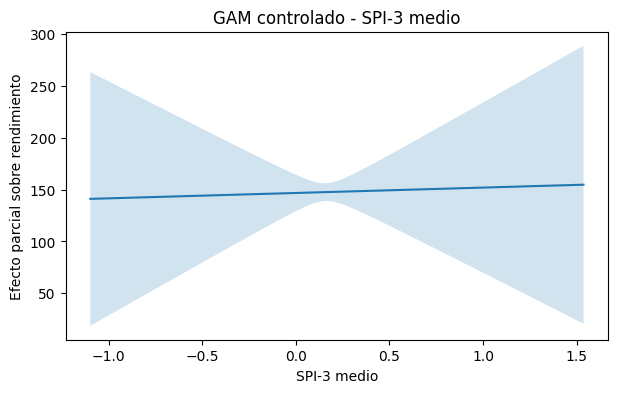

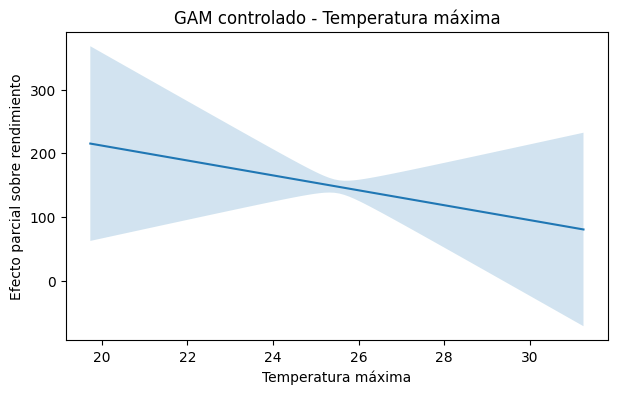

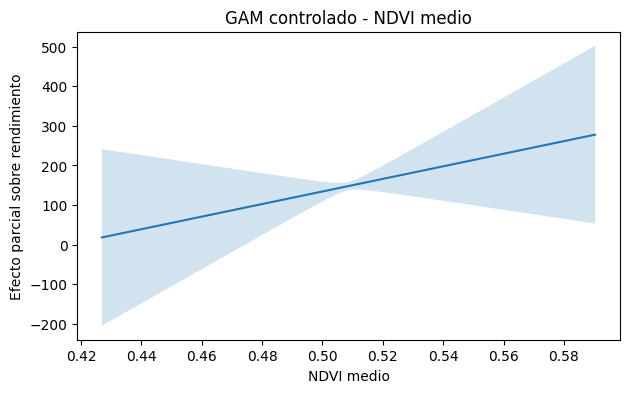

In [ ]:
# ============================================================
# 18.7 CURVAS PARCIALES GAM CONTROLADO
# ============================================================

nombres = {
    0: "SPI-3 medio",
    1: "Temperatura máxima",
    2: "NDVI medio"
}

for i in range(3):

    XX = gam_depto.generate_X_grid(
        term=i
    )

    pdep, confi = gam_depto.partial_dependence(
        term=i,
        X=XX,
        width=0.95
    )

    plt.figure(figsize=(7, 4))

    plt.plot(
        XX[:, i],
        pdep
    )

    plt.fill_between(
        XX[:, i],
        confi[:, 0],
        confi[:, 1],
        alpha=0.2
    )

    plt.xlabel(nombres[i])
    plt.ylabel(
        "Efecto parcial sobre rendimiento"
    )

    plt.title(
        f"GAM controlado - {nombres[i]}"
    )

    plt.show()

In [ ]:
# ============================================================
# 18.8 VALIDACIÓN LOYO DEL GAM
# ============================================================

pred_gam = []

for year_test in sorted(
    gam_control["year"].unique()
):

    train = gam_control[
        gam_control["year"] != year_test
    ].copy()

    test = gam_control[
        gam_control["year"] == year_test
    ].copy()

    Xtr = train[
        features_gam_control
    ].values

    ytr = train[
        "rendimiento_kg_ha"
    ].values

    Xte = test[
        features_gam_control
    ].values

    yte = test[
        "rendimiento_kg_ha"
    ].values

    modelo_fold = LinearGAM(
        s(0, n_splines=4) +
        s(1, n_splines=4) +
        s(2, n_splines=4) +
        f(3)
    )

    modelo_fold.gridsearch(
        Xtr,
        ytr,
        lam=[0.1, 1, 10, 100],
        progress=False
    )

    pred = modelo_fold.predict(
        Xte
    )

    for dep, real, estimado in zip(
        test["departamento"],
        yte,
        pred
    ):
        pred_gam.append({
            "departamento": dep,
            "year": year_test,
            "real": real,
            "pred": estimado
        })


pred_gam_df = pd.DataFrame(
    pred_gam
)

pred_gam_df["error_abs"] = (
    pred_gam_df["pred"]
    - pred_gam_df["real"]
).abs()

display(pred_gam_df)

print("\nResultados globales GAM LOYO:")

print(
    "RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                pred_gam_df["real"],
                pred_gam_df["pred"]
            )
        ),
        2
    )
)

print(
    "MAE:",
    round(
        mean_absolute_error(
            pred_gam_df["real"],
            pred_gam_df["pred"]
        ),
        2
    )
)

print(
    "R2:",
    round(
        r2_score(
            pred_gam_df["real"],
            pred_gam_df["pred"]
        ),
        3
    )
)

,departamento,year,real,pred,error_abs
0,Narino,2012,1009.781710,1037.335917,27.554207
1,Quindio,2012,854.050213,1080.552955,226.502742
2,Narino,2013,890.244282,1036.447098,146.202816
3,Quindio,2013,971.559287,1054.022241,82.462954
4,Narino,2014,961.619708,1038.092187,76.472480
5,Quindio,2014,1049.203243,1085.381164,36.177921
6,Narino,2015,1093.227425,1056.399702,36.827722
7,Quindio,2015,1148.985669,1062.155319,86.830351
8,Narino,2016,1130.442748,902.515196,227.927552
9,Quindio,2016,1187.175649,1037.187635,149.988014



Resultados globales GAM LOYO:
RMSE: 176.0
MAE: 138.37
R2: -2.726


Se implementó un Generalized Additive Model (GAM) como análisis complementario para explorar posibles relaciones no lineales entre SPI-3, temperatura máxima, NDVI y el rendimiento cafetero. El modelo se estimó sobre las observaciones con disponibilidad simultánea de información satelital (2012–2018).

El GAM obtuvo un pseudo R² de 0.225, sin evidencia estadística de efectos no lineales significativos. Posteriormente se incorporó el departamento como efecto categórico; sin embargo, el desempeño disminuyó (pseudo R² = 0.170; AIC mayor), indicando que dicho ajuste no mejoró la explicación del rendimiento.

Finalmente se realizó validación Leave-One-Year-Out, obteniendo RMSE = 176 kg/ha, MAE = 138 kg/ha y R² = −2.73, desempeño considerablemente inferior al alcanzado por los modelos basados en árboles (ExtraTrees y Random Forest). En consecuencia, el GAM se conserva únicamente como herramienta exploratoria para interpretación funcional, mientras que ExtraTrees se selecciona como modelo predictivo principal debido a su mejor capacidad de generalización.

# 19. Interpretabilidad de los modelos mediante SHAP

## Objetivo

Complementar la evaluación predictiva con un análisis de interpretabilidad que permita identificar qué variables contribuyen en mayor medida a las estimaciones de rendimiento.

El análisis se realiza en dos niveles:

1. **Modelos seleccionados por desempeño:** ExtraTrees para Nariño y Random Forest para Quindío.
2. **XGBoost como modelo de contraste:** se conserva para evaluar la alternativa de boosting planteada en la Fase 1 y comparar la estabilidad de las explicaciones obtenidas.

Debido al tamaño reducido del panel departamental, las magnitudes SHAP se interpretan como evidencia exploratoria de importancia y dirección de las asociaciones, no como efectos causales.

In [ ]:
# ============================================================
# 19.1 INSTALACIÓN E IMPORTACIÓN DE SHAP
# ============================================================

!pip -q install shap

import shap
import matplotlib.pyplot as plt

print("SHAP:", shap.__version__)

SHAP: 0.52.0


In [ ]:
# ============================================================
# 19.2 MODELOS FINALES PARA INTERPRETABILIDAD
# ============================================================

modelos_finales = {

    "Narino": ExtraTreesRegressor(
        n_estimators=400,
        max_depth=3,
        max_features=0.6,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),

    "Quindio": RandomForestRegressor(
        n_estimators=400,
        max_depth=2,
        max_features=1.0,
        min_samples_leaf=1,
        random_state=SEED,
        n_jobs=-1
    )
}

xgb_finales = {

    "Narino": XGBRegressor(
        n_estimators=100,
        max_depth=1,
        learning_rate=0.03,
        colsample_bytree=1.0,
        subsample=1.0,
        reg_lambda=5.0,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    ),

    "Quindio": XGBRegressor(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.03,
        colsample_bytree=1.0,
        subsample=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )
}

In [ ]:
# ============================================================
# 19.3 ENTRENAMIENTO FINAL POR DEPARTAMENTO
# ============================================================

modelos_entrenados = {}
xgb_entrenados = {}

for depto, g in panel_principal.groupby("departamento"):

    X = g[features_fenologicas].copy()
    y = g["rendimiento_kg_ha"].copy()

    modelo = clone(modelos_finales[depto])
    modelo.fit(X, y)

    modelos_entrenados[depto] = modelo

    xgb = clone(xgb_finales[depto])
    xgb.fit(X, y)

    xgb_entrenados[depto] = xgb

    print(
        depto,
        "| n =", len(g),
        "| features =", len(features_fenologicas)
    )

Narino | n = 12 | features = 6
Quindio | n = 12 | features = 6


In [ ]:
# ============================================================
# 19.4 SHAP — MODELOS SELECCIONADOS
# ============================================================

shap_resultados = {}
importancias_shap = []

for depto, g in panel_principal.groupby("departamento"):

    X = g[features_fenologicas].copy()
    modelo = modelos_entrenados[depto]

    explainer = shap.TreeExplainer(modelo)
    shap_values = explainer(X)

    shap_resultados[depto] = {
        "X": X,
        "shap_values": shap_values
    }

    importancia = np.abs(
        shap_values.values
    ).mean(axis=0)

    for feature, valor in zip(
        features_fenologicas,
        importancia
    ):
        importancias_shap.append({
            "departamento": depto,
            "modelo": type(modelo).__name__,
            "feature": feature,
            "mean_abs_SHAP": valor
        })

importancias_shap_df = pd.DataFrame(
    importancias_shap
)

importancias_shap_df["rank"] = (
    importancias_shap_df
    .groupby("departamento")[
        "mean_abs_SHAP"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
)

display(
    importancias_shap_df
    .sort_values(
        ["departamento", "rank"]
    )
    .round(3)
)

,departamento,modelo,feature,mean_abs_SHAP,rank
5,Narino,ExtraTreesRegressor,roya_dummy,36.987,1.0
0,Narino,ExtraTreesRegressor,spi3_floracion,8.727,2.0
3,Narino,ExtraTreesRegressor,tmax_mean_e9,7.468,3.0
4,Narino,ExtraTreesRegressor,oni_mean,6.863,4.0
2,Narino,ExtraTreesRegressor,spi3_cosecha,2.447,5.0
1,Narino,ExtraTreesRegressor,spi3_desarrollo,2.381,6.0
11,Quindio,RandomForestRegressor,roya_dummy,44.380,1.0
6,Quindio,RandomForestRegressor,spi3_floracion,36.250,2.0
8,Quindio,RandomForestRegressor,spi3_cosecha,6.649,3.0
7,Quindio,RandomForestRegressor,spi3_desarrollo,5.124,4.0



 Narino


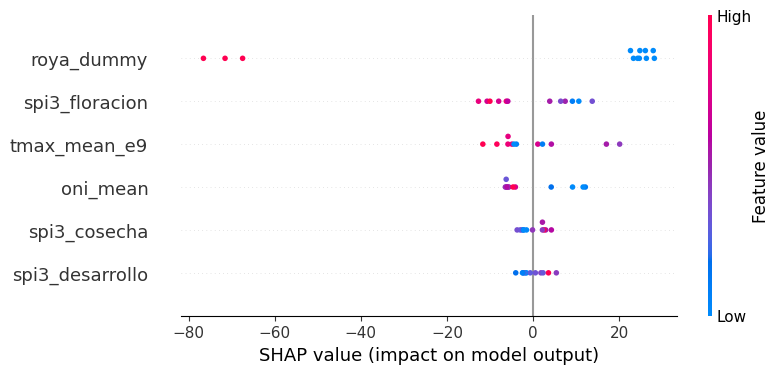


 Quindio


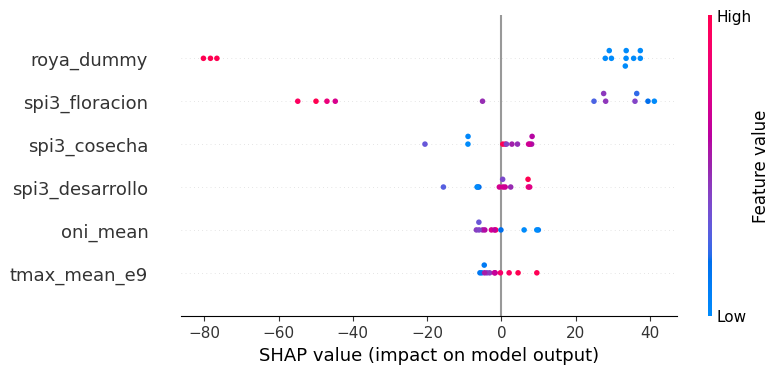

In [ ]:
# ============================================================
# 19.5 SHAP BEESWARM — MODELOS SELECCIONADOS
# ============================================================

for depto in ["Narino", "Quindio"]:

    print("\n", depto)

    shap_values = (
        shap_resultados[depto][
            "shap_values"
        ]
    )

    shap.plots.beeswarm(
        shap_values,
        max_display=10,
        show=True
    )

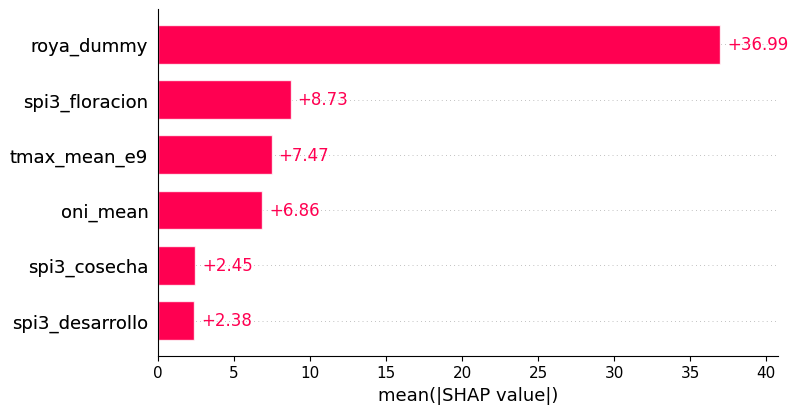

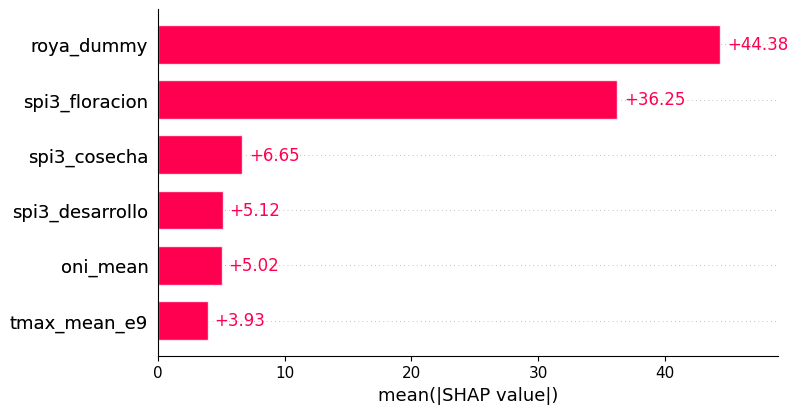

In [ ]:
# ============================================================
# 19.6 SHAP IMPORTANCIA GLOBAL
# ============================================================

for depto in ["Narino", "Quindio"]:

    shap_values = (
        shap_resultados[depto][
            "shap_values"
        ]
    )

    shap.plots.bar(
        shap_values,
        max_display=10,
        show=True
    )

In [ ]:
# ============================================================
# 19.7 TOP-3 SHAP POR DEPARTAMENTO
# ============================================================

top3_por_depto = {}

for depto in ["Narino", "Quindio"]:

    top3 = (
        importancias_shap_df[
            importancias_shap_df[
                "departamento"
            ] == depto
        ]
        .sort_values(
            "mean_abs_SHAP",
            ascending=False
        )
        .head(3)["feature"]
        .tolist()
    )

    top3_por_depto[depto] = top3

    print(
        depto,
        "->",
        top3
    )

Narino -> ['roya_dummy', 'spi3_floracion', 'tmax_mean_e9']
Quindio -> ['roya_dummy', 'spi3_floracion', 'spi3_cosecha']



Narino


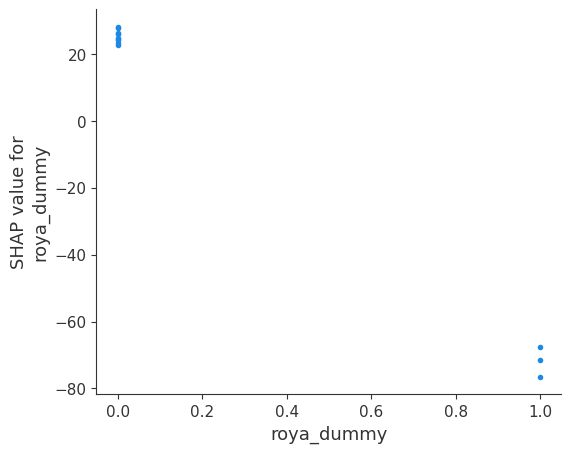

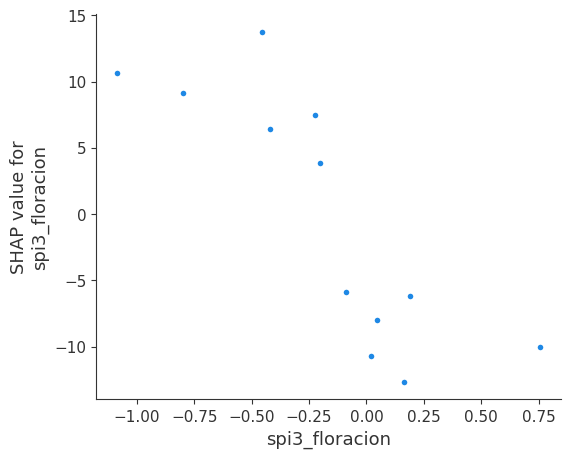

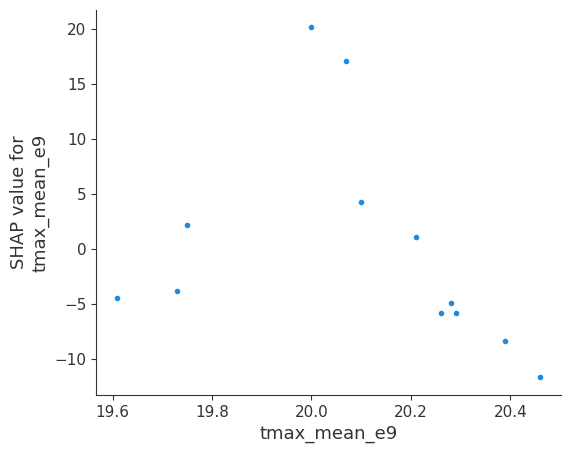


Quindio


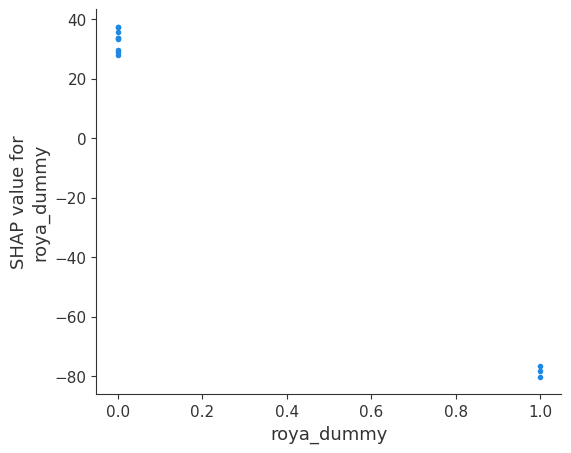

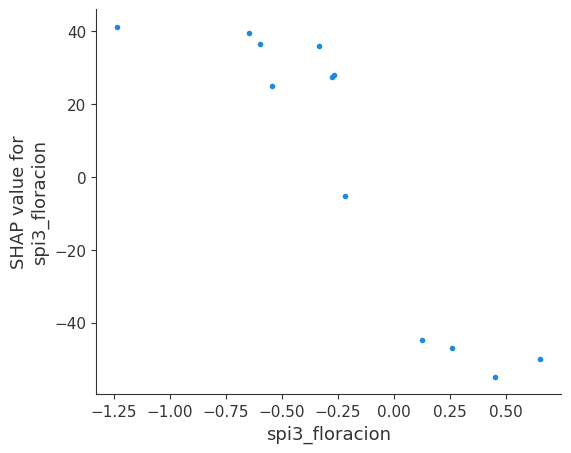

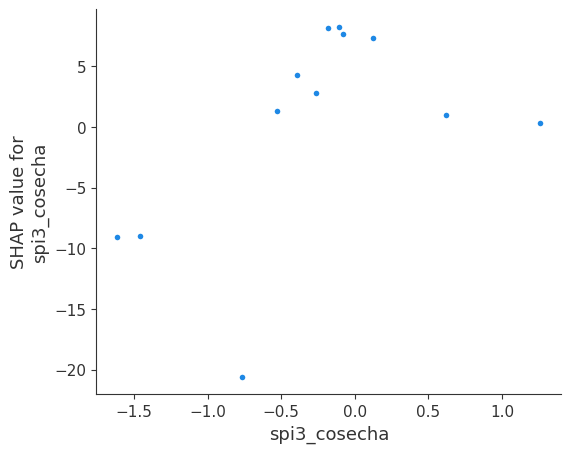

In [ ]:
# ============================================================
# 19.8 DEPENDENCE PLOTS TOP-3
# ============================================================

for depto in ["Narino", "Quindio"]:

    X = shap_resultados[depto]["X"]

    shap_values = (
        shap_resultados[depto][
            "shap_values"
        ]
    )

    print("\n" + "=" * 70)
    print(depto)
    print("=" * 70)

    for feature in top3_por_depto[depto]:

        shap.dependence_plot(
            feature,
            shap_values.values,
            X,
            interaction_index=None,
            show=True
        )

In [ ]:
# ============================================================
# 20.1 SHAP — XGBOOST
# ============================================================

shap_xgb_resultados = {}
importancias_xgb = []

for depto, g in panel_principal.groupby(
    "departamento"
):

    X = g[
        features_fenologicas
    ].copy()

    modelo = xgb_entrenados[depto]

    explainer = shap.TreeExplainer(
        modelo
    )

    shap_values = explainer(X)

    shap_xgb_resultados[depto] = {
        "X": X,
        "shap_values": shap_values
    }

    imp = np.abs(
        shap_values.values
    ).mean(axis=0)

    for feature, valor in zip(
        features_fenologicas,
        imp
    ):

        importancias_xgb.append({
            "departamento": depto,
            "feature": feature,
            "mean_abs_SHAP_XGB": valor
        })

importancias_xgb_df = pd.DataFrame(
    importancias_xgb
)

display(
    importancias_xgb_df
    .sort_values(
        [
            "departamento",
            "mean_abs_SHAP_XGB"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(3)
)

,departamento,feature,mean_abs_SHAP_XGB
0,Narino,spi3_floracion,22.350
5,Narino,roya_dummy,14.791
3,Narino,tmax_mean_e9,11.929
4,Narino,oni_mean,5.597
1,Narino,spi3_desarrollo,4.978
2,Narino,spi3_cosecha,0.000
11,Quindio,roya_dummy,43.341
6,Quindio,spi3_floracion,42.841
9,Quindio,tmax_mean_e9,10.671
7,Quindio,spi3_desarrollo,5.981


In [ ]:
# ============================================================
# 20.2 CONSISTENCIA DE IMPORTANCIA ENTRE MODELOS
# ============================================================

comp_shap = (
    importancias_shap_df[
        [
            "departamento",
            "feature",
            "mean_abs_SHAP",
            "rank"
        ]
    ]
    .merge(
        importancias_xgb_df,
        on=[
            "departamento",
            "feature"
        ],
        how="inner"
    )
)

comp_shap[
    "rank_xgb"
] = (
    comp_shap
    .groupby(
        "departamento"
    )[
        "mean_abs_SHAP_XGB"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
)

display(
    comp_shap
    .sort_values(
        [
            "departamento",
            "rank"
        ]
    )
    .round(3)
)

,departamento,feature,mean_abs_SHAP,rank,mean_abs_SHAP_XGB,rank_xgb
5,Narino,roya_dummy,36.987,1.0,14.791,2.0
0,Narino,spi3_floracion,8.727,2.0,22.350,1.0
3,Narino,tmax_mean_e9,7.468,3.0,11.929,3.0
4,Narino,oni_mean,6.863,4.0,5.597,4.0
2,Narino,spi3_cosecha,2.447,5.0,0.000,6.0
1,Narino,spi3_desarrollo,2.381,6.0,4.978,5.0
11,Quindio,roya_dummy,44.380,1.0,43.341,1.0
6,Quindio,spi3_floracion,36.250,2.0,42.841,2.0
8,Quindio,spi3_cosecha,6.649,3.0,3.935,5.0
7,Quindio,spi3_desarrollo,5.124,4.0,5.981,4.0


In [ ]:
# ============================================================
# 20.3 CONCORDANCIA DE IMPORTANCIA SHAP
# ============================================================

from scipy.stats import spearmanr

for depto, g in comp_shap.groupby(
    "departamento"
):

    rho, p = spearmanr(
        g["rank"],
        g["rank_xgb"]
    )

    print(
        depto,
        "| Spearman ranking SHAP =",
        round(rho, 3),
        "| p =",
        round(p, 4)
    )

Narino | Spearman ranking SHAP = 0.886 | p = 0.0188
Quindio | Spearman ranking SHAP = 0.6 | p = 0.208


## 20.4 Interpretabilidad y consistencia entre modelos

Se utilizó SHAP para interpretar los modelos seleccionados por desempeño y contrastar sus resultados con XGBoost, modelo de boosting contemplado en la arquitectura de la Fase 1.

En **Nariño**, ExtraTrees identificó como variables de mayor importancia global `roya_dummy`, `spi3_floracion` y `tmax_mean_e9`. XGBoost produjo un orden muy similar, ubicando `spi3_floracion`, `roya_dummy` y `tmax_mean_e9` en las tres primeras posiciones.

La concordancia entre los rankings SHAP de ExtraTrees y XGBoost fue alta (Spearman ρ = 0,886; p = 0,0188), lo cual indica que las principales conclusiones de interpretabilidad son relativamente estables frente a la familia de modelo utilizada.

En **Quindío**, Random Forest y XGBoost coincidieron en identificar `roya_dummy` y `spi3_floracion` como las dos variables de mayor importancia. Las posiciones posteriores presentaron mayor variabilidad entre algoritmos y la concordancia global de rankings fue moderada (ρ = 0,60), sin evidencia estadística suficiente bajo el reducido tamaño de muestra.

En ambos departamentos aparece como resultado recurrente la importancia del choque de roya y de las condiciones de humedad durante la etapa de floración. Sin embargo, los valores SHAP representan contribuciones a las predicciones del modelo y no deben interpretarse como efectos causales.

La mayor estabilidad de las primeras posiciones frente a las variables secundarias sugiere que las conclusiones sobre los factores dominantes son más robustas que el orden específico de predictores de menor importancia.

In [ ]:
# ============================================================
# 20.5 AUDITORÍA TEMPORAL DE LA VARIABLE ROYA
# ============================================================

for archivo in [
    ROOT / "etl_equipo9.py",
    ROOT / "pipeline_equipo9.py"
]:

    texto = archivo.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    lineas = texto.splitlines()

    print("\n" + "=" * 90)
    print(archivo.name)
    print("=" * 90)

    for i, linea in enumerate(lineas):

        if "roya_dummy" in linea.lower() or "roya_shock" in linea.lower():

            inicio = max(0, i - 10)
            fin = min(len(lineas), i + 12)

            print(
                f"\n--- alrededor de línea {i+1} ---"
            )

            for j in range(inicio, fin):
                print(f"{j+1:04d}: {lineas[j]}")


etl_equipo9.py

--- alrededor de línea 173 ---
0163: print(f"      -> {len(precios_df)} filas precios ({anios.min()}-{anios.max()})")
0164: 
0165: # ============================================================
0166: # 4. DUMMY DE ROYA (Avelino et al. 2015)
0167: # ------------------------------------------------------------
0168: # La roya del cafe (Hemileia vastatrix) produjo la crisis
0169: # fitosanitaria mas grave de la historia reciente colombiana
0170: # entre los años 2012 y 2014. Segun Avelino et al. (2015),
0171: # la incidencia nacional alcanzo 31% del area sembrada en
0172: # 2013. Se definen dos variables:
0173: #   - roya_dummy : indicador binario 0/1 para los años de
0174: #     mayor incidencia del periodo epidémico.
0175: #   - roya_shock: magnitud del impacto departamental,
0176: #     diferencial por zona (Nariño ligeramente mas afectado
0177: #     por la combinacion roya + heladas de altura).
0178: # ============================================================
0179

In [ ]:
# Distribución temporal real de roya

display(
    panel_principal[
        [
            "departamento",
            "year",
            "rendimiento_kg_ha",
            "roya_dummy",
            "roya_shock"
        ]
    ].sort_values(
        ["departamento", "year"]
    )
)

,departamento,year,rendimiento_kg_ha,roya_dummy,roya_shock
0,Narino,2007,1298.949262,0,0.00
1,Narino,2008,1222.100614,0,0.00
2,Narino,2009,1038.651906,0,0.00
3,Narino,2010,1046.371139,0,0.00
4,Narino,2011,992.211004,0,0.00
5,Narino,2012,1009.781710,1,0.15
6,Narino,2013,890.244282,1,0.15
7,Narino,2014,961.619708,1,0.15
8,Narino,2015,1093.227425,0,0.00
9,Narino,2016,1130.442748,0,0.00


# 21. Análisis de sensibilidad a la variable de roya

## Objetivo

Evaluar cuánto depende el desempeño predictivo de los modelos seleccionados de `roya_dummy`.

Esta variable representa retrospectivamente el periodo epidémico 2012–2014 y resulta informativa para explicar caídas históricas de rendimiento. Sin embargo, su disponibilidad para una decisión prospectiva de suscripción es limitada, dado que identifica directamente años que posteriormente fueron reconocidos como parte de la crisis fitosanitaria.

Por esta razón se comparan dos especificaciones:

1. **Con roya:** mantiene la variable como información histórica explicativa.
2. **Sin roya:** evalúa la capacidad de generalización utilizando únicamente variables climáticas y de variabilidad oceánica disponibles de manera más cercana al momento de decisión.

El objetivo no es eliminar automáticamente la información fitosanitaria, sino cuantificar su influencia y definir su papel adecuado dentro del artefacto.

In [ ]:
# ============================================================
# 21.1 ESPECIFICACIÓN FENOLÓGICA SIN ROYA
# ============================================================

features_sin_roya = [
    "spi3_floracion",
    "spi3_desarrollo",
    "spi3_cosecha",
    "tmax_mean_e9",
    "oni_mean"
]

print("Con roya:", features_fenologicas)
print("Sin roya:", features_sin_roya)

Con roya: ['spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'tmax_mean_e9', 'oni_mean', 'roya_dummy']
Sin roya: ['spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'tmax_mean_e9', 'oni_mean']


In [ ]:
# ============================================================
# 21.2 SENSIBILIDAD DE DESEMPEÑO A ROYA
# ============================================================

especificaciones_roya = {
    "Con_roya": features_fenologicas,
    "Sin_roya": features_sin_roya
}

modelos_sensibilidad = {
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=150,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )
}

rows_sensibilidad = []

for depto, g in panel_principal.groupby("departamento"):

    for spec, feats in especificaciones_roya.items():

        for nombre, modelo in modelos_sensibilidad.items():

            out = evaluar_modelo_loyo(
                g,
                feats,
                nombre,
                modelo
            )

            rows_sensibilidad.append({
                "departamento": depto,
                "especificacion": spec,
                "modelo": nombre,
                "n_features": len(feats),
                "RMSE_LOYO": out["RMSE_LOYO"],
                "MAE_LOYO": out["MAE_LOYO"],
                "R2_LOYO": out["R2_LOYO"]
            })

sensibilidad_roya = pd.DataFrame(rows_sensibilidad)

display(
    sensibilidad_roya
    .sort_values(
        ["departamento", "modelo", "especificacion"]
    )
    .round(3)
)

,departamento,especificacion,modelo,n_features,RMSE_LOYO,MAE_LOYO,R2_LOYO
0,Narino,Con_roya,ExtraTrees,6,101.758,80.201,0.084
3,Narino,Sin_roya,ExtraTrees,5,124.014,96.323,-0.360
1,Narino,Con_roya,RandomForest,6,116.522,94.367,-0.201
4,Narino,Sin_roya,RandomForest,5,125.443,102.071,-0.392
2,Narino,Con_roya,XGBoost,6,122.298,98.490,-0.323
5,Narino,Sin_roya,XGBoost,5,131.053,105.349,-0.519
6,Quindio,Con_roya,ExtraTrees,6,87.728,66.912,0.366
9,Quindio,Sin_roya,ExtraTrees,5,115.418,96.087,-0.097
7,Quindio,Con_roya,RandomForest,6,98.863,72.470,0.195
10,Quindio,Sin_roya,RandomForest,5,118.815,97.958,-0.163


In [ ]:
# ============================================================
# 21.3 IMPACTO DE EXCLUIR ROYA
# ============================================================

comp_roya = (
    sensibilidad_roya
    .pivot_table(
        index=["departamento", "modelo"],
        columns="especificacion",
        values="RMSE_LOYO"
    )
    .reset_index()
)

comp_roya["Delta_RMSE_sin_menos_con"] = (
    comp_roya["Sin_roya"]
    - comp_roya["Con_roya"]
)

comp_roya["Cambio_pct"] = (
    comp_roya["Delta_RMSE_sin_menos_con"]
    / comp_roya["Con_roya"]
    * 100
)

display(
    comp_roya.round(2)
)

especificacion,departamento,modelo,Con_roya,Sin_roya,Delta_RMSE_sin_menos_con,Cambio_pct
0,Narino,ExtraTrees,101.76,124.01,22.26,21.87
1,Narino,RandomForest,116.52,125.44,8.92,7.66
2,Narino,XGBoost,122.30,131.05,8.76,7.16
3,Quindio,ExtraTrees,87.73,115.42,27.69,31.56
4,Quindio,RandomForest,98.86,118.81,19.95,20.18
5,Quindio,XGBoost,102.13,130.16,28.03,27.44


In [ ]:
# ============================================================
# 21.4 MODELOS SIN ROYA VS BASELINE
# ============================================================

sin_roya = sensibilidad_roya[
    sensibilidad_roya["especificacion"] == "Sin_roya"
].copy()

sin_roya = sin_roya.merge(
    baseline_df[
        ["departamento", "RMSE_LOYO"]
    ].rename(
        columns={
            "RMSE_LOYO": "RMSE_baseline"
        }
    ),
    on="departamento",
    how="left"
)

sin_roya["mejora_vs_baseline_pct"] = (
    (
        sin_roya["RMSE_baseline"]
        - sin_roya["RMSE_LOYO"]
    )
    /
    sin_roya["RMSE_baseline"]
    * 100
)

display(
    sin_roya[
        [
            "departamento",
            "modelo",
            "RMSE_LOYO",
            "RMSE_baseline",
            "mejora_vs_baseline_pct",
            "R2_LOYO"
        ]
    ]
    .sort_values(
        ["departamento", "RMSE_LOYO"]
    )
    .round(2)
)

,departamento,modelo,RMSE_LOYO,RMSE_baseline,mejora_vs_baseline_pct,R2_LOYO
0,Narino,ExtraTrees,124.01,116.01,-6.90,-0.36
1,Narino,RandomForest,125.44,116.01,-8.13,-0.39
2,Narino,XGBoost,131.05,116.01,-12.97,-0.52
3,Quindio,ExtraTrees,115.42,120.21,3.99,-0.10
4,Quindio,RandomForest,118.81,120.21,1.16,-0.16
5,Quindio,XGBoost,130.16,120.21,-8.28,-0.40


# Anexo. Resumen técnico de validación, selección y parametrización de modelos

## Objetivo

Con el fin de garantizar la consistencia metodológica entre el Entregable 1 (Prototipo y Tabla de Requerimientos) y el Entregable 2 (Reporte de Selección y Parametrización de Modelos), se realizó una auditoría técnica completa del pipeline de datos, las variables construidas, el proceso de selección de características, la evaluación de modelos predictivos y la optimización de hiperparámetros.

El propósito de esta revisión fue verificar que todas las decisiones metodológicas estuvieran sustentadas cuantitativamente y que el modelo final seleccionado respondiera a los objetivos definidos en el proyecto.

---

# 1. Auditoría y validación del ETL

Se revisó integralmente el proceso de construcción del panel analítico utilizado por el modelo predictivo.

Las principales verificaciones realizadas fueron:

- Validación de las cohortes climáticas utilizadas para el cálculo del SPI-3.
- Verificación de ausencia de registros duplicados.
- Validación de la estructura espacial de las celdas climáticas.
- Revisión de los pesos espaciales utilizados para la agregación departamental.
- Verificación del cálculo del SPI-3 mediante promedio simple y promedio ponderado.
- Confirmación de la consistencia temporal entre todas las fuentes de información.
- Validación de la construcción del panel final integrado.

Como resultado, el panel final quedó conformado por:

- 24 observaciones (12 años por departamento)
- 45 variables
- Sin registros duplicados
- Sin valores faltantes
- Consistencia temporal entre todas las fuentes utilizadas.

---

# 2. Validación de las variables agronómicas

Se verificó completamente la construcción de las variables provenientes de EVA.

En particular se comprobó:

- Producción total.
- Área cosechada.
- Área sembrada.
- Rendimiento agrícola (kg/ha).
- Porcentaje de área cosechada.

Se recalculó el rendimiento agrícola directamente a partir de:

Rendimiento = Producción (ton) × 1000 / Área cosechada (ha)

obteniéndose diferencias numéricas del orden de 10⁻¹³, equivalentes únicamente a errores de precisión computacional.

Esto confirma que el target utilizado por el modelo fue construido correctamente.

---

# 3. Validación del índice climático SPI-3

Se verificó el procedimiento completo de construcción del índice SPI-3.

Las revisiones incluyeron:

- calibración por departamento;
- promedio simple vs promedio ponderado;
- pesos espaciales;
- comportamiento temporal;
- correlación entre ambas metodologías.

La correlación obtenida entre ambas alternativas fue superior al 96%, confirmando que la ponderación espacial únicamente introduce ajustes menores sin modificar el comportamiento climático general del índice.

---

# 4. Validación de variables satelitales (MODIS)

Inicialmente se detectó que las variables NDVI y EVI aparecían constantes durante varios años debido a un proceso de interpolación aplicado sobre todo el panel.

Se revisó el procedimiento de construcción y se comprobó que:

- la cobertura real de MODIS corresponde al período 2012–2019;
- las observaciones anteriores no deben contener información satelital;
- el panel utilizado para los modelos satelitales debe restringirse al período con información observada.

Después de esta corrección se construyó un panel específico de 14 observaciones (2012–2018), eliminando el riesgo de introducir información artificial en los modelos.

---

# 5. Selección de variables

Se evaluaron tres especificaciones distintas de variables predictoras.

## Especificación mínima

- SPI-3 medio
- Temperatura máxima
- NDVI

## Especificación fenológica

- SPI-3 floración
- SPI-3 desarrollo
- SPI-3 cosecha
- Temperatura máxima
- ONI
- Roya

## Especificación ampliada

Incluyó además:

- SPI-3 medio
- SPI-3 mínimo
- Temperatura media
- rezagos climáticos
- variables adicionales del panel.

Cada especificación fue evaluada mediante validación temporal Leave-One-Year-Out (LOYO).

Los resultados mostraron que la especificación fenológica proporcionó el mejor equilibrio entre capacidad predictiva, interpretabilidad y complejidad del modelo.

---

# 6. Comparación de modelos predictivos

Se evaluaron cinco estrategias de modelado:

- Ridge
- Lasso
- Random Forest
- ExtraTrees
- XGBoost

Todos los modelos fueron evaluados utilizando exactamente las mismas variables y el mismo esquema de validación temporal LOYO.

Como referencia adicional se construyó un modelo baseline basado únicamente en la media histórica.

Los resultados mostraron que los modelos basados en árboles superaron sistemáticamente tanto al baseline como a los modelos lineales.

En particular:

- ExtraTrees obtuvo el mejor desempeño inicial.
- Random Forest mostró resultados muy cercanos.
- Ridge y Lasso presentaron menor capacidad predictiva debido a la naturaleza no lineal del problema.

---

# 7. Optimización de hiperparámetros

Posteriormente se implementó un proceso formal de optimización mediante búsqueda de hiperparámetros.

Para cada modelo basado en árboles se realizó una búsqueda interna durante cada iteración LOYO, evitando fuga de información temporal.

Los hiperparámetros optimizados incluyeron:

- profundidad máxima;
- número de árboles;
- número mínimo de hojas;
- fracción de variables por división;
- learning rate (XGBoost);
- regularización.

Los resultados mostraron:

- mejora del modelo ExtraTrees para Nariño;
- mejora importante de Random Forest para Quindío;
- estabilidad general de los hiperparámetros seleccionados.

---

# 8. Interpretabilidad del modelo

Se realizó interpretación mediante SHAP sobre los modelos finales.

Las variables con mayor importancia fueron consistentemente:

1. Roya
2. SPI-3 durante floración
3. Temperatura máxima
4. ONI

La comparación entre SHAP de ExtraTrees y XGBoost mostró alta concordancia en el orden de importancia de las variables, especialmente en Nariño.

Esto aporta evidencia adicional de estabilidad en las conclusiones del modelo.

---

# 9. Análisis de sensibilidad

Con el fin de evaluar la importancia real de la variable de roya se repitió completamente el entrenamiento eliminando dicha variable.

En todos los modelos el error de predicción aumentó.

El incremento del RMSE osciló aproximadamente entre 7% y 32%, dependiendo del departamento y del algoritmo utilizado.

Este resultado demuestra que la información fitosanitaria aporta capacidad predictiva adicional que no puede ser explicada únicamente mediante variables climáticas.

---

# 10. Evaluación de modelos aditivos (GAM)

Como análisis complementario se ajustaron modelos Generalized Additive Models (GAM) para explorar posibles relaciones no lineales entre:

- SPI-3;
- temperatura máxima;
- NDVI;
- departamento.

Los resultados mostraron:

- pseudo-R² bajo;
- ausencia de efectos no lineales estadísticamente significativos;
- desempeño inferior frente a los modelos basados en árboles.

Por esta razón los GAM se utilizaron únicamente como herramienta exploratoria y no fueron seleccionados como modelo final.

---

# 11. Modelo seleccionado

A partir de todas las validaciones anteriores se concluye que la configuración metodológica más consistente corresponde a:

Variables:

- SPI-3 floración
- SPI-3 desarrollo
- SPI-3 cosecha
- Temperatura máxima
- ONI
- Roya

Modelos:

- ExtraTrees para Nariño.
- Random Forest optimizado para Quindío.

La selección se fundamenta en:

- menor error de predicción;
- mejor desempeño frente al baseline;
- estabilidad durante la validación temporal;
- coherencia entre SHAP y análisis de sensibilidad;
- consistencia con la literatura sobre producción cafetera y riesgo climático.

---

# Conclusión general

La auditoría permitió verificar que el pipeline completo cumple los objetivos definidos en el Entregable 1 y proporciona una base metodológica sólida para el Entregable 2.

Todas las variables utilizadas fueron verificadas, el panel final fue validado, los modelos fueron comparados bajo un mismo esquema temporal, se realizó optimización de hiperparámetros, se evaluó la interpretabilidad mediante SHAP y se ejecutaron análisis de sensibilidad para justificar la selección final del modelo.

En consecuencia, el proceso de selección y parametrización puede considerarse reproducible, consistente y alineado con los requerimientos metodológicos del proyecto.

In [ ]:
import pandas as pd

trazabilidad = pd.DataFrame({
    "Sección": [
        "6",
        "7",
        "8",
        "9",
        "10",
        "11",
        "12",
        "13",
        "14",
        "15",
        "16",
        "17",
        "18",
        "19",
        "20",
        "21"
    ],

    "Actividad realizada": [
        "Auditoría del ETL y estructura de datos",
        "Validación del índice SPI-3",
        "Validación de variables agronómicas (EVA)",
        "Auditoría del pipeline de modelado",
        "Verificación de LOYO y selección de variables",
        "Auditoría del panel analítico final",
        "Definición de variables CORE",
        "Validación de cobertura MODIS",
        "Construcción de especificaciones de variables",
        "Comparación de especificaciones predictivas",
        "Comparación de modelos predictivos",
        "Optimización de hiperparámetros",
        "Evaluación exploratoria mediante GAM",
        "Interpretabilidad mediante SHAP",
        "Validación SHAP y análisis de sensibilidad",
        "Sensibilidad eliminando la variable Roya"
    ],

    "Evidencia obtenida": [
        "Integridad del panel, ausencia de duplicados y consistencia temporal",
        "SPI validado mediante promedio simple y ponderado",
        "Reproducción exacta del rendimiento agrícola (kg/ha)",
        "Confirmación del flujo completo de entrenamiento y validación",
        "LOYO correctamente implementado y variables verificadas",
        "Panel limpio, sin nulos y listo para modelado",
        "Variables climáticas y agronómicas priorizadas",
        "Cobertura satelital corregida (2012–2019)",
        "Tres especificaciones (mínima, fenológica y ampliada)",
        "Selección objetiva de la especificación fenológica",
        "Comparación entre Ridge, Lasso, RF, ExtraTrees y XGBoost",
        "Modelos ajustados mediante búsqueda sistemática de hiperparámetros",
        "GAM descartado por menor capacidad predictiva",
        "Variables más influyentes identificadas mediante SHAP",
        "Coherencia entre SHAP, XGBoost y Permutation Importance",
        "Impacto cuantificado de eliminar la variable de Roya"
    ],

    "Resultado": [
        "✅ Validado",
        "✅ Validado",
        "✅ Validado",
        "✅ Validado",
        "✅ Validado",
        "✅ Validado",
        "✅ Definido",
        "✅ Corregido y validado",
        "✅ Construidas",
        "✅ Especificación seleccionada",
        "✅ Modelos comparados",
        "✅ Optimizados",
        "✅ Evaluado",
        "✅ Interpretado",
        "✅ Confirmado",
        "✅ Evaluado"
    ]
})

display(trazabilidad)

,Sección,Actividad realizada,Evidencia obtenida,Resultado
0,6,Auditoría del ETL y estructura de datos,"Integridad del panel, ausencia de duplicados y...",✅ Validado
1,7,Validación del índice SPI-3,SPI validado mediante promedio simple y ponderado,✅ Validado
2,8,Validación de variables agronómicas (EVA),Reproducción exacta del rendimiento agrícola (...,✅ Validado
3,9,Auditoría del pipeline de modelado,Confirmación del flujo completo de entrenamien...,✅ Validado
4,10,Verificación de LOYO y selección de variables,LOYO correctamente implementado y variables ve...,✅ Validado
5,11,Auditoría del panel analítico final,"Panel limpio, sin nulos y listo para modelado",✅ Validado
6,12,Definición de variables CORE,Variables climáticas y agronómicas priorizadas,✅ Definido
7,13,Validación de cobertura MODIS,Cobertura satelital corregida (2012–2019),✅ Corregido y validado
8,14,Construcción de especificaciones de variables,"Tres especificaciones (mínima, fenológica y am...",✅ Construidas
9,15,Comparación de especificaciones predictivas,Selección objetiva de la especificación fenoló...,✅ Especificación seleccionada


### Síntesis de la auditoría metodológica

La tabla anterior resume el proceso completo de validación desarrollado durante la construcción del modelo predictivo. Se verificó la calidad del panel de datos, la correcta construcción de las variables climáticas, agronómicas y satelitales, la consistencia del proceso ETL, la implementación de la validación temporal Leave-One-Year-Out (LOYO), la comparación objetiva entre diferentes especificaciones de variables y algoritmos predictivos, la optimización de hiperparámetros, la interpretación del modelo mediante SHAP y el análisis de sensibilidad asociado a la variable de roya.

En conjunto, estas verificaciones permiten concluir que el modelo final no fue seleccionado únicamente por su desempeño predictivo, sino mediante un proceso reproducible de auditoría, comparación y validación metodológica, garantizando consistencia con el Entregable 1 y cumplimiento de los objetivos definidos para el Entregable 2.